# Domain taxonomy analysis — prominence, reproducibility & citation accuracy across query topics and source types

This notebook extends the **RQ1–RQ3** scale-up analyses by adding the *domain* dimension that the
core RQ notebooks leave on the table. Two distinct taxonomies are in play and must not be confused:

| Taxonomy | Field | What it labels | Categories | Source file |
|---|---|---|---|---|
| **Query topic domain** | `query_domain` | what the *question* is about (health, politics, finance …) | 31 | `queries/reclass_queries.parquet` |
| **Source domain type** | `domain_type` | what *kind of site* is cited (blog, journal, government, university …) | 53 | `enrichment/citations_scaleup_enriched.parquet` |

All metrics follow the canonical forms in the Visual Style Guide §11 — **PAWC_norm** (normalised source
prominence), **AIS** (Attributable-to-Identified-Sources rate), **CV** (coefficient of variation) — and use
the **cleaned** values throughout. Style, palette, data and validators live in the first code cell; every
question below is a titled markdown header, one compact figure cell, and a plain-English **Key analysis**
written for an SEO/GEO manager.

**Question map** (D1–D14). *This notebook covers all 14 questions: RQ1 (D1–D4), RQ2 (D5–D8), RQ3 (D9–D12) and
the cross-cutting questions (D13–D14).*

- **RQ1 — Source prominence:** D1 prominence by query topic · D2 leader stability across topics · D3 source-type citation position · D4 source-type mix behind each engine's prominence
- **RQ2 — Reproducibility:** D5 CV by query topic · D6 engine agreement within topics · D7 source-type consistency vs CV · D8 Perplexity instability vs source mix
- **RQ3 — Citation accuracy:** D9 entailment by source type · D10 Gemini anomaly vs source mix · D11 borderline citations by source type · D12 AIS by query topic
- **Cross-cutting:** D13 topic↔source alignment vs AIS · D14 source-portfolio diversity vs prominence & accuracy

In [1]:
# === Shared preamble: style (Visual_Style_Guide §13 + §5), data, derived joins, validators ===
import os, logging, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from itertools import combinations
warnings.filterwarnings("ignore"); logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ---- §13 matplotlib global configuration block (verbatim) ----
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.edgecolor"] = "#374151"
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["axes.labelpad"] = 10
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.labelweight"] = "medium"
mpl.rcParams["axes.grid"] = True
mpl.rcParams["axes.grid.axis"] = "y"
mpl.rcParams["grid.color"] = "#E5E7EB"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["axes.axisbelow"] = True
mpl.rcParams["xtick.direction"] = "out"; mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["xtick.major.size"] = 4; mpl.rcParams["ytick.major.size"] = 4
mpl.rcParams["xtick.labelsize"] = 11; mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.frameon"] = False; mpl.rcParams["legend.fontsize"] = 11
mpl.rcParams["figure.figsize"] = (7, 4.5)
mpl.rcParams["figure.dpi"] = 300; mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"; mpl.rcParams["savefig.pad_inches"] = 0.15

ENGINE_COLOURS = {"chatgpt":"#2CA058","claude":"#D97706","gemini":"#2563EB","kimi":"#7C3AED","perplexity":"#0891B2"}
ENGINE_ORDER   = ["chatgpt","claude","gemini","kimi","perplexity"]
ENGINE_LABELS  = {"chatgpt":"ChatGPT","claude":"Claude","gemini":"Gemini","kimi":"Kimi","perplexity":"Perplexity"}
ENGINE_MARKERS = {"chatgpt":"o","claude":"s","gemini":"^","kimi":"D","perplexity":"X"}
COLOUR_PRIMARY="#1F4E79"; COLOUR_NEUTRAL="#6B7280"; COLOUR_REFERENCE="#DC2626"; COLOUR_GRID="#E5E7EB"
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list("teal_sequential", ["#EAF0F7","#5B8AC4","#1F4E79"])
CMAP_SEQUENTIAL.set_bad("#D1D5DB")
CMAP_DIVERGENT = LinearSegmentedColormap.from_list("teal_divergent", ["#B45309","#F3F4F6","#1F4E79"])

# ---- §5 apply_style ----
def apply_style(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#374151"); ax.spines["bottom"].set_color("#374151")
    ax.spines["left"].set_linewidth(0.8); ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--"); ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4, labelsize=11)

# ---- §7/§8 heatmap helper (CMAP_SEQUENTIAL, NaN->grey "—", white text on dark cells) ----
def draw_heatmap(ax, M, row_labels, col_labels, fmt="{:.2f}", xrot=40, cbar_label="", fmt_overrides=None):
    A = np.array(M, dtype=float)
    vmin, vmax = np.nanmin(A), np.nanmax(A); rng = (vmax - vmin) or 1.0
    im = ax.imshow(A, cmap=CMAP_SEQUENTIAL, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=xrot, ha=("right" if xrot else "center"))
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            v = A[i, j]
            if np.isnan(v):
                ax.text(j, i, "—", ha="center", va="center", color="#1F2937", fontsize=9)
            else:
                cell_fmt = (fmt_overrides or {}).get((i, j), fmt)
                ax.text(j, i, cell_fmt.format(v), ha="center", va="center",
                        color=("white" if (v-vmin)/rng > 0.5 else "#1F2937"), fontsize=9)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks(np.arange(-.5, len(col_labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2, linestyle="-"); ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label(cbar_label, fontsize=10)
    cb.outline.set_visible(False)
    return im

# ---- data load ----
GOLD="../../data/scaleup/gold"; ENR="../../data/scaleup/enrichment"; QDIR="../../data/scaleup/queries"
FIGDIR="../../figures/scaleup/domain"; os.makedirs(FIGDIR, exist_ok=True)
ca  = pd.read_parquet(f"{GOLD}/cell_aggregates_scaleup.parquet")                 # per-cell, 1,249
f1  = pd.read_parquet(f"{GOLD}/flat_table1_responses.parquet")                  # per-run, 9,992
sv  = pd.read_parquet("../../data/scaleup/silver/nli_scaleup_cleaned.parquet")  # per-run; pawc_by_source_position
cit = pd.read_parquet(f"{ENR}/citations_scaleup_enriched.parquet")              # per-citation, 58,851; domain_type
qf  = pd.read_parquet(f"{QDIR}/reclass_queries.parquet").rename(columns={"domain":"query_domain"})

def savefig(fig, name):
    for ext in ("png","pdf"): fig.savefig(f"{FIGDIR}/{name}.{ext}")
    print("saved", name)
def by_engine(s): return s.reindex(ENGINE_ORDER)

# ---- derived: query-topic-domain table (cell level, unconditional PAWC_norm NaN->0) ----
QDOM = qf[["query_id","query_domain"]]
NQD  = QDOM.query_domain.value_counts()                                # queries per topic domain
cad  = ca.assign(p=ca.pawc_norm_mean.fillna(0)).merge(QDOM, on="query_id")   # p = unconditional PAWC_norm
WELL_POWERED = NQD[NQD >= 8].index.tolist()                            # 14 topic domains with n>=8 queries

# ---- derived: PAWC-mass decomposition by source domain_type (faithful to pawc_norm) ----
# pawc_by_source_position maps each cited source position -> its raw PAWC contribution. Distribute every
# response's pawc_norm across its positions in proportion to those contributions (denominator = the dict's
# own sum, so each response's parts sum back to its pawc_norm exactly), then label each position with the
# domain_type of the citation sitting at that position.
_rows, _ref = [], []
for r in sv.itertuples(index=False):
    d = r.pawc_by_source_position
    if not isinstance(d, dict) or r.pawc_norm is None: continue
    vals = {int(p): float(v) for p, v in d.items() if v is not None}; s = sum(vals.values())
    if s <= 0: continue
    _ref.append((r.engine, float(r.pawc_norm)))
    for pos, v in vals.items(): _rows.append((r.engine, r.query_id, r.run_index, pos, r.pawc_norm * v / s))
PAWC_POS = pd.DataFrame(_rows, columns=["engine","query_id","run_index","position","contrib"])
_n_before = len(PAWC_POS)
PAWC_POS = PAWC_POS.merge(cit[["engine","query_id","run_index","position","domain_type"]],
                          on=["engine","query_id","run_index","position"], how="left")
PAWC_REF = pd.DataFrame(_ref, columns=["engine","pawc_norm"]).groupby("engine").pawc_norm.sum()

# ---- headline (RQ1) unconditional PAWC_norm per engine, NaN->0 ----
PAWC_UNCOND = by_engine(f1.assign(p=f1.pawc_norm.fillna(0)).groupby("engine").p.mean())

# ---- derived (RQ2): per-cell source-type consistency across runs (mean pairwise Jaccard of domain_type sets) ----
# For each cell, take the SET of domain_types cited in each run, then average the Jaccard overlap over all run
# pairs. 1 = the engine cites the same kinds of sources every run; low = the source-type mix churns run to run.
_runsets = (cit.dropna(subset=["domain_type"]).groupby(["engine","query_id","run_index"]).domain_type
            .apply(lambda s: frozenset(s)).reset_index())
def _cell_consistency(g):
    sets = [s for s in g.domain_type if len(s) > 0]
    if len(sets) < 2: return np.nan
    js = [len(a & b)/len(a | b) for a, b in combinations(sets, 2) if len(a | b) > 0]
    return float(np.mean(js)) if js else np.nan
TYP_CONS = (_runsets.groupby(["engine","query_id"]).apply(_cell_consistency)
            .rename("typ_consistency").reset_index())
# RQ2 cell table: CV metrics + topic + temporality + source-type consistency
CV = (ca.merge(qf[["query_id","query_domain","temporality"]], on="query_id")
        .merge(TYP_CONS, on=["engine","query_id"], how="left"))

# ---- data + derived (RQ3): per-(sentence, source) NLI entailment scores, mapped to source domain_type ----
f4 = pd.read_parquet(f"{GOLD}/flat_table4_entailment_scores.parquet")     # 1,181,792 rows; entail_score in [0,1]
F4 = (f4.merge(f1[["response_id","engine","query_id","run_index"]], on="response_id")
        .merge(cit[["engine","query_id","run_index","position","domain_type"]]
               .rename(columns={"position":"citation_position"}),
               on=["engine","query_id","run_index","citation_position"], how="left"))
# RQ3 entailment bands (verbatim cutoffs from rq3_citation_accuracy.ipynb Q13)
F4["band"] = np.where(F4.entail_score < 0.30, "contra", np.where(F4.entail_score < 0.50, "border", "entail"))
# per source domain_type: citation-pair volume, mean entailment, and band shares (%)
ENTAIL_BY_TYPE = F4.groupby("domain_type").agg(n=("entail_score","size"), mean_e=("entail_score","mean"))
_bs = F4.groupby(["domain_type","band"]).size().unstack(fill_value=0)
_bs = _bs.div(_bs.sum(axis=1), axis=0) * 100
for k in ("contra","border","entail"): ENTAIL_BY_TYPE[f"pct_{k}"] = _bs[k]
# low-faithfulness source types (mean entailment < 0.42) — used for the Gemini-anomaly view (D10)
LOW_FAITH = ENTAIL_BY_TYPE.index[ENTAIL_BY_TYPE.mean_e < 0.42].tolist()
AIS_ENGINE = by_engine(ca.groupby("engine").ais_mean.mean())             # cleaned AIS per engine
caa = ca.merge(QDOM, on="query_id")                                      # cell table + topic, for D12

# ---- derived (cross-cutting): topic-source alignment (D13) + citation-portfolio entropy (D14), per cell ----
# ALIGN is an analyst-defined map from query topic -> the source domain_types that "match" that topic; defined
# only for topics with a clear industry/source correspondence (10 of the 14 well-powered topics).
ALIGN = {
    "health": {"healthcare","pharma","fitness"}, "finance": {"fintech","banking","insurance"},
    "computers and electronics": {"saas","cloud","devtools","hardware","ai","cybersecurity","analytics"},
    "technology": {"saas","cloud","devtools","hardware","ai","cybersecurity","analytics"},
    "science": {"journal","preprint","research","university","database"},
    "biology": {"journal","preprint","research","university","healthcare"},
    "physics": {"journal","preprint","research","university","database"},
    "jobs and education": {"edtech","university"}, "law and government": {"government","legal","government_services"},
    "law": {"government","legal","government_services"}, "politics": {"government","news_media"},
    "food and drink": {"food"}, "sports": {"sports"}, "travel": {"travel"}, "automotive": {"automotive"},
    "business and industrial": {"consulting","manufacturing","saas"},
    "engineering": {"manufacturing","devtools","hardware","standards"},
    "internet and telecom": {"telecom","saas","cloud"}, "games": {"gaming"},
}
_cq = cit.merge(QDOM, on="query_id")
_cq["aligned"] = [dt in ALIGN.get(qq, set()) for dt, qq in zip(_cq.domain_type, _cq.query_domain)]
ALIGN_CELL = (_cq[_cq.query_domain.isin(ALIGN)].groupby(["engine","query_id"]).aligned.mean()
              .rename("align").reset_index())                            # share of a cell's citations on-topic
def _shannon(c): p = c / c.sum(); return float(-(p * np.log(p)).sum())
_vc = cit.groupby(["engine","query_id"]).domain_type.value_counts().rename("n").reset_index()
ENTROPY_CELL = (_vc.groupby(["engine","query_id"]).n.apply(lambda s: _shannon(s.values))
                .rename("H").reset_index())                              # Shannon entropy of the cell's type mix

# ---- validators ----
def validate():
    assert len(ca)==1249 and len(f1)==9992 and len(sv)==9992, (len(ca),len(f1),len(sv))
    assert len(cit)==58851, len(cit)
    assert sorted(cit.engine.unique())==ENGINE_ORDER
    assert qf.query_id.nunique()==250 and int(NQD.sum())==250
    assert (~ca.query_id.isin(QDOM.query_id)).sum()==0                 # every cell carries a topic domain
    assert abs(PAWC_UNCOND["perplexity"]-0.463)<2e-3 and abs(PAWC_UNCOND["chatgpt"]-0.087)<2e-3   # RQ1 headline
    assert len(PAWC_POS)==_n_before                                    # left-merge did not duplicate rows
    assert PAWC_POS.domain_type.isna().sum()==0                        # 100% of PAWC mass domain-labelled
    rec = PAWC_POS.groupby("engine").contrib.sum().reindex(ENGINE_ORDER)
    assert (rec - PAWC_REF.reindex(ENGINE_ORDER)).abs().max()<1e-6     # decomposition reconciles to pawc_norm
    csv = pd.read_csv(f"{ENR}/domain_taxonomy_by_engine.csv").set_index("engine")
    sh  = (cit.groupby("engine").domain_type.value_counts(normalize=True)*100).unstack()
    diff = (sh[["blog","nonprofit","university"]].reindex(ENGINE_ORDER)
            - csv[["blog","nonprofit","university"]].reindex(ENGINE_ORDER)).abs().max().max()
    assert diff<0.1, diff                                              # ties out to published per-engine taxonomy
    print(f"[ok] rows: ca={len(ca)} f1={len(f1)} sv={len(sv)} cit={len(cit)} | topic domains={NQD.size} (well-powered n>=8: {len(WELL_POWERED)})")
    print(f"[ok] RQ1 headline reconciles: Perplexity={PAWC_UNCOND['perplexity']:.3f}, ChatGPT={PAWC_UNCOND['chatgpt']:.3f}")
    print(f"[ok] PAWC decomposition: {len(PAWC_POS):,} position-contribs, 100% domain-labelled, reconciles to sum(pawc_norm) (max|diff|<1e-6)")
    print(f"[ok] citation-share cross-check vs domain_taxonomy_by_engine.csv: max|diff|={diff:.3f} pp")
    # RQ2 checks: CV undefined totals match the RQ2 notebook; source-type consistency coverage
    assert int(ca.pawc_norm_cv.isna().sum())==309 and int(ca.ais_cv.isna().sum())==273
    assert abs(np.sqrt(8)-ca.ais_cv.max())<1e-6                        # k=8 mechanical CV ceiling reached
    both = CV.dropna(subset=["pawc_norm_cv","typ_consistency"])
    assert len(both)>=930, len(both)                                  # cells with both CV and consistency defined
    print(f"[ok] RQ2: pawc_norm_cv NaN=309, ais_cv NaN=273 | source-type consistency defined for {int(TYP_CONS.typ_consistency.notna().sum())} cells; both-defined={len(both)}")
    # RQ3 checks: entailment table size, full join coverage, and reproduction of the RQ3 borderline band
    assert len(f4)==1181792, len(f4)
    assert F4.domain_type.notna().mean()==1.0 and F4.engine.notna().mean()==1.0
    assert F4.entail_score.between(0, 1).all()
    bl = F4.assign(b=(F4.entail_score >= 0.30) & (F4.entail_score < 0.50)).groupby("engine").b.mean()*100
    assert abs(bl["perplexity"]-43.4) < 0.5 and abs(bl["chatgpt"]-63.5) < 0.5   # reproduces RQ3 Q13 (43%–63%)
    print(f"[ok] RQ3: f4={len(f4):,} entailment pairs, 100% mapped to engine+domain_type | borderline%% reproduces RQ3 (Perplexity={bl['perplexity']:.0f}, ChatGPT={bl['chatgpt']:.0f}) | low-faith types={len(LOW_FAITH)}")
    # Cross-cutting checks (D13 alignment, D14 entropy)
    assert ALIGN_CELL["align"].between(0, 1).all() and len(ALIGN_CELL) >= 650
    assert (ENTROPY_CELL.H >= 0).all()
    _d13 = ca.merge(ALIGN_CELL, on=["engine","query_id"]).dropna(subset=["ais_mean","align"])
    _ro = spearmanr(_d13["align"], _d13.ais_mean)[0]
    _he = ca.merge(ENTROPY_CELL, on=["engine","query_id"])
    _hn = spearmanr(_he.H, _he.n_cited_mean)[0]
    print(f"[ok] cross-cutting: alignment cells={len(ALIGN_CELL)} (10 mapped well-powered topics), entropy cells={len(ENTROPY_CELL)} | D13 overall rho(align,AIS)={_ro:+.2f} | entropy~n_cited rho={_hn:+.2f}")
validate()

[ok] rows: ca=1249 f1=9992 sv=9992 cit=58851 | topic domains=31 (well-powered n>=8: 14)
[ok] RQ1 headline reconciles: Perplexity=0.463, ChatGPT=0.087
[ok] PAWC decomposition: 46,438 position-contribs, 100% domain-labelled, reconciles to sum(pawc_norm) (max|diff|<1e-6)
[ok] citation-share cross-check vs domain_taxonomy_by_engine.csv: max|diff|=0.046 pp
[ok] RQ2: pawc_norm_cv NaN=309, ais_cv NaN=273 | source-type consistency defined for 959 cells; both-defined=940
[ok] RQ3: f4=1,181,792 entailment pairs, 100% mapped to engine+domain_type | borderline%% reproduces RQ3 (Perplexity=43, ChatGPT=63) | low-faith types=8
[ok] cross-cutting: alignment cells=660 (10 mapped well-powered topics), entropy cells=990 | D13 overall rho(align,AIS)=+0.03 | entropy~n_cited rho=+0.57


## RQ1 — Source prominence × domain taxonomy

How the *source-visibility opportunity* (PAWC_norm) shifts with **what a query is about** (D1–D2) and **what
kind of source** an engine surfaces (D3–D4). PAWC_norm is unconditional (queries where an engine pulled in no
source count as zero), matching the RQ1 headline (Perplexity 0.46 ▸ ChatGPT 0.09).

### RQ1 · D1 — Does source prominence differ by query topic domain?

Mean PAWC_norm per **query topic domain** for the 14 well-powered topics (n ≥ 8 queries). Each point is the
query-level mean (averaging the five engines per query, then averaging queries) with a horizontal **95% confidence
interval across queries** within the topic, topics sorted by mean. Answers where source-backed content surfaces most by subject.

saved fig_domain_rq1_d1_pawcnorm_by_query_domain


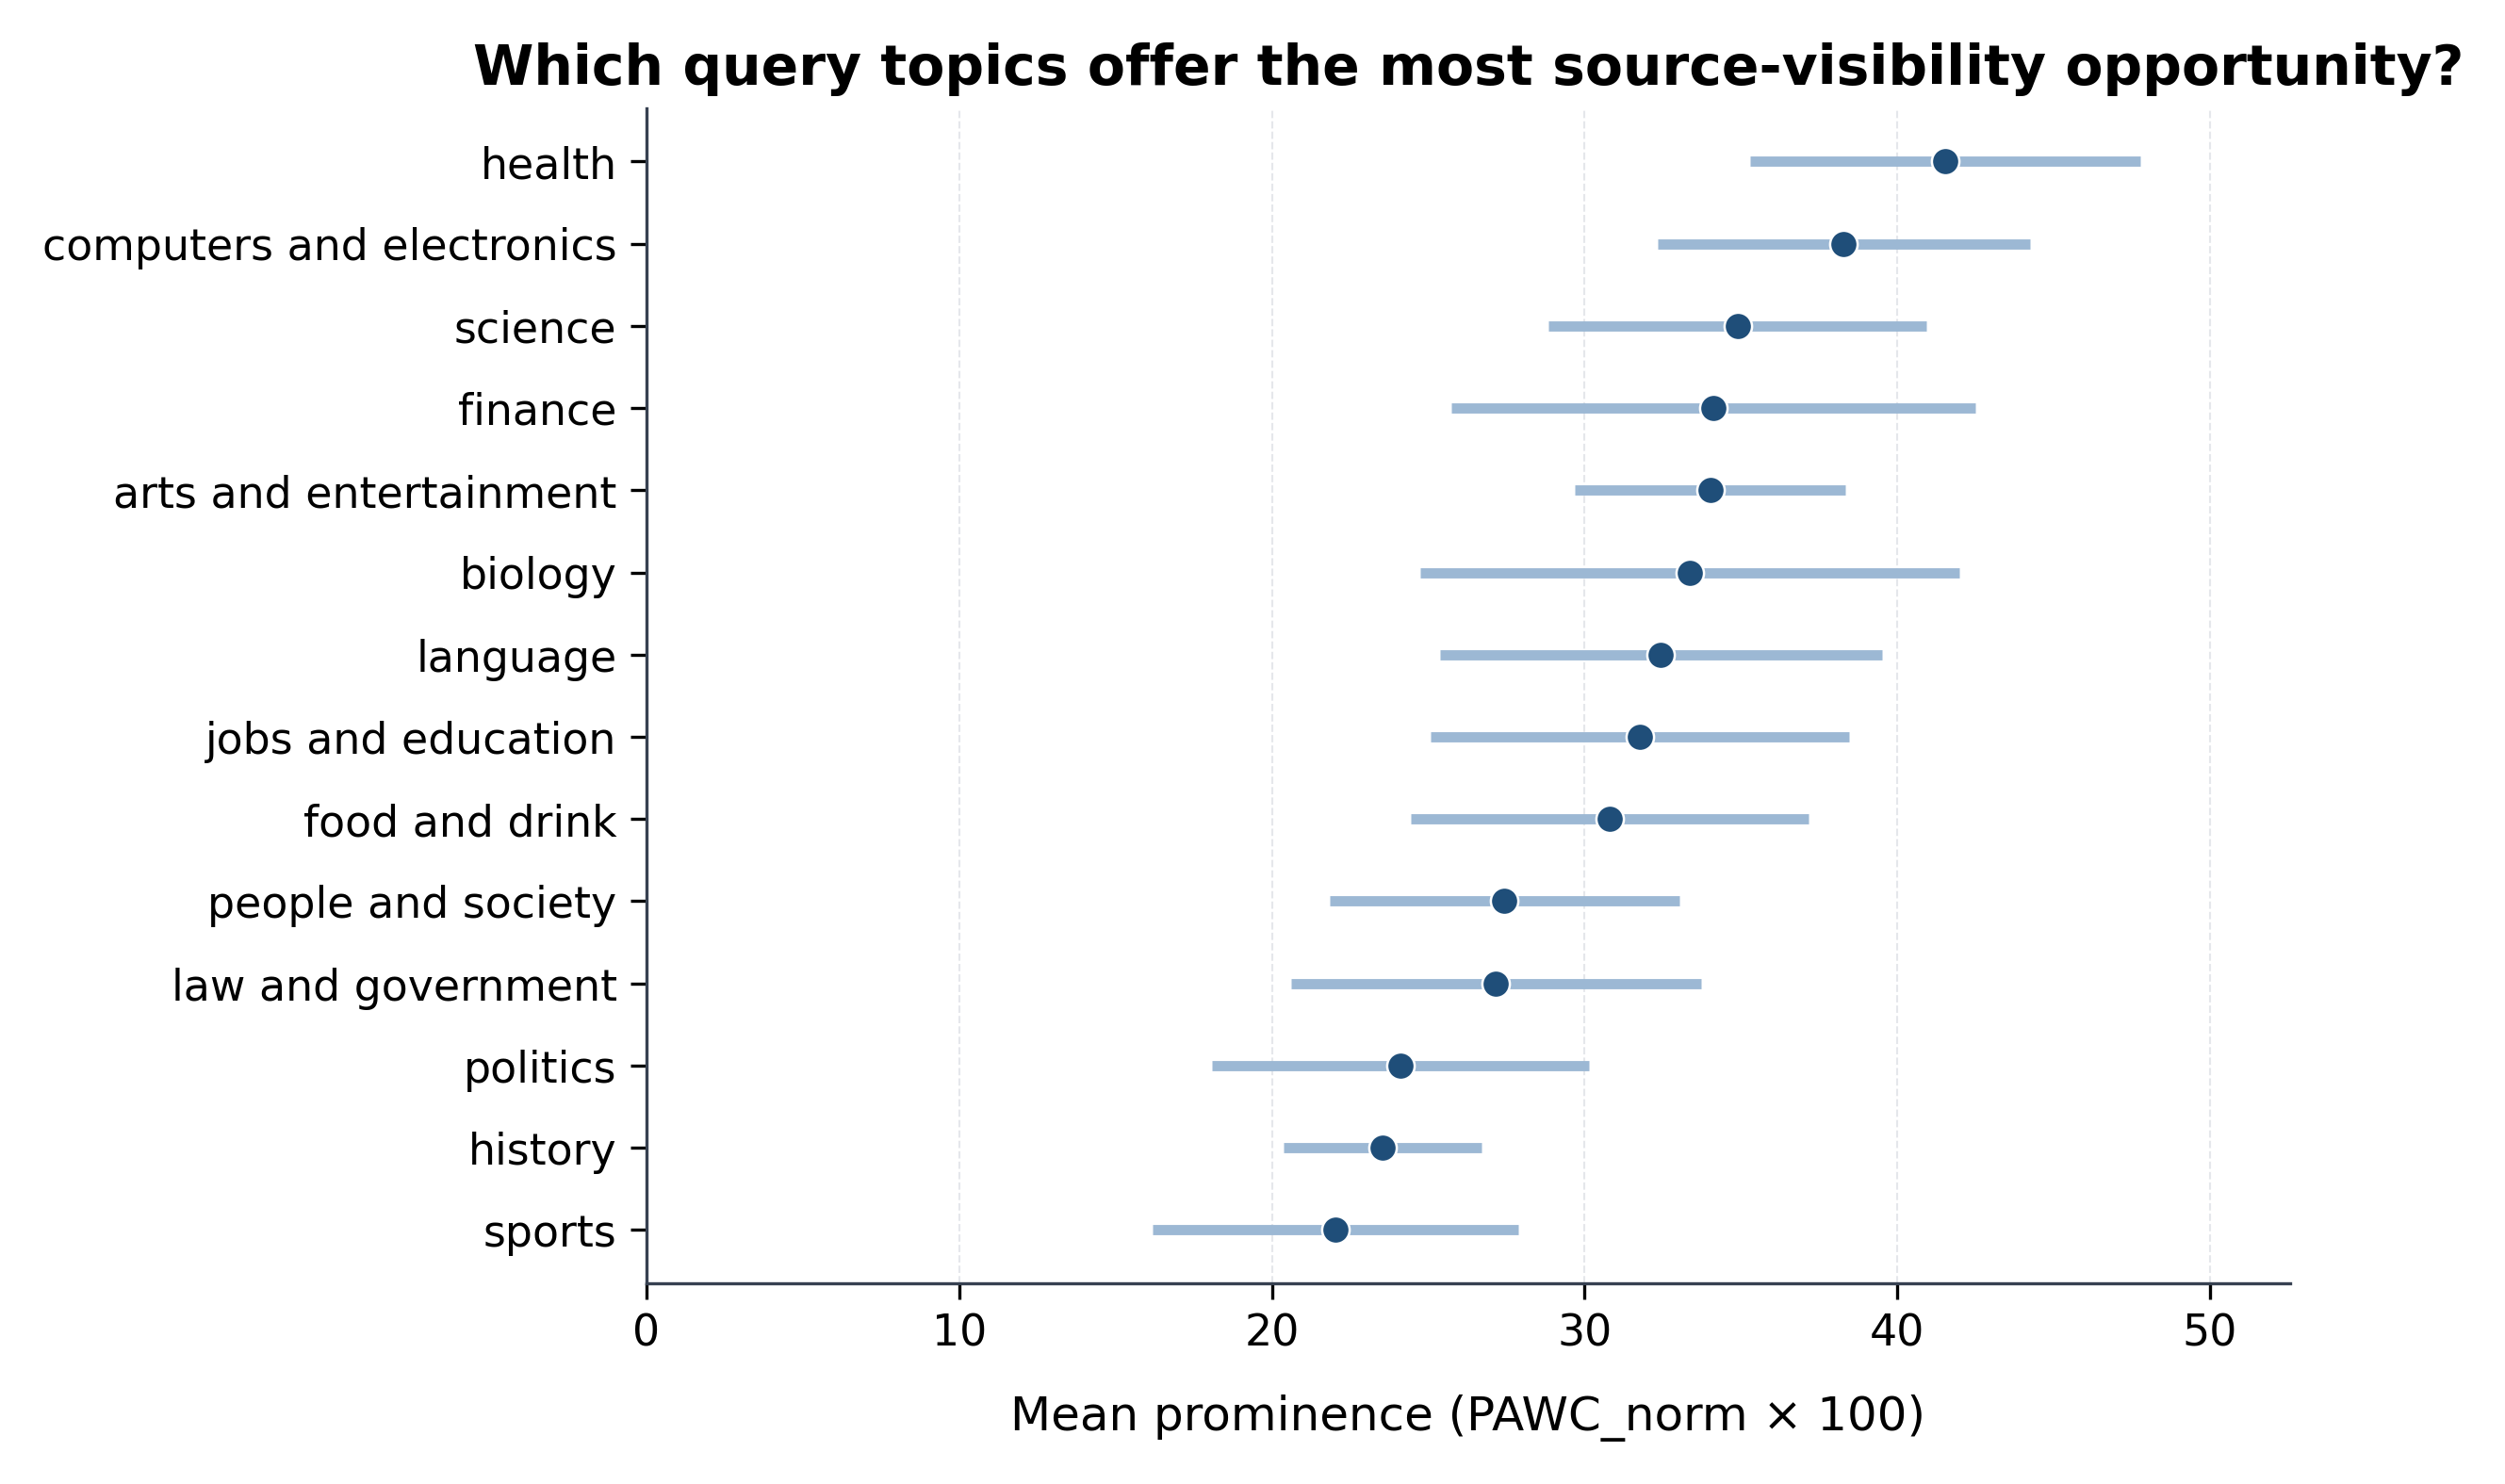

In [2]:
# D1 · Mean PAWC_norm by query topic domain — horizontal dot plot, 95% CI ACROSS QUERIES within each topic.
#      Query-level means (avg engine cells per query, NaN->0). Well-powered topics (n>=8 queries), sorted desc.
def _ci(x):
    x = np.asarray(x); n = len(x)
    return (x.mean(), 1.96*x.std(ddof=1)/np.sqrt(n)) if n > 1 else (x.mean(), 0.0)
cad_q = cad.groupby("query_id").p.mean().rename("qp").reset_index().merge(QDOM, on="query_id")
stats = (cad_q[cad_q.query_domain.isin(WELL_POWERED)].groupby("query_domain").qp
         .apply(lambda s: pd.Series(_ci(s.values), index=["mean","ci"])).unstack()
         .sort_values("mean", ascending=False))                  # descending: highest topic at top
labels = list(stats.index)                                       # topic only; per-topic n moves to the caption
m100 = stats["mean"].values*100; c100 = stats["ci"].values*100   # DISPLAY-ONLY 0-100 index (values unchanged)
y = np.arange(len(stats))
DOT_COLOUR, CI_COLOUR = "#1F4E79", "#9CB8D4"                      # sequential teal ramp: dark dot, light CI (topic-level, not engine)
fig, ax = plt.subplots(figsize=(7.5, 5.4))
ax.hlines(y, m100 - c100, m100 + c100, color=CI_COLOUR, linewidth=2.6, zorder=2)              # horizontal 95% CI
ax.plot(m100, y, "o", color=DOT_COLOUR, markersize=7, markeredgecolor="white",
        markeredgewidth=0.6, zorder=3)                                                        # mean point
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()                               # highest topic at top
ax.set_xlabel("Mean prominence (PAWC_norm × 100)")
ax.set_title("Which query topics offer the most source-visibility opportunity?")
ax.set_xlim(0, (m100 + c100).max()*1.10)
apply_style(ax); ax.grid(False)                                                               # clear the y-grid from apply_style
ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--"); ax.set_axisbelow(True) # light vertical gridlines
# health (top) and sports (bottom) CIs are visibly non-overlapping — the headline; annotate nothing else.
base = "fig_domain_rq1_d1_pawcnorm_by_query_domain"
for ext in ("png", "pdf"): fig.savefig(f"../../figures/scaleup/{base}.{ext}")                 # requested target
savefig(fig, base)                                                                            # keep figures/scaleup/domain/ in sync

**Key analysis (SEO/GEO).** Source-visibility opportunity is strongly topic-dependent. Among well-powered
topics, **health is highest (0.415)** and **sports lowest (0.220)** — a ~1.9× spread, and the two confidence
intervals do not overlap, so the gap is real. The high band is factual/technical — health, computers &
electronics (0.383), science (0.349), finance (0.341) — where engines reliably reach for and surface sources.
The low band is current-events and cultural — politics (0.241), history (0.235), sports (0.220) — where answers
lean on model memory and cite less. Adjacent topics in the middle sit within each other's intervals, so read the
**top-vs-bottom band split**, not the fine-grained ranking. **Action:** concentrate source-rich, citable content
in health, tech, science and finance, where engines actually surface sources; in sports/politics/history the
prominence ceiling is structurally low, so compete on freshness and being the canonical reference rather than
expecting heavy citation.

### RQ1 · D2 — Is the engine prominence ranking stable across query topics?

Per-topic prominence **leader** for the 14 well-powered topics: each marker is filled with the single engine
that surfaces sources most (highest mean PAWC_norm), in that engine's colour only — no border. A **split marker**
flags a genuine near-tie, where the leader's mean falls inside the runner-up engine's 95% CI, so no false single
winner is implied. Tests whether Perplexity's overall lead is universal or whether other engines overtake it.

saved fig_domain_rq1_d2_engine_by_domain_heatmap
also saved fig_domain_rq1_d2_engine_by_domain_heatmap -> figures/scaleup/


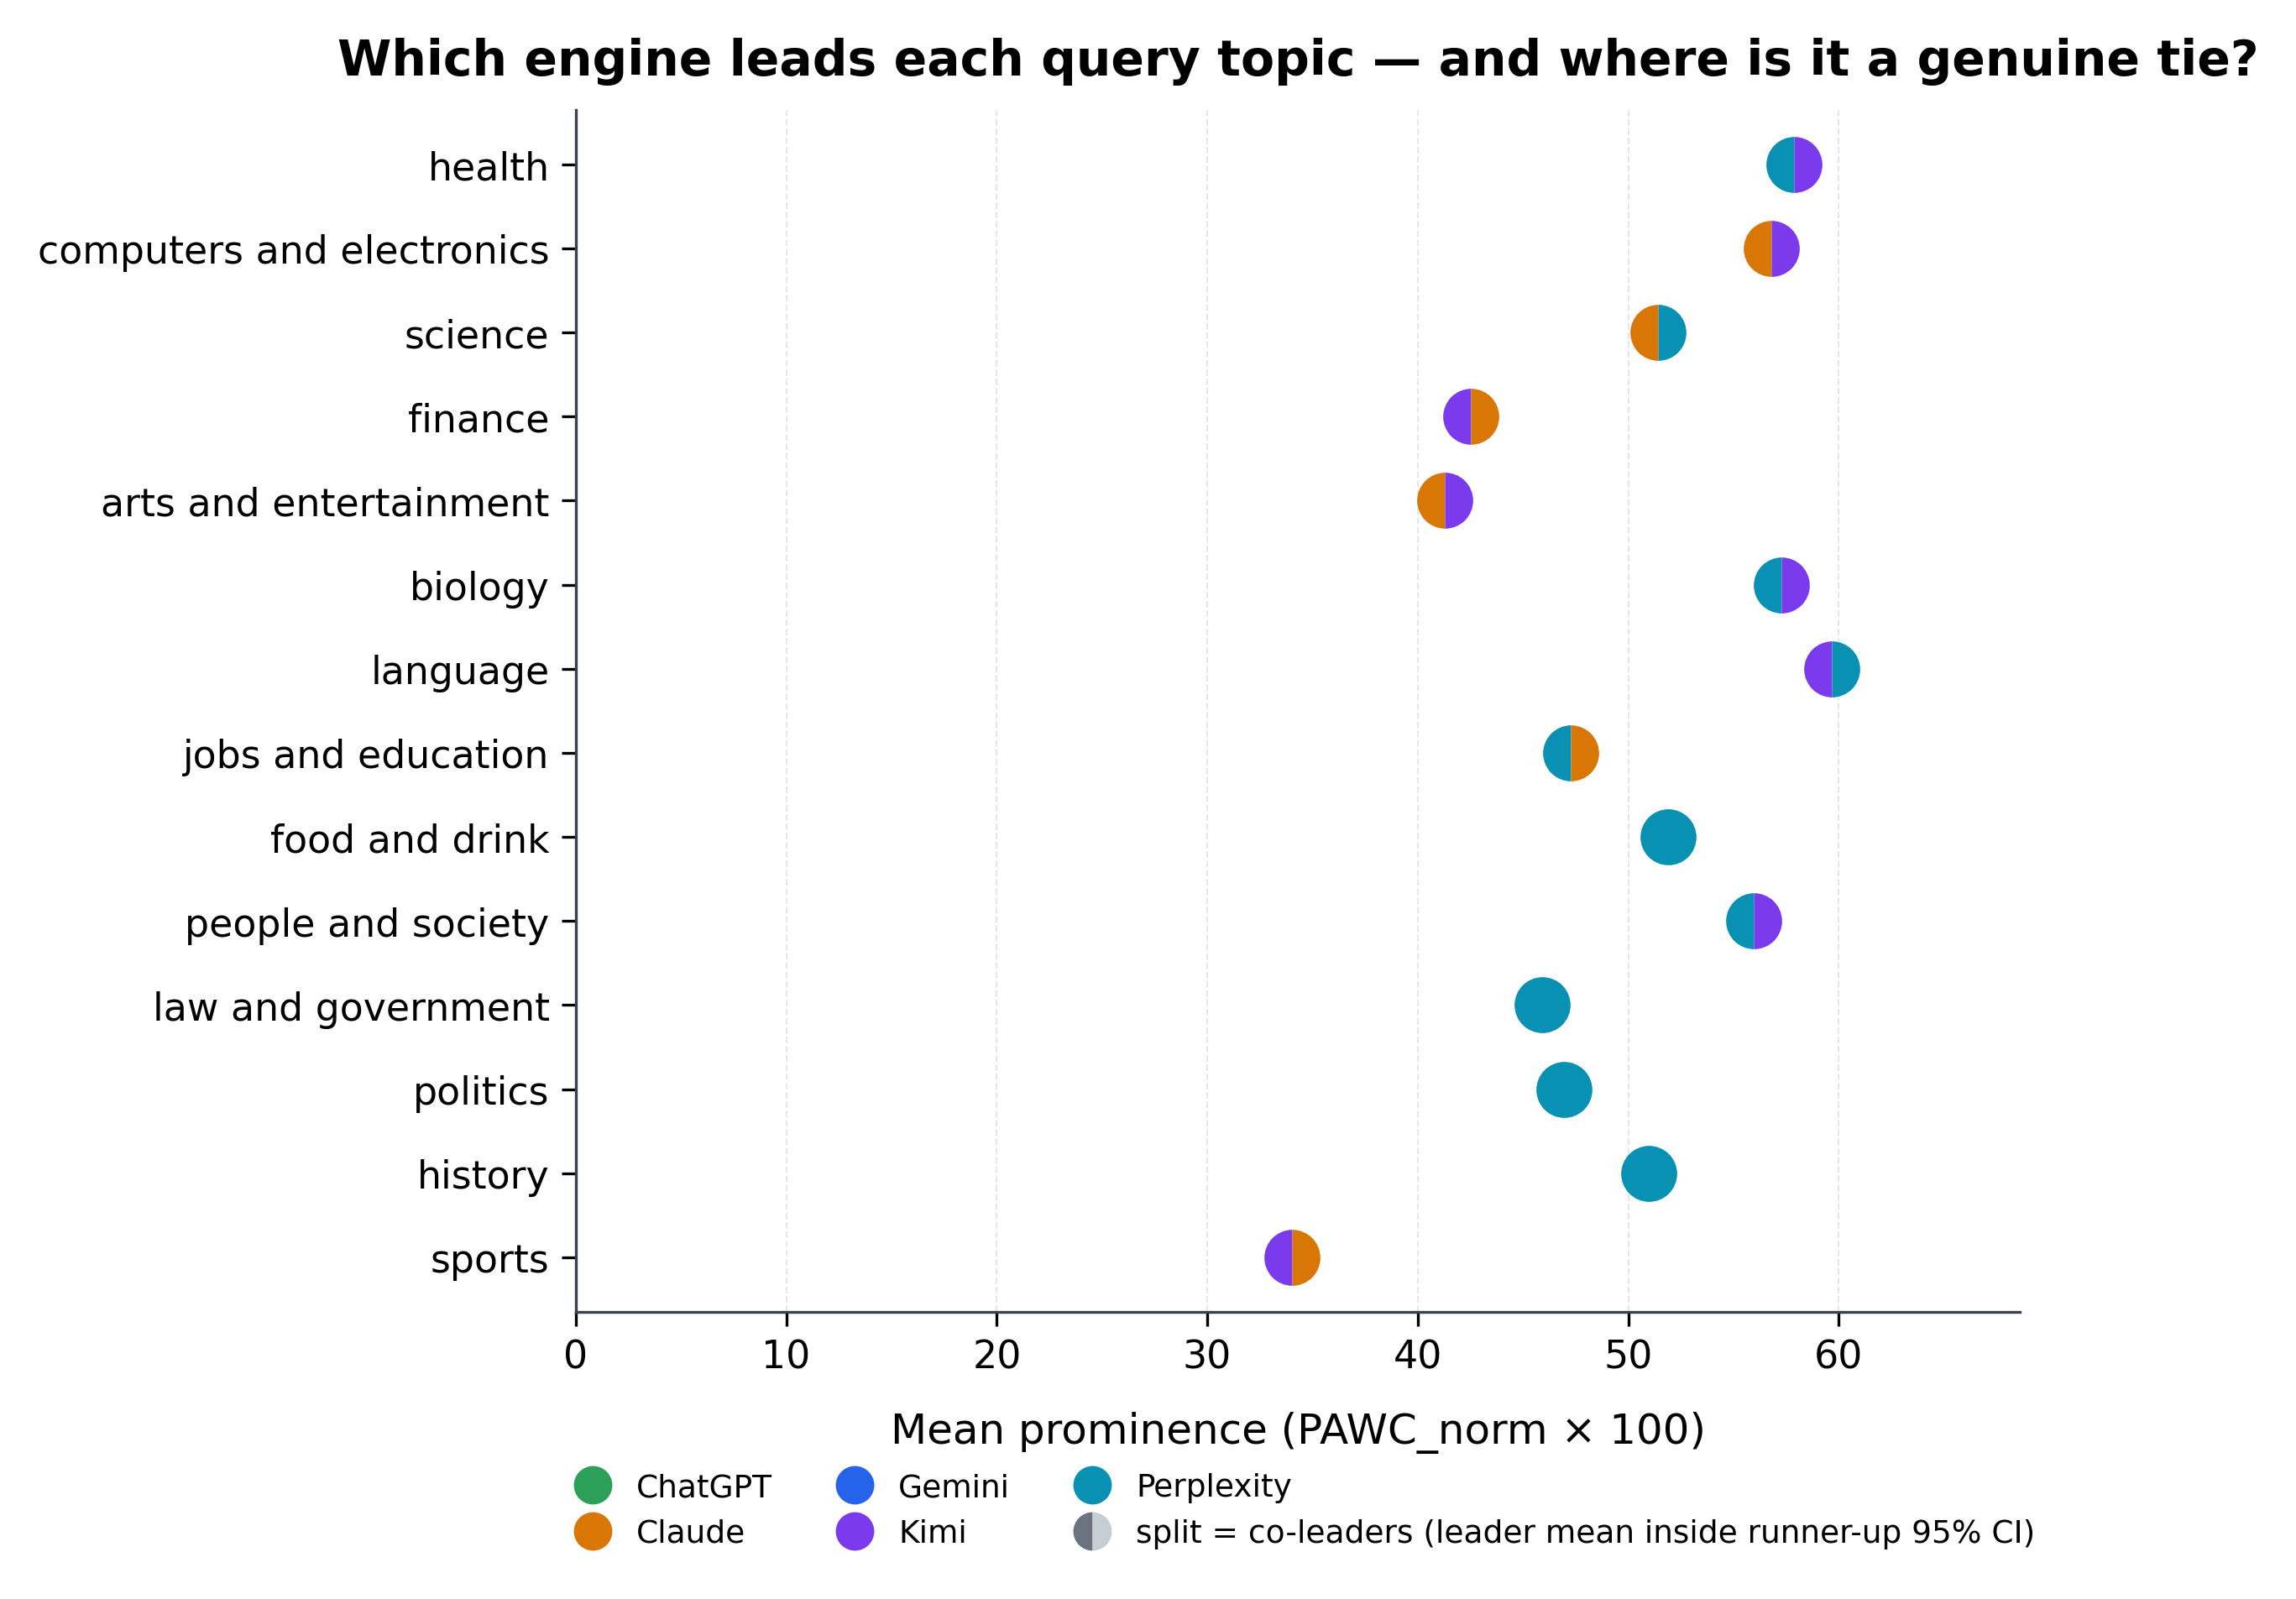

In [3]:
# D2 · Per-topic prominence LEADER — which single engine surfaces sources most in each topic.
# Each topic's marker is filled with the LEADING engine's colour only (no border, so nothing reads as a 2nd winner).
# A split marker flags a genuine near-tie: the leader's mean falls inside the runner-up engine's 95% CI ->
# "co-leaders", so we never imply a confident single winner where the data can't support one.
# TOPIC_ORDER: ONE shared row order for the topic figures (this fig + D12). Descending topic-level prominence,
# reusing the Fig-D1 topic-mean series; set here because this cell runs before D12, which reuses the same list.
TOPIC_ORDER = stats["mean"].sort_values(ascending=False).index.tolist()

def _ci_half(x):                                             # 95% CI half-width of a mean, across the topic's query cells
    x = np.asarray(x); n = len(x)
    return 1.96*x.std(ddof=1)/np.sqrt(n) if n > 1 else 0.0

rows = []
for t in TOPIC_ORDER:
    sub = cad[cad.query_domain == t]
    est = {e: (sub[sub.engine == e].p.mean()*100, _ci_half(sub[sub.engine == e].p.values)*100) for e in ENGINE_ORDER}
    L, R = sorted(ENGINE_ORDER, key=lambda e: est[e][0], reverse=True)[:2]   # leader, runner-up by mean
    mL = est[L][0]; mR, cR = est[R]
    rows.append(dict(topic=t, leader=L, runner=R, mL=mL, co=bool(mL <= mR + cR)))  # co = leader mean inside runner-up 95% CI
LEAD = pd.DataFrame(rows).set_index("topic").loc[TOPIC_ORDER]

fig, ax = plt.subplots(figsize=(7.4, 6.2))
for i, t in enumerate(TOPIC_ORDER):
    r = LEAD.loc[t]
    if r.co:                                                # split circle: left half = leader, right half = runner-up
        ax.plot(r.mL, i, marker="o", markersize=16, fillstyle="left", markeredgecolor="none",
                markerfacecolor=ENGINE_COLOURS[r.leader], markerfacecoloralt=ENGINE_COLOURS[r.runner], zorder=3)
    else:                                                   # solid fill = sole, statistically clear leader
        ax.plot(r.mL, i, marker="o", markersize=16, fillstyle="full", markeredgecolor="none",
                markerfacecolor=ENGINE_COLOURS[r.leader], zorder=3)
ax.set_yticks(range(len(TOPIC_ORDER))); ax.set_yticklabels(TOPIC_ORDER); ax.invert_yaxis()  # top prominence topic at top
ax.set_xlabel("Mean prominence (PAWC_norm × 100)")
ax.set_title("Which engine leads each query topic — and where is it a genuine tie?", pad=10)
ax.set_xlim(0, LEAD.mL.max()*1.15)
apply_style(ax); ax.grid(False)
ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--"); ax.set_axisbelow(True)  # light vertical gridlines
eng_handles = [Line2D([0], [0], marker="o", linestyle="none", markersize=11, markeredgecolor="none",
                      markerfacecolor=ENGINE_COLOURS[e], label=ENGINE_LABELS[e]) for e in ENGINE_ORDER]
split_handle = Line2D([0], [0], marker="o", linestyle="none", markersize=11, fillstyle="left", markeredgecolor="none",
                      markerfacecolor=COLOUR_NEUTRAL, markerfacecoloralt="#C7CDD4",
                      label="split = co-leaders (leader mean inside runner-up 95% CI)")
ax.legend(handles=eng_handles + [split_handle], loc="upper center", bbox_to_anchor=(0.5, -0.11),
          ncol=3, frameon=False, fontsize=9, handletextpad=0.4, columnspacing=1.6)
base = "fig_domain_rq1_d2_engine_by_domain_heatmap"                          # basename kept stable (Fig-5 identity)
savefig(fig, base)                                                           # canonical figures/scaleup/domain/
for ext in ("png", "pdf"): fig.savefig(f"../../figures/scaleup/{base}.{ext}")  # requested target
print("also saved", base, "-> figures/scaleup/")

**Key analysis (SEO/GEO).** Read one leader per topic — but most are near-ties. Perplexity posts the top mean
in 8 of 14 topics, yet its lead is **statistically clear in only 4**: food & drink, law & government, politics and
history (solid markers), where its mean sits outside the runner-up's 95% CI. In the other **10 topics the leader's
margin falls inside the runner-up's interval**, so they are **co-leaders** (split markers): Claude posts the top
mean in science, computers & electronics and arts, and Kimi in finance, language and sports — but none by a reliable
margin. **Action:** treat Perplexity as the safe default everywhere and the confirmed leader in current-events and
lifestyle topics; where a marker is split, the two engines are effectively tied on prominence, so choose on other
factors rather than a fragile per-topic edge. The five-fold headline gap is real, but topic-level leadership is not.

### RQ1 · D3 — Are authoritative source types cited in earlier, more prominent positions?

Distribution of **citation position** (1 = first) by source domain type, top 15 by citation volume, ordered
by mean position. Because PAWC weights earlier citations more heavily, position is a direct prominence proxy.

saved fig_domain_rq1_d3_position_by_domain_type_appendix


also saved fig_domain_rq1_d3_position_by_domain_type_appendix -> figures/scaleup/ (beyond-10: 10.6%)
saved fig_domain_rq1_d3_position_by_domain_type


saved fig_domain_rq1_d3_position_by_domain_type_by_engine


also saved fig_domain_rq1_d3_position_by_domain_type_by_engine -> figures/scaleup/


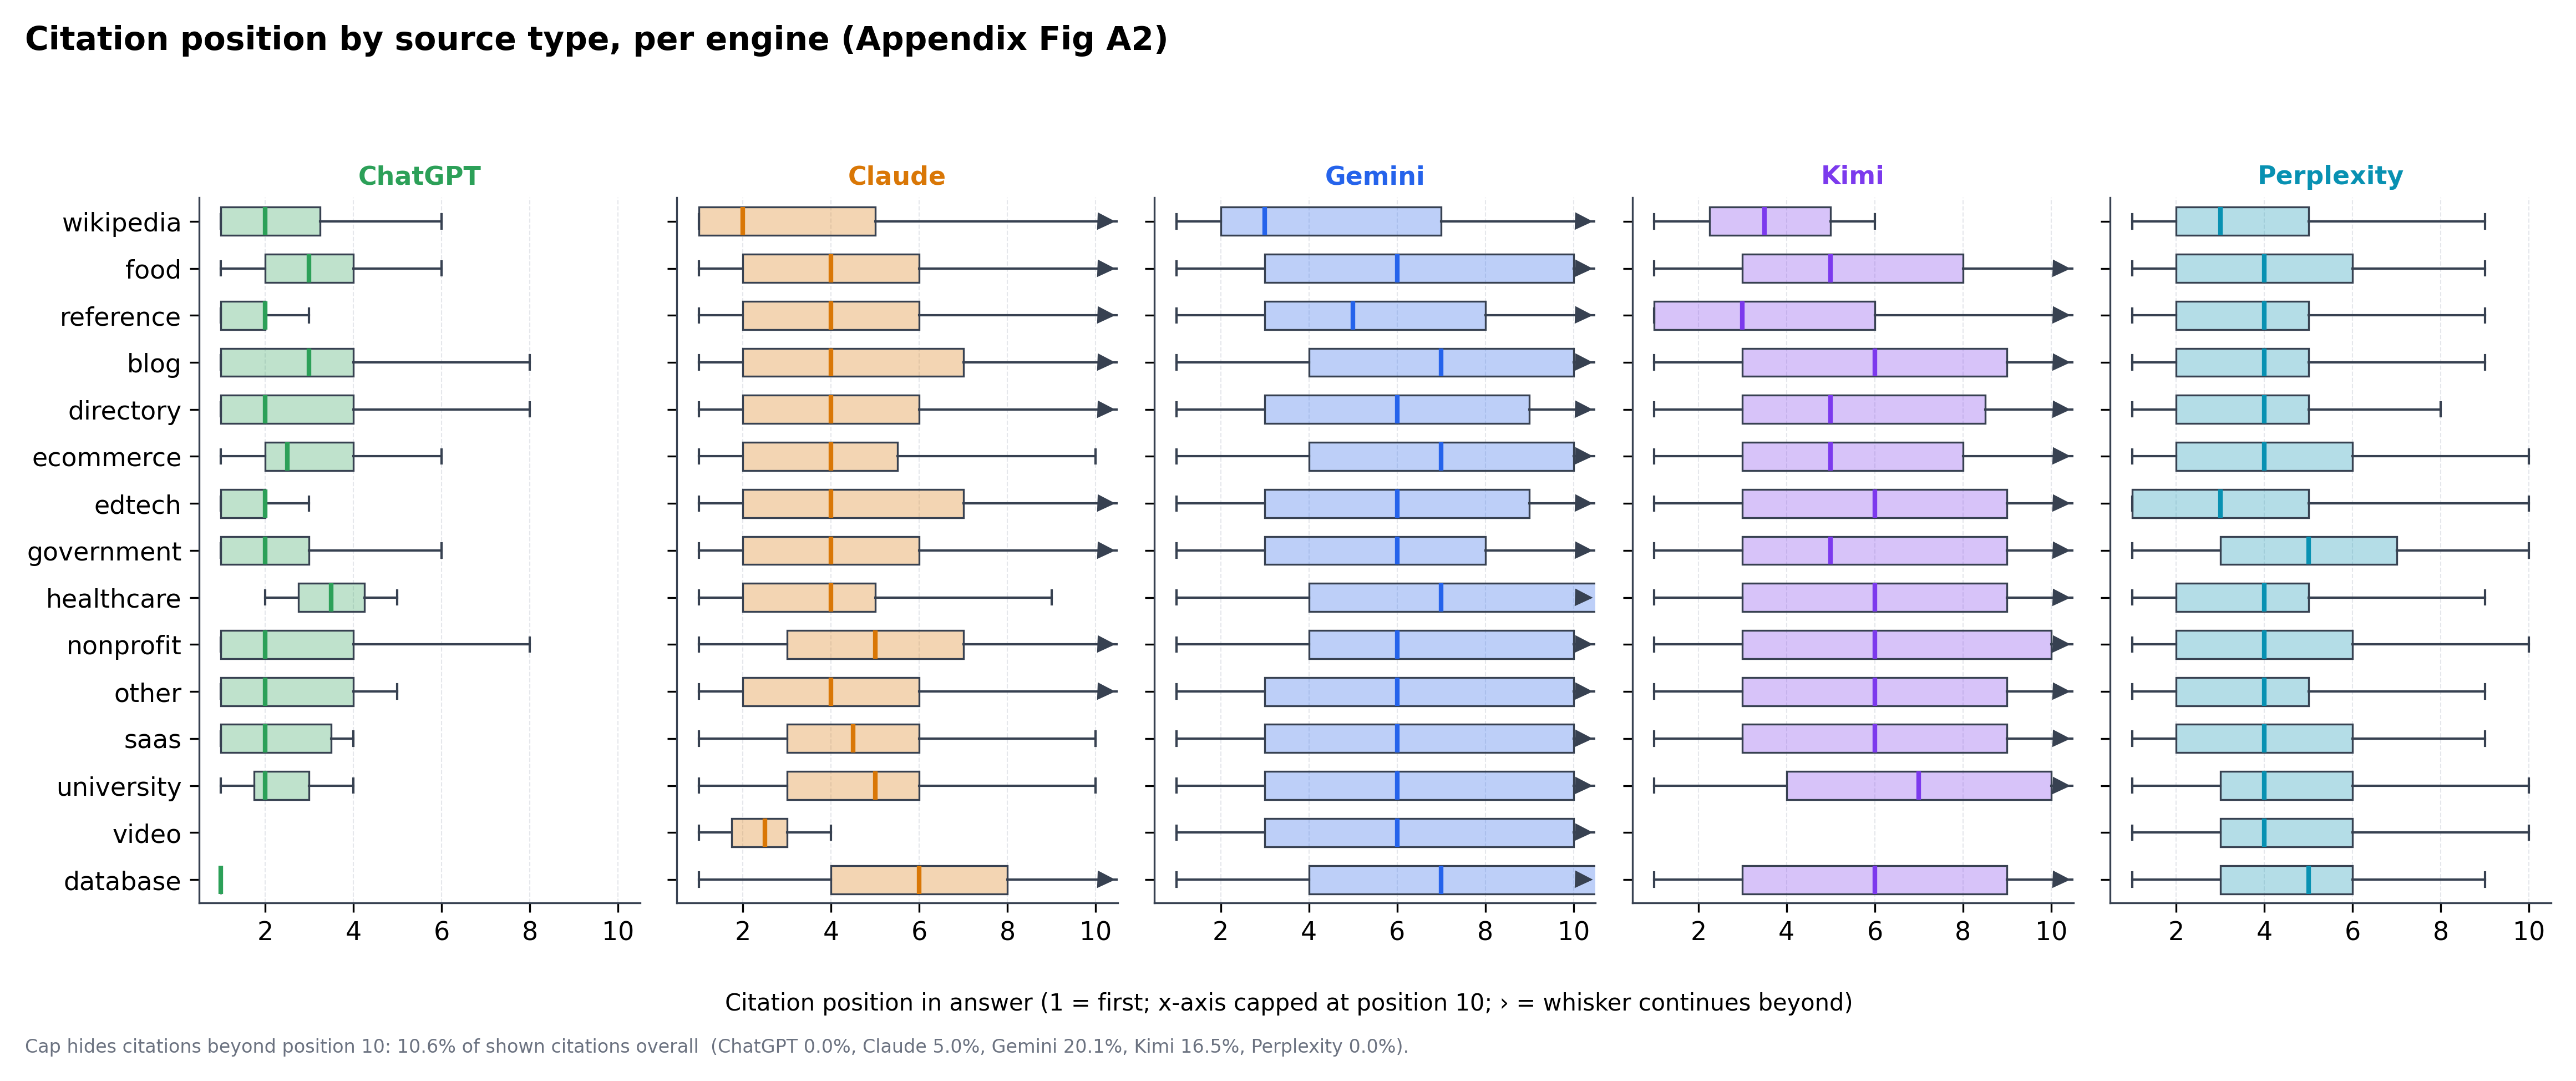

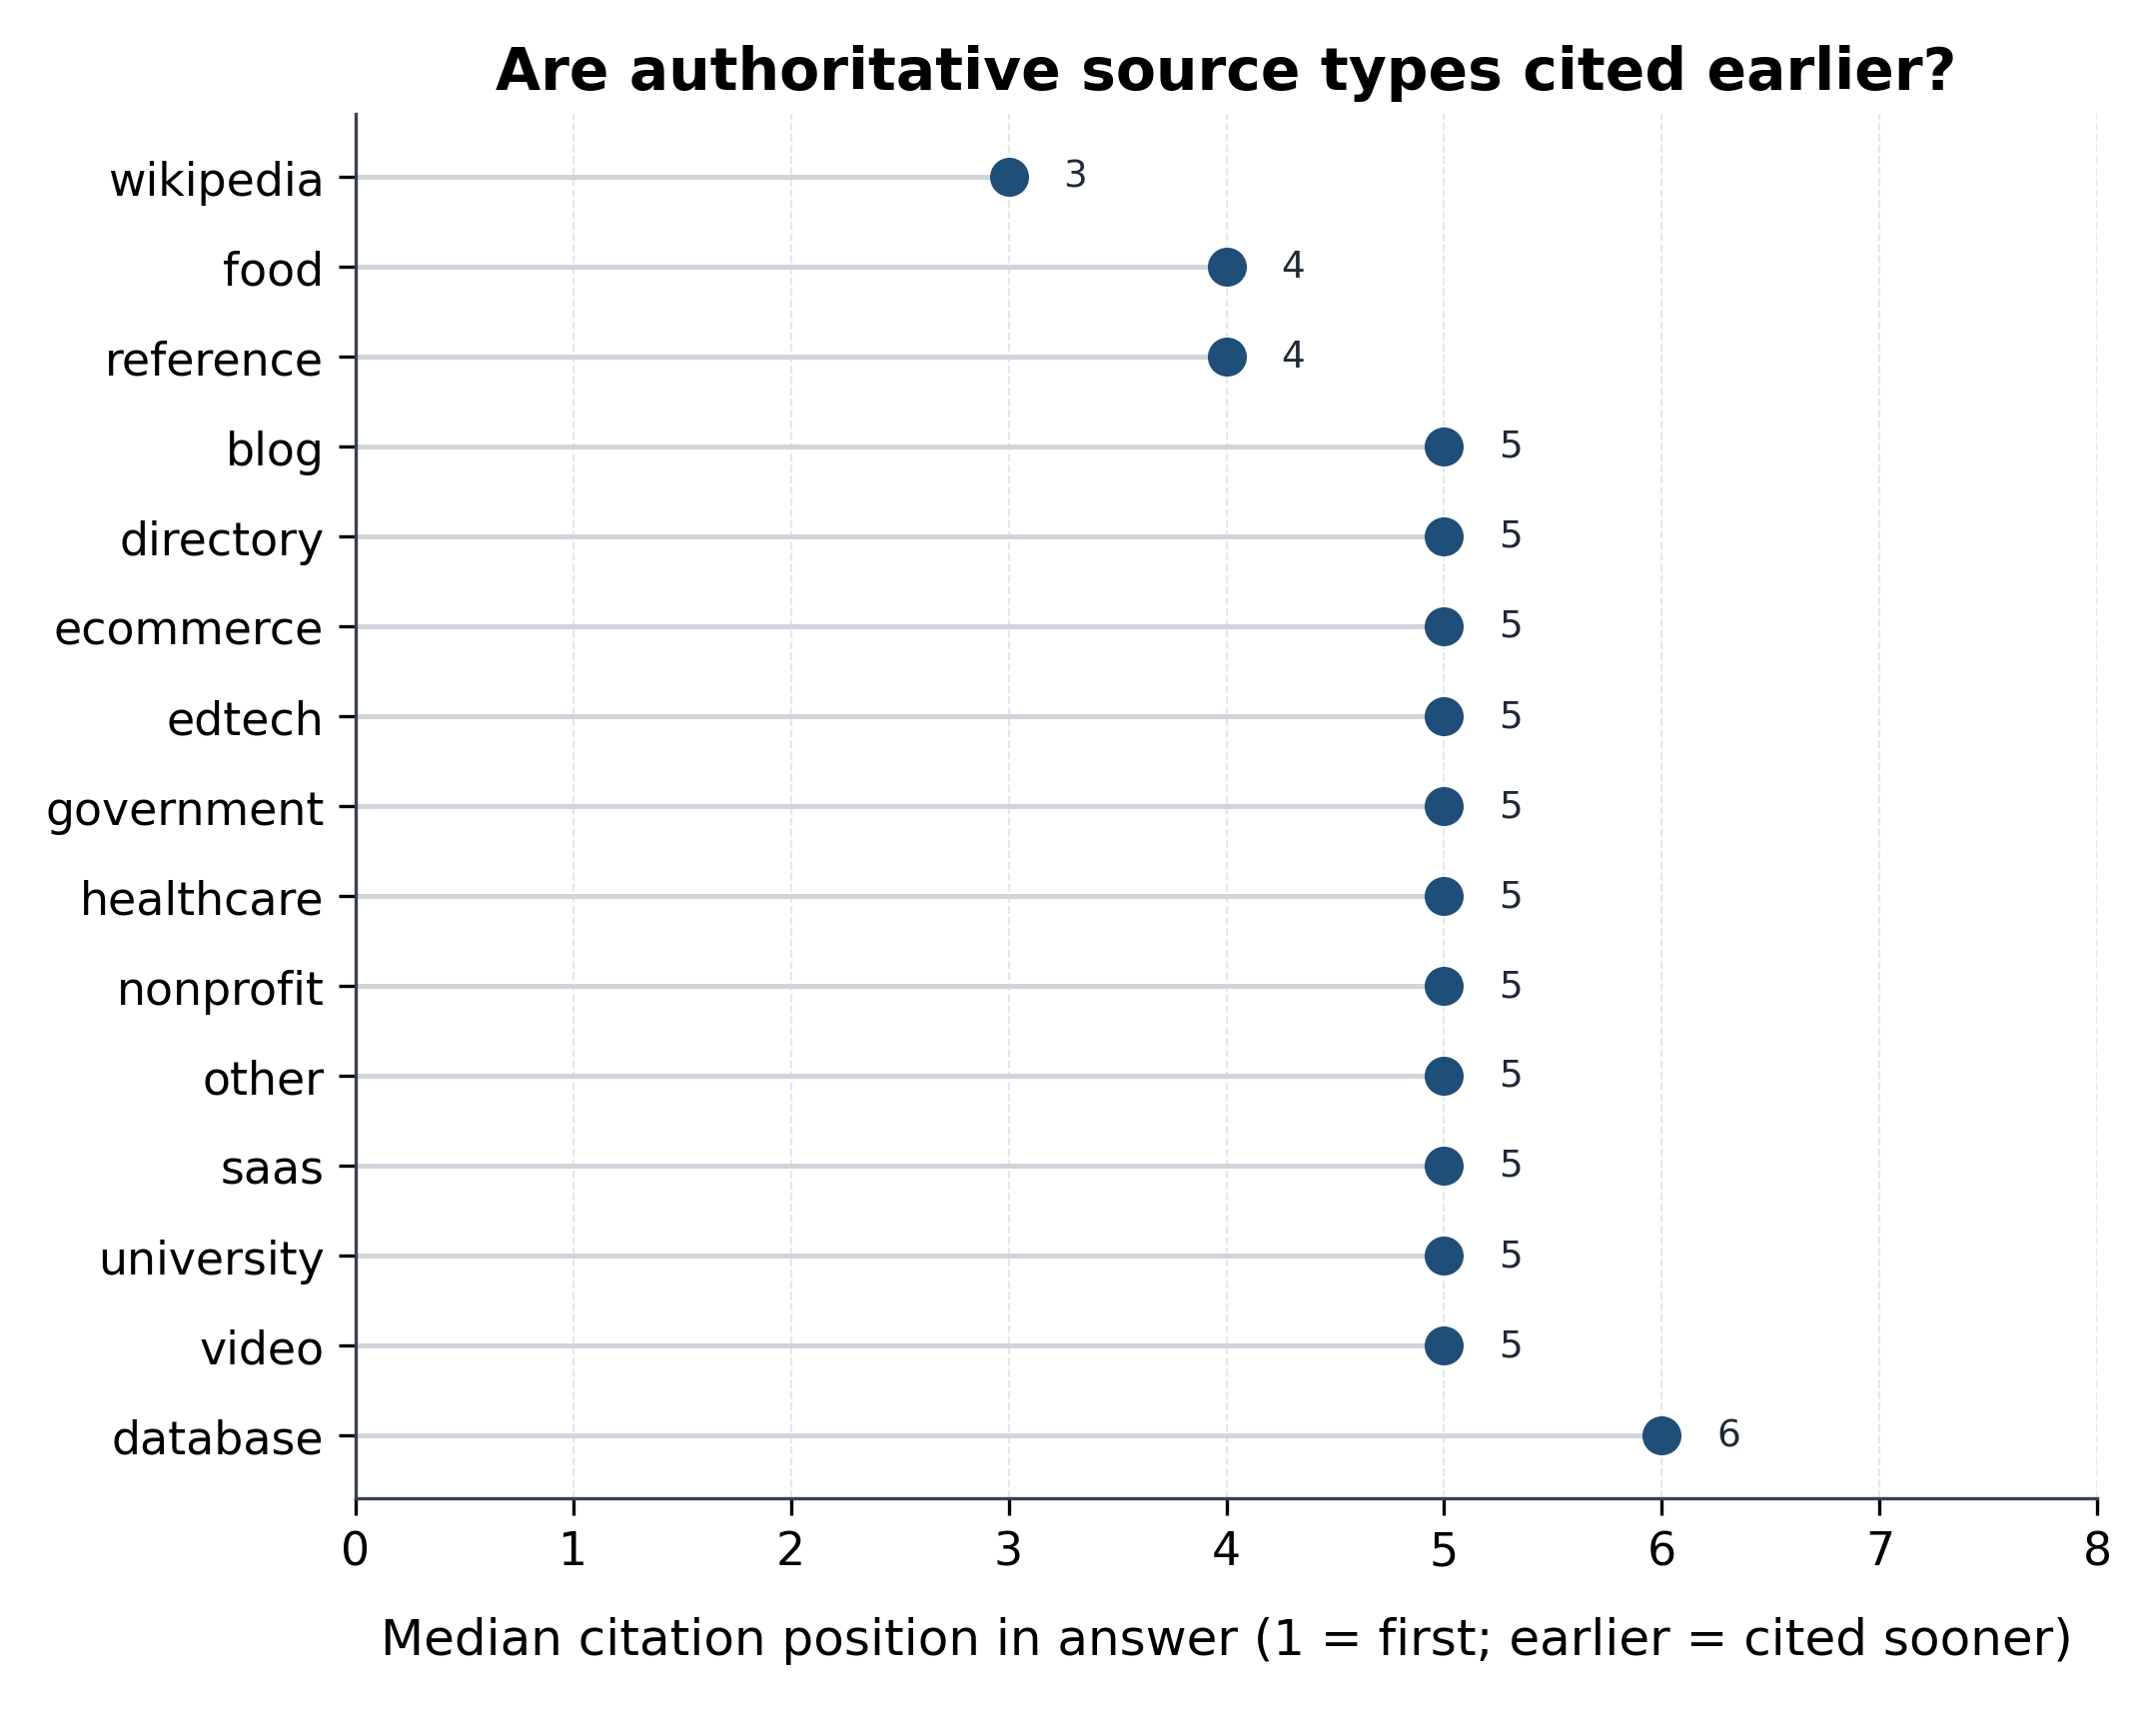

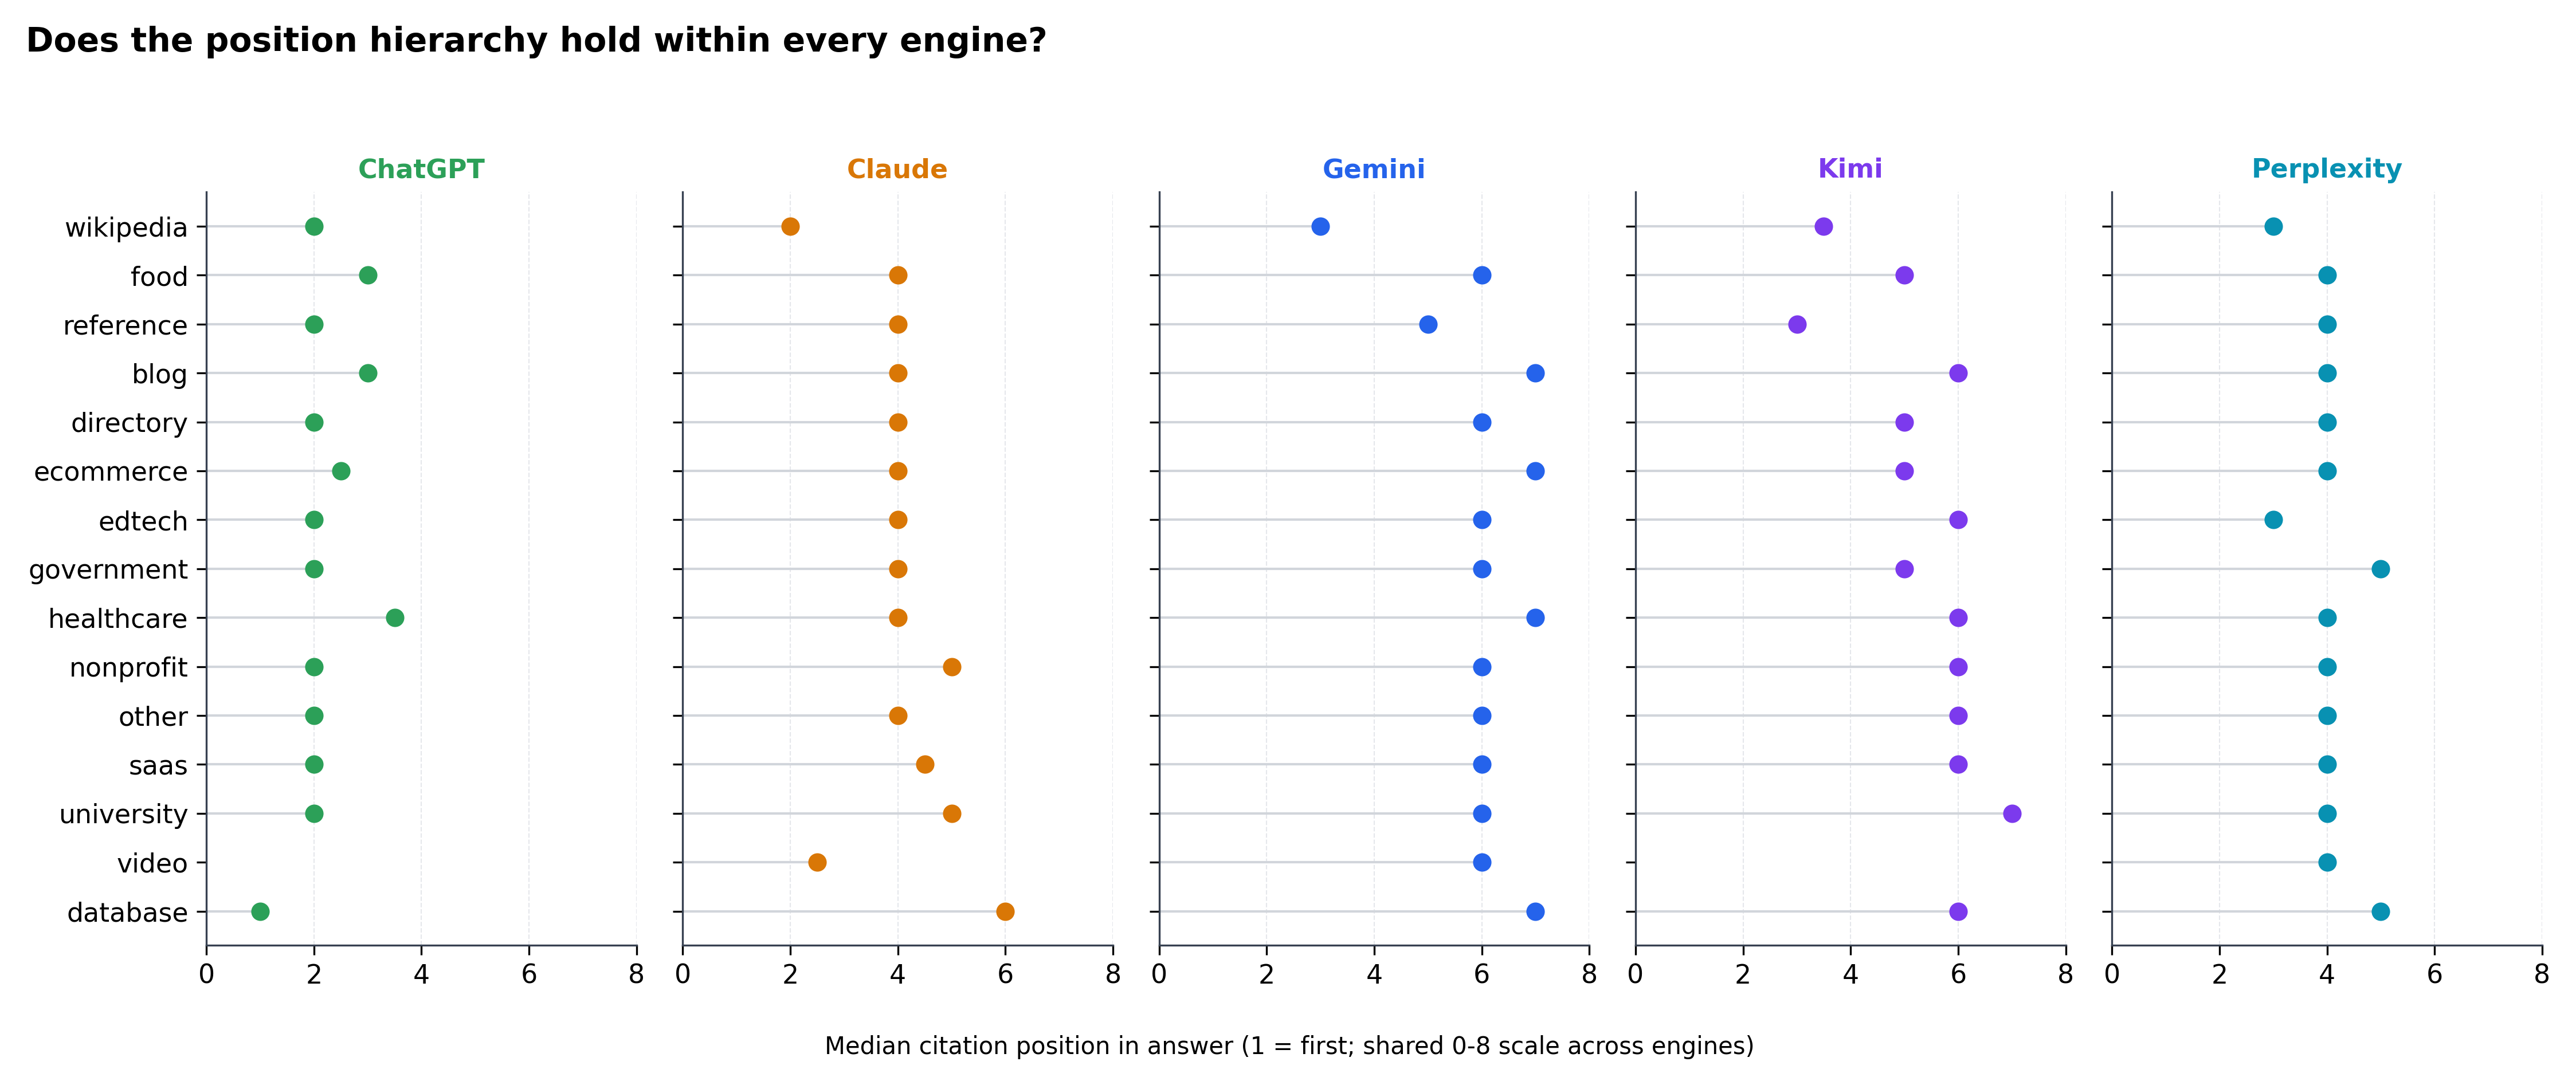

In [4]:
# D3 · Citation position by source domain_type (top-15 by volume). Lower position = cited earlier.
#      Appendix (Fig A2): per-engine box-plot distribution, x-axis capped at 10 for cross-engine comparability.
#      Main figure: sorted dot plot of the median position per type.
#      Per-engine small multiples (medians): cross-engine constancy check for the "position barely shifts" claim.
dtc   = cit.domain_type.value_counts()
topN  = dtc.head(15).index.tolist()

# --- Appendix (Fig A2): per-engine box plots of citation position by source type. Shared top-15 types and
#     pooled-median ordering; x-axis CAPPED AT position 10 on every panel so medians and IQRs line up across
#     engines (all medians <= 7, so no median is hidden). Footer discloses the % of shown citations beyond 10. ---
CAP = 10
order_box = cit[cit.domain_type.isin(topN)].groupby("domain_type").position.median().sort_values().index.tolist()
_shown = cit[cit.domain_type.isin(topN)]
beyond_all  = (_shown.position > CAP).mean() * 100
beyond_by_e = {e: (_shown[_shown.engine == e].position > CAP).mean() * 100 for e in ENGINE_ORDER}
def _upper_whisker(v):                                    # matplotlib default whisker: last point within Q3 + 1.5*IQR
    v = np.asarray(v, float); v = v[~np.isnan(v)]
    if v.size == 0: return np.nan
    q1, q3 = np.percentile(v, [25, 75]); inside = v[v <= q3 + 1.5*(q3 - q1)]
    return inside.max() if inside.size else q3
fig_box, axes_box = plt.subplots(1, 5, figsize=(15.5, 6.4), sharey=True)
for ax_b, e in zip(axes_box, ENGINE_ORDER):
    data = [cit[(cit.engine == e) & (cit.domain_type == dt)].position.values for dt in order_box]
    bp = ax_b.boxplot(data, vert=False, widths=0.6, patch_artist=True, showfliers=False)
    for b in bp["boxes"]:     b.set(facecolor=mpl.colors.to_rgba(ENGINE_COLOURS[e], 0.30), edgecolor="#374151", linewidth=0.8)
    for md_ in bp["medians"]: md_.set(color=ENGINE_COLOURS[e], linewidth=2)
    for wk in bp["whiskers"] + bp["caps"]: wk.set(color="#374151", linewidth=1)
    for i, dt in enumerate(order_box):                    # explicit '>' at the cap wherever the whisker runs past 10
        if _upper_whisker(data[i]) > CAP:
            ax_b.plot(CAP + 0.22, i + 1, marker=">", color="#374151", markersize=6, zorder=4)
    ax_b.set_yticks(range(1, len(order_box) + 1)); ax_b.set_yticklabels(list(order_box))
    ax_b.invert_yaxis()
    ax_b.set_xlim(0.5, CAP + 0.5); ax_b.set_xticks(range(2, CAP + 1, 2))
    ax_b.set_title(ENGINE_LABELS[e], fontsize=11, color=ENGINE_COLOURS[e])
    apply_style(ax_b); ax_b.yaxis.grid(False); ax_b.xaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
for ax_b in axes_box[1:]:
    ax_b.tick_params(axis="y", labelleft=False)
fig_box.suptitle("Citation position by source type, per engine (Appendix Fig A2)", x=0.01, ha="left",
                 fontsize=14, fontweight="bold")
fig_box.text(0.5, 0.055, f"Citation position in answer (1 = first; x-axis capped at position {CAP}; › = whisker continues beyond)",
             ha="center", fontsize=10)
fig_box.text(0.01, 0.012,
             "Cap hides citations beyond position 10: "
             f"{beyond_all:.1f}% of shown citations overall  ("
             + ", ".join(f"{ENGINE_LABELS[e]} {beyond_by_e[e]:.1f}%" for e in ENGINE_ORDER) + ").",
             ha="left", va="bottom", fontsize=8, color="#6B7280")
fig_box.tight_layout(rect=[0, 0.09, 1, 0.93])
savefig(fig_box, "fig_domain_rq1_d3_position_by_domain_type_appendix")                       # canonical domain/
for ext in ("png", "pdf"):                                                                    # requested target
    fig_box.savefig(f"../../figures/scaleup/fig_domain_rq1_d3_position_by_domain_type_appendix.{ext}")
print(f"also saved fig_domain_rq1_d3_position_by_domain_type_appendix -> figures/scaleup/ (beyond-10: {beyond_all:.1f}%)")

# --- Main: sorted dot plot of the median position (lowest = cited earliest = best, at top) ---
med = cit[cit.domain_type.isin(topN)].groupby("domain_type").position.median().sort_values()
fig, ax = plt.subplots(figsize=(7.5, 6.0))
yy = list(range(len(med)))
ax.hlines(yy, 0, med.values, color="#D1D5DB", linewidth=1.2, zorder=1)
ax.scatter(med.values, yy, s=70, color=COLOUR_PRIMARY, zorder=3)
for i, v in enumerate(med.values):
    ax.text(v+0.25, i, f"{v:.0f}", va="center", fontsize=9, color="#1F2937")
ax.set_yticks(yy); ax.set_yticklabels(list(med.index))
ax.invert_yaxis()
ax.set_xlabel("Median citation position in answer (1 = first; earlier = cited sooner)")
ax.set_title("Are authoritative source types cited earlier?")
ax.set_xlim(0, med.max()+2)
apply_style(ax); ax.yaxis.grid(False); ax.xaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
savefig(fig, "fig_domain_rq1_d3_position_by_domain_type")

# --- Per-engine small multiples: same top-15 types, same pooled (median) ordering, fixed 0-16
#     x-axis, fixed ENGINE_ORDER/ENGINE_COLOURS. Cross-engine constancy check for the main figure. ---
order_types = med.index.tolist()
fig_eng, axes_eng = plt.subplots(1, 5, figsize=(15.0, 6.2), sharey=True)
med_by_engine = {}
for ax_e, e in zip(axes_eng, ENGINE_ORDER):
    sub = cit[(cit.engine==e) & (cit.domain_type.isin(topN))]
    me = sub.groupby("domain_type").position.median().reindex(order_types)
    med_by_engine[e] = me
    yy_e = np.arange(len(order_types))
    valid = me.notna().values
    ax_e.hlines(yy_e[valid], 0, me.values[valid], color="#D1D5DB", linewidth=1.0, zorder=1)
    ax_e.scatter(me.values[valid], yy_e[valid], s=45, color=ENGINE_COLOURS[e], zorder=3)
    ax_e.set_yticks(yy_e); ax_e.set_yticklabels(list(order_types))
    ax_e.invert_yaxis()
    ax_e.set_xlim(0, 8); ax_e.set_xticks(range(0, 9, 2))   # cap shared scale at 8 (max median = 7) so dots spread
    ax_e.set_title(ENGINE_LABELS[e], fontsize=11, color=ENGINE_COLOURS[e])
    apply_style(ax_e); ax_e.yaxis.grid(False); ax_e.xaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
for ax_e in axes_eng[1:]:
    ax_e.tick_params(axis="y", labelleft=False)
fig_eng.supxlabel("Median citation position in answer (1 = first; shared 0-8 scale across engines)", fontsize=10)
fig_eng.suptitle("Does the position hierarchy hold within every engine?", x=0.01, ha="left", fontsize=14, fontweight="bold")
fig_eng.tight_layout(rect=[0, 0, 1, 0.94])
savefig(fig_eng, "fig_domain_rq1_d3_position_by_domain_type_by_engine")                       # canonical domain/
for ext in ("png", "pdf"):                                                                    # requested target
    fig_eng.savefig(f"../../figures/scaleup/fig_domain_rq1_d3_position_by_domain_type_by_engine.{ext}")
print("also saved fig_domain_rq1_d3_position_by_domain_type_by_engine -> figures/scaleup/")

In [5]:
# Validation · D3 per-engine median position by source type (pooled ordering) + max cross-engine spread
med_table = pd.DataFrame(med_by_engine).reindex(order_types)[ENGINE_ORDER]
med_table["max_spread"] = med_table.max(axis=1) - med_table.min(axis=1)
print("Per-engine median citation position by source domain_type (pooled top-15 ordering):")
print(med_table.round(1).to_string())
print(f"\nOverall max cross-engine spread: {med_table['max_spread'].max():.1f} positions ({med_table['max_spread'].idxmax()})")
spread_ex_chatgpt = (med_table[["claude","gemini","kimi","perplexity"]].max(axis=1)
                     - med_table[["claude","gemini","kimi","perplexity"]].min(axis=1))
print(f"Max spread excluding ChatGPT (thin per-type samples): {spread_ex_chatgpt.max():.1f} positions ({spread_ex_chatgpt.idxmax()})")


Per-engine median citation position by source domain_type (pooled top-15 ordering):
             chatgpt  claude  gemini  kimi  perplexity  max_spread
domain_type                                                       
wikipedia        2.0     2.0     3.0   3.5         3.0         1.5
food             3.0     4.0     6.0   5.0         4.0         3.0
reference        2.0     4.0     5.0   3.0         4.0         3.0
blog             3.0     4.0     7.0   6.0         4.0         4.0
directory        2.0     4.0     6.0   5.0         4.0         4.0
ecommerce        2.5     4.0     7.0   5.0         4.0         4.5
edtech           2.0     4.0     6.0   6.0         3.0         4.0
government       2.0     4.0     6.0   5.0         5.0         4.0
healthcare       3.5     4.0     7.0   6.0         4.0         3.5
nonprofit        2.0     5.0     6.0   6.0         4.0         4.0
other            2.0     4.0     6.0   6.0         4.0         4.0
saas             2.0     4.5     6.0   6.0   

**Key analysis (SEO/GEO).** There is a mild but consistent placement hierarchy. **Wikipedia is cited
earliest (median position 3)**, followed by reference and food sites (median 4); most other types — blogs,
government, edtech, healthcare, nonprofit, university — cluster at median 5, with **databases latest (median 6)**.
Because PAWC front-loads early citations, encyclopedic and reference content earns disproportionate prominence
whenever it is cited, while deep database/long-tail pages, even when cited, sit later and contribute less weight.
**Action:** securing a Wikipedia or canonical-reference footprint is high-leverage — those sources land in the
top, high-weight slots — whereas niche database-style pages need to win on being cited at all, since position
works against them.

**Cross-engine check.** A per-engine view (fig_domain_rq1_d3_position_by_domain_type_by_engine; validation
table above) confirms this hierarchy barely shifts on Claude, Gemini, Kimi and Perplexity — Wikipedia stays
earliest (spread ≤1.5 positions) and the ranking holds within a 3.5-position band elsewhere. ChatGPT is the
exception: its per-type samples are thin (2–267 citations vs hundreds on other engines) and it cites so few
sources per response that positions compress toward 1–3.5 regardless of type, so its apparent "database cited
earliest" reading (median 1, n=10) is a small-sample artefact, not a genuine reversal of the hierarchy.


### RQ1 · D4 — Which source types drive each engine's prominence?

Decomposition of each engine's total PAWC_norm mass by source domain type (top 12 contributors). Each cell is
the **% of that engine's prominence** coming from the source type; each engine's largest contributor is ringed.

saved fig_domain_rq1_d4_pawc_mass_by_domain_type


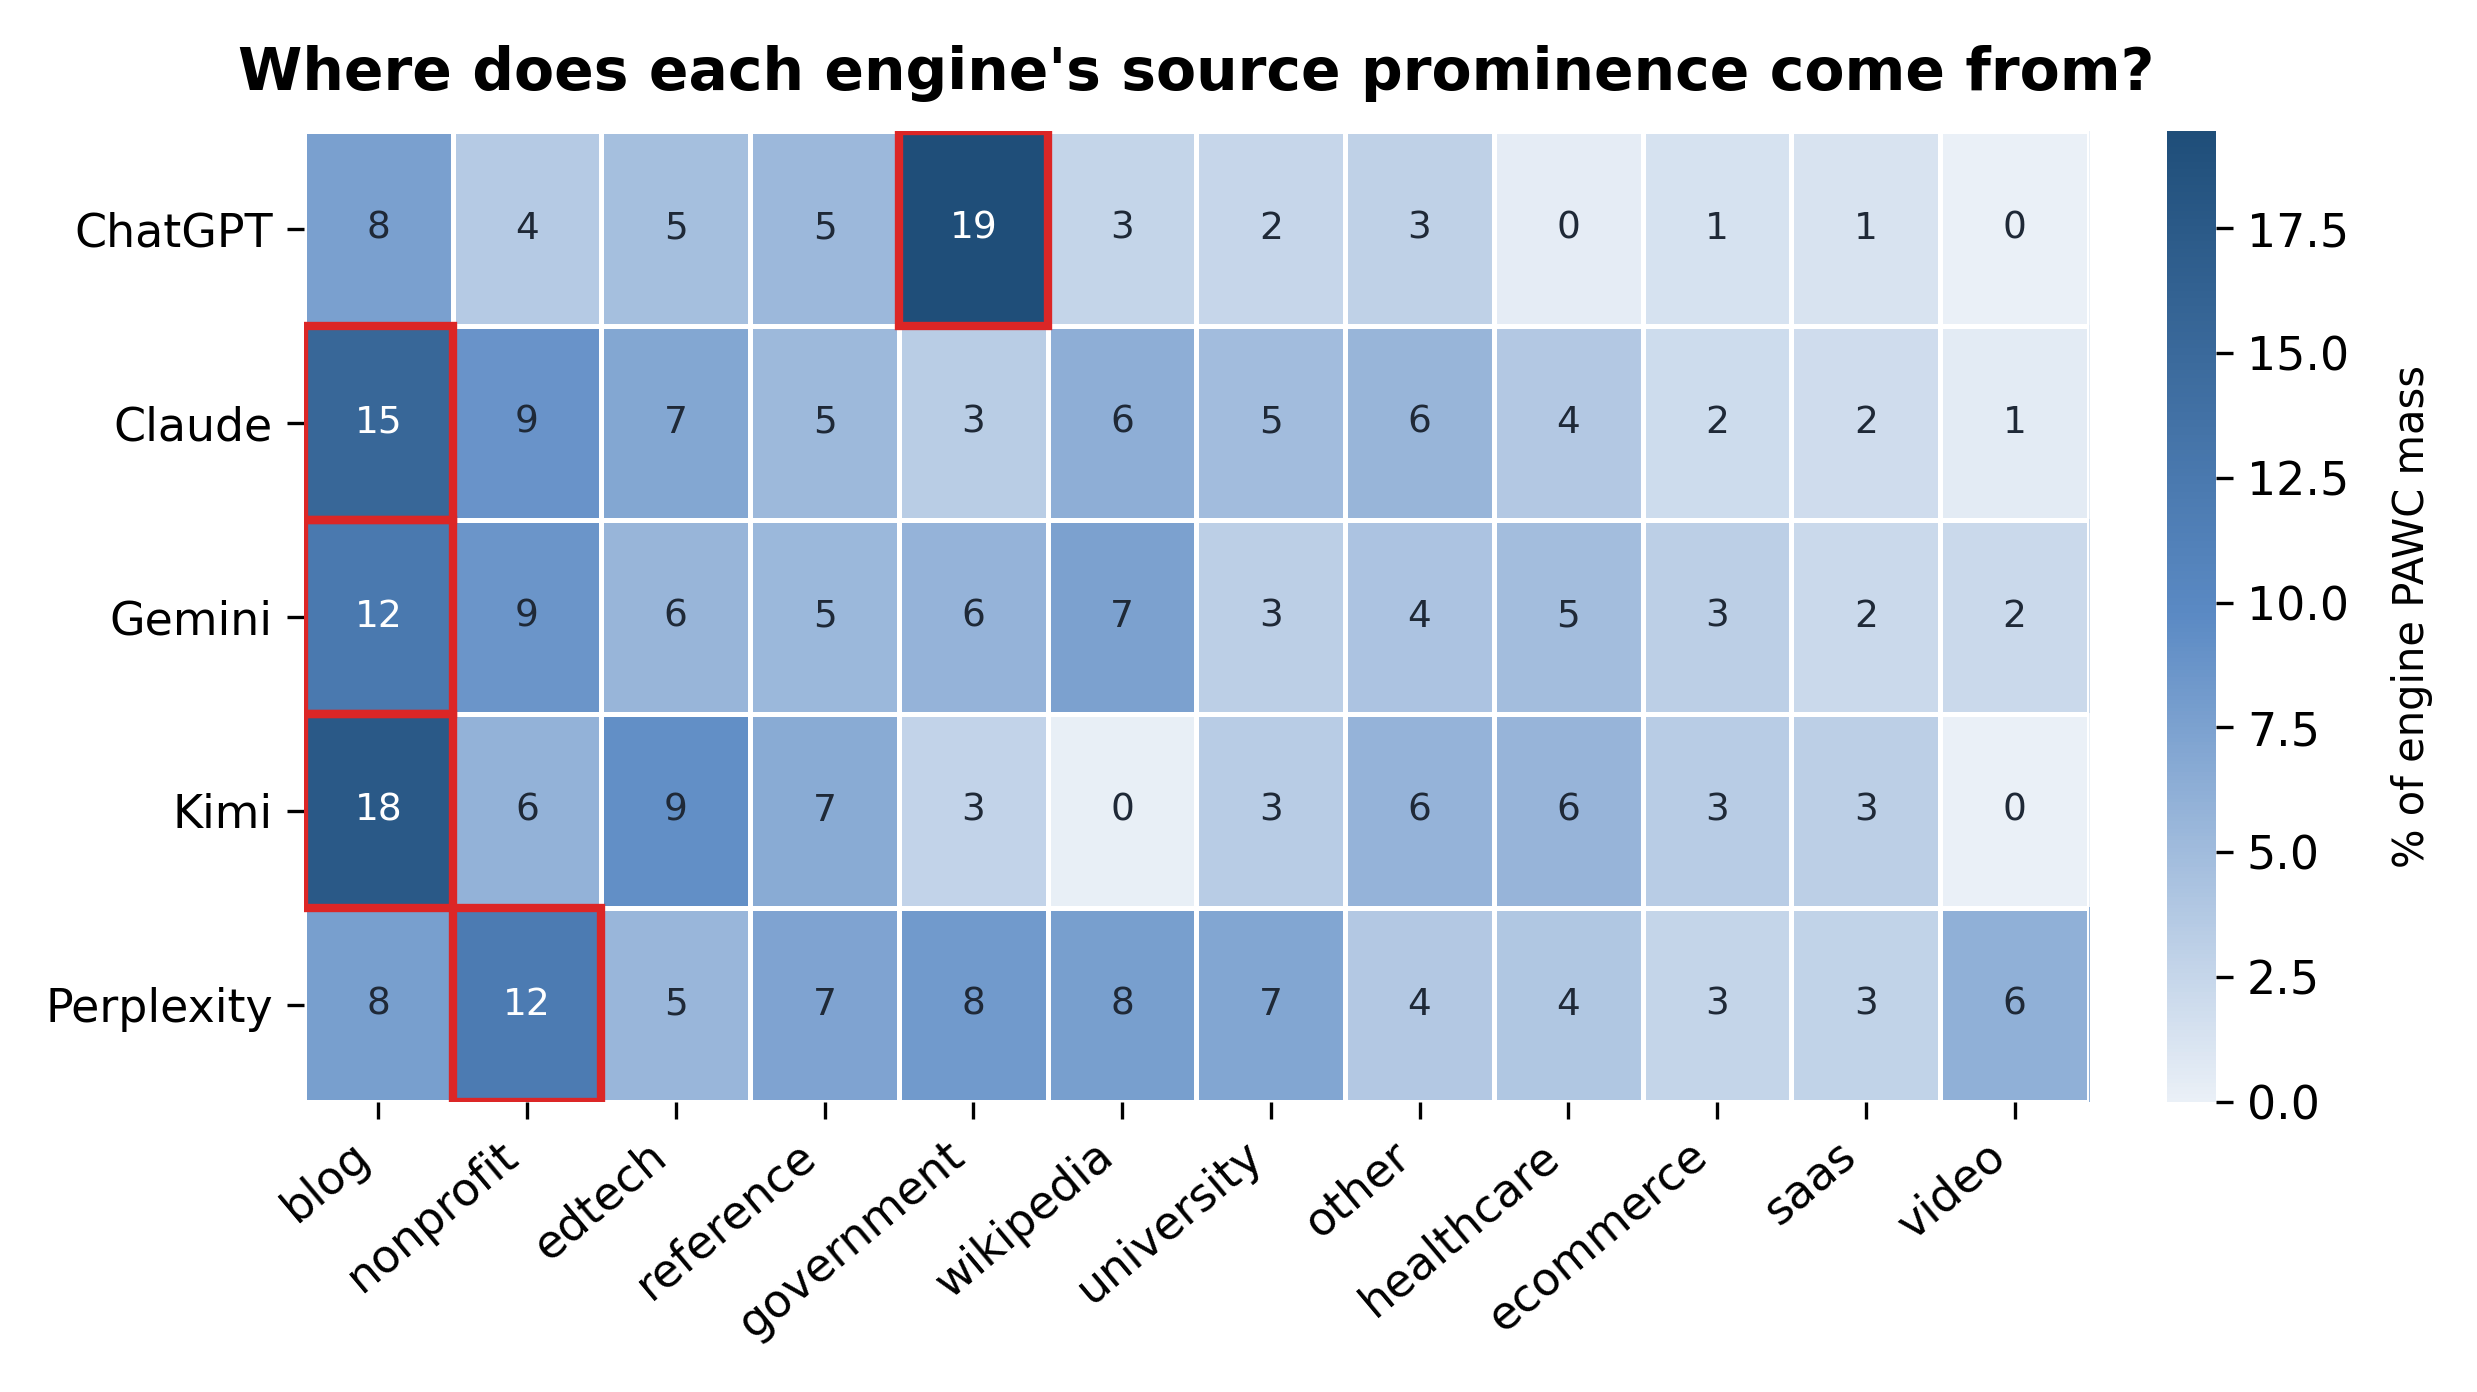

In [6]:
# D4 · Share of each engine's PAWC_norm mass by source domain_type (top-12 contributors). Top contributor ringed.
mass  = PAWC_POS.groupby(["engine","domain_type"]).contrib.sum().unstack(fill_value=0)
share = mass.div(mass.sum(axis=1), axis=0) * 100
top   = PAWC_POS.groupby("domain_type").contrib.sum().sort_values(ascending=False).head(12).index.tolist()
S = share.reindex(ENGINE_ORDER)[top]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
draw_heatmap(ax, S.values, [ENGINE_LABELS[e] for e in ENGINE_ORDER], top,
            fmt="{:.0f}", xrot=40, cbar_label="% of engine PAWC mass")
for i, e in enumerate(ENGINE_ORDER):
    j = list(S.columns).index(S.loc[e].idxmax())
    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor=COLOUR_REFERENCE, linewidth=2))
ax.set_title("Where does each engine's source prominence come from?", pad=10)
savefig(fig, "fig_domain_rq1_d4_pawc_mass_by_domain_type")

**Key analysis (SEO/GEO).** The source-type mix behind prominence differs sharply by engine.
**ChatGPT's prominence is dominated by government (19%)** — when it does surface sources they skew official —
while **Claude (15%) and Kimi (18%) run on blogs**. **Perplexity is the most balanced and the most
institutional**: its high PAWC_norm is built on a broad base — nonprofit (12%), government (8%), Wikipedia (8%),
reference (7%) and university (7%) — rather than any single type, and **Wikipedia is essentially absent from
Kimi's prominence (0.1%)**. **Action:** match content type to engine. Official/government-style pages are the
currency on ChatGPT; institutional, encyclopedic and reference content earns prominence on Perplexity; strong
editorial blog content is what Claude and Kimi reward. One asset rarely wins everywhere.

## RQ2 — Reproducibility × domain taxonomy

How run-to-run stability (CV across the k = 8 repeats) depends on **what a query is about** (D5–D6) and whether
an engine keeps citing the **same kinds of sources** (D7–D8). CV uses the cleaned PAWC_norm; a cell is *unstable*
at CV ≥ 0.50 and *undefined* when the engine returns no usable signal (PAWC_norm mean 0/NaN), matching the RQ2
notebook (ChatGPT 74% undefined; Perplexity 1% undefined but 55% unstable; Claude steadiest).

### RQ2 · D5 — Is source-prominence stability worse for volatile query topics?

PAWC_norm CV per query topic (Panel A, well-powered topics) and per query temporality (Panel B), pooled across
engines over defined cells. The red 0.50 line marks the *unstable* threshold; lower = more reproducible.

saved fig_domain_rq2_d5_cv_by_topic_temporality


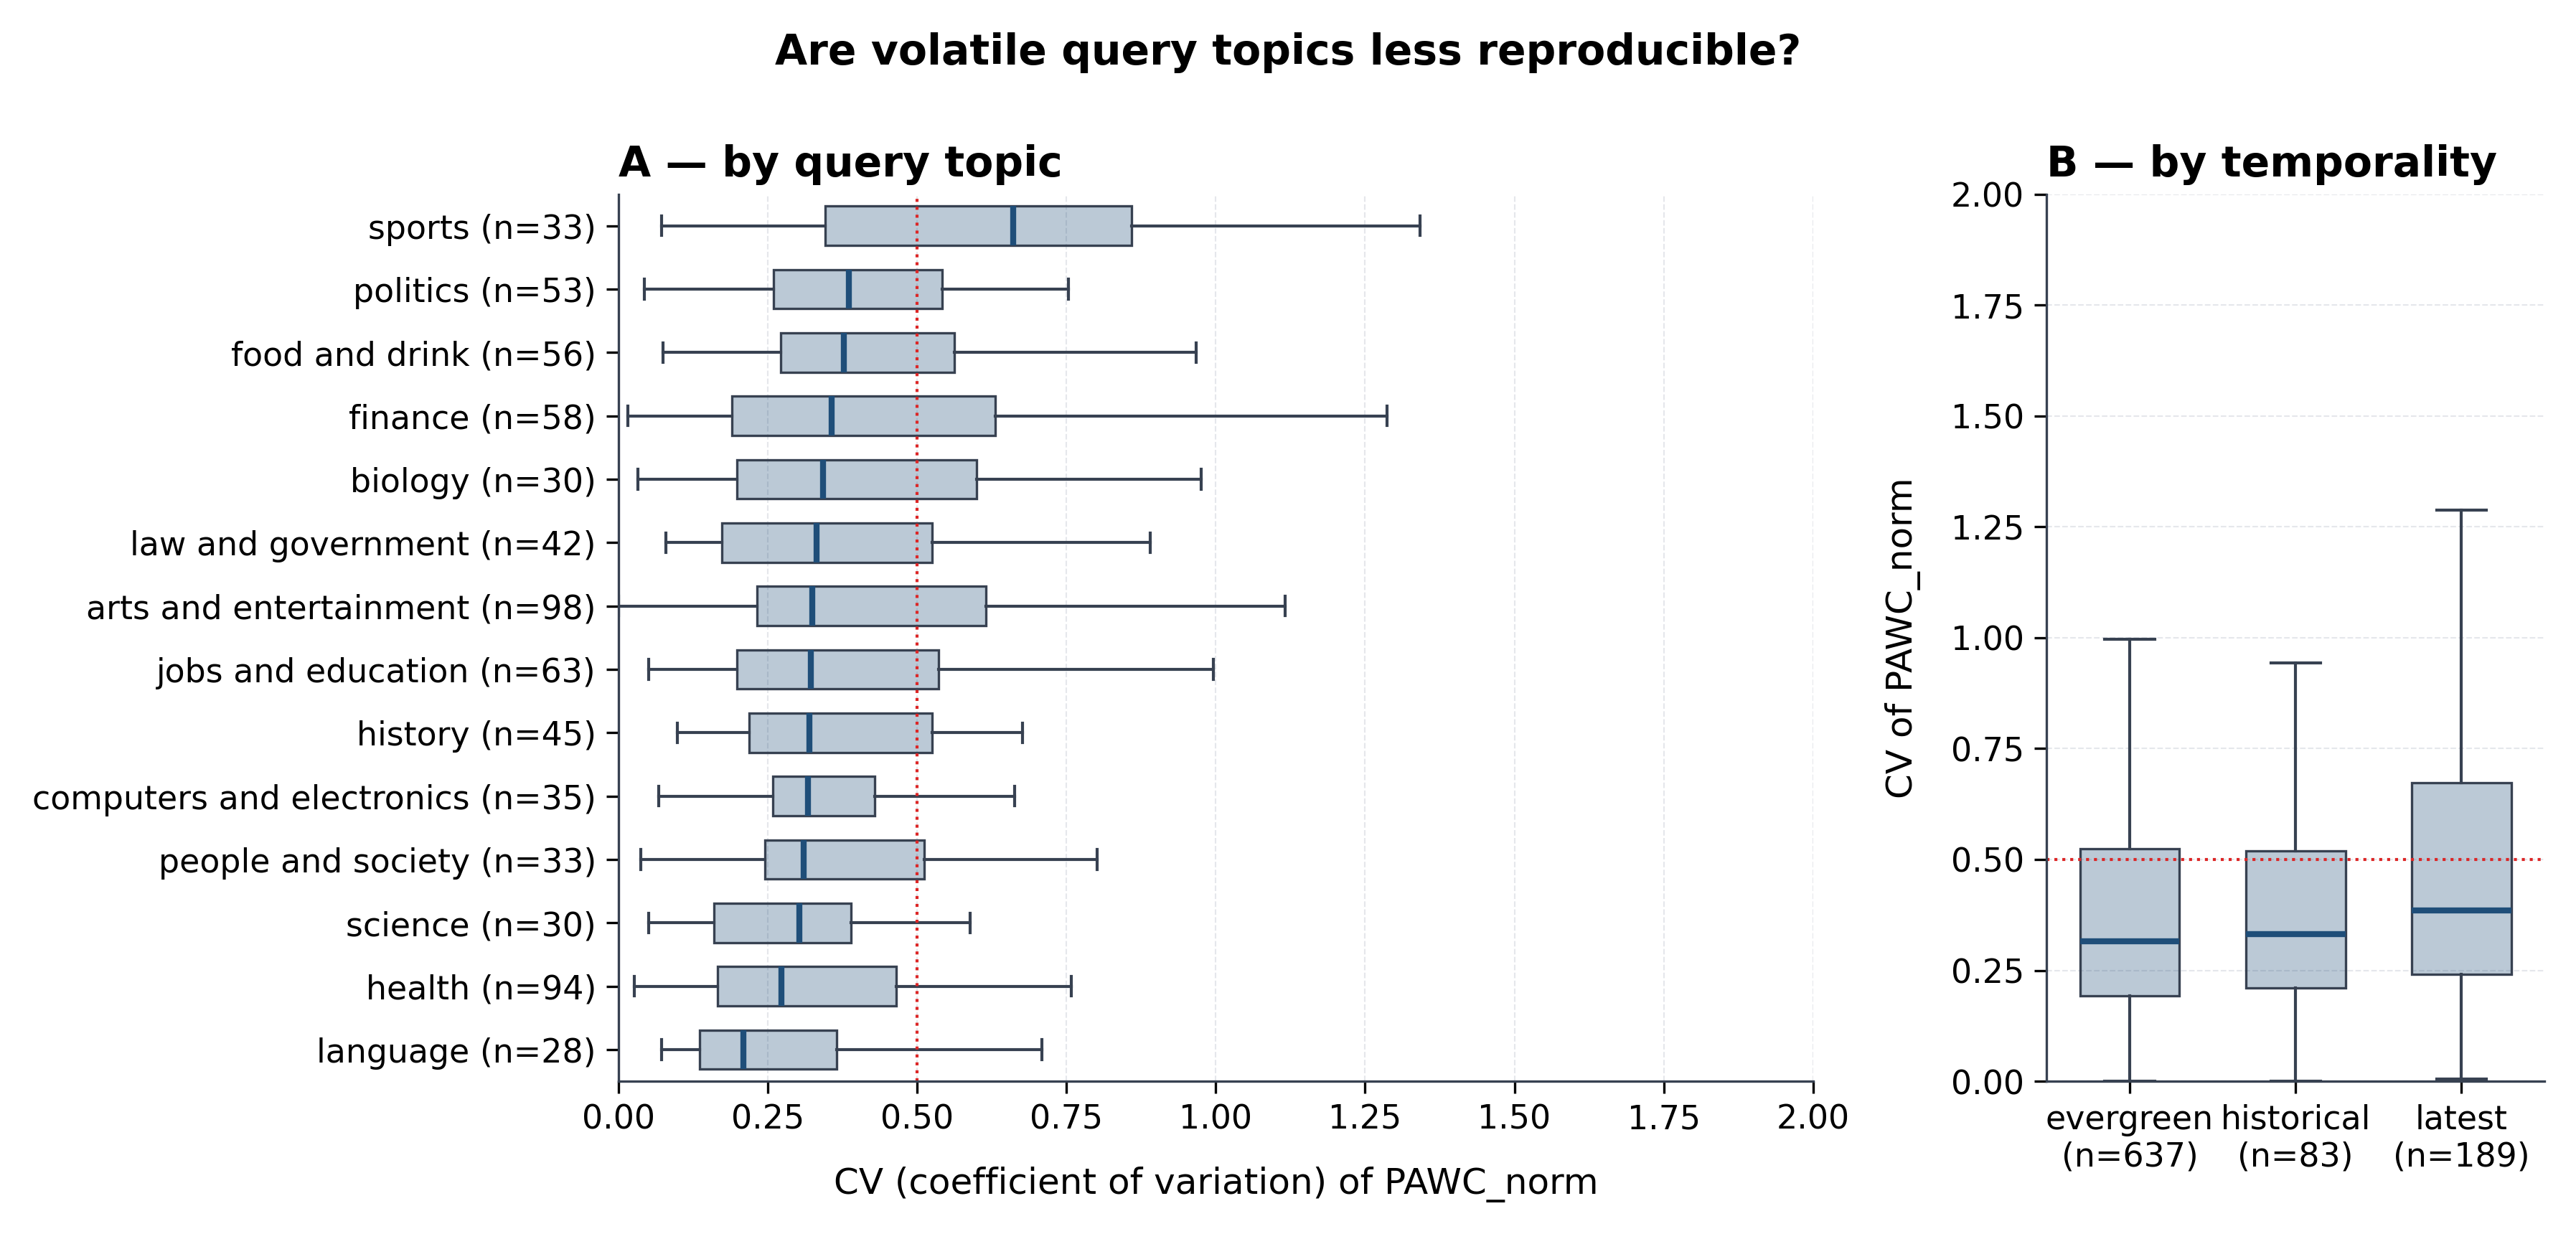

In [7]:
# D5 · PAWC_norm CV by query topic (A) and by temporality (B). Pooled across engines, defined cells. 0.50 = unstable.
cv = CV[CV.pawc_norm_cv.notna()]
order = (cv[cv.query_domain.isin(WELL_POWERED)].groupby("query_domain").pawc_norm_cv.median()
         .sort_values().index.tolist())
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5.6), gridspec_kw={"width_ratios":[2.4, 1]})
# Panel A — topic domains (horizontal, ordered by median)
dataA = [cv[cv.query_domain==d].pawc_norm_cv.values for d in order]
bpA = axA.boxplot(dataA, vert=False, widths=0.62, patch_artist=True, showfliers=False)
for b in bpA["boxes"]:    b.set(facecolor=mpl.colors.to_rgba(COLOUR_PRIMARY, 0.30), edgecolor="#374151", linewidth=0.8)
for m_ in bpA["medians"]: m_.set(color=COLOUR_PRIMARY, linewidth=2)
for wk in bpA["whiskers"]+bpA["caps"]: wk.set(color="#374151", linewidth=1)
axA.set_yticks(range(1, len(order)+1)); axA.set_yticklabels([f"{d} (n={len(cv[cv.query_domain==d])})" for d in order])
axA.axvline(0.5, color=COLOUR_REFERENCE, lw=1, ls=":")
axA.set_xlabel("CV (coefficient of variation) of PAWC_norm"); axA.set_xlim(0, 2.0)
axA.set_title("A — by query topic", loc="left")
apply_style(axA); axA.yaxis.grid(False); axA.xaxis.grid(True, color="#E5E7EB", lw=0.5, ls="--")
# Panel B — temporality (vertical)
torder = ["evergreen", "historical", "latest"]
dataB = [cv[cv.temporality==t].pawc_norm_cv.values for t in torder]
bpB = axB.boxplot(dataB, vert=True, widths=0.6, patch_artist=True, showfliers=False)
for b in bpB["boxes"]:    b.set(facecolor=mpl.colors.to_rgba(COLOUR_PRIMARY, 0.30), edgecolor="#374151", linewidth=0.8)
for m_ in bpB["medians"]: m_.set(color=COLOUR_PRIMARY, linewidth=2)
for wk in bpB["whiskers"]+bpB["caps"]: wk.set(color="#374151", linewidth=1)
axB.set_xticks(range(1, 4)); axB.set_xticklabels([f"{t}\n(n={len(cv[cv.temporality==t])})" for t in torder], fontsize=10)
axB.axhline(0.5, color=COLOUR_REFERENCE, lw=1, ls=":")
axB.set_ylabel("CV of PAWC_norm"); axB.set_ylim(0, 2.0)
axB.set_title("B — by temporality", loc="left")
apply_style(axB); axB.xaxis.grid(False)
fig.suptitle("Are volatile query topics less reproducible?", y=1.0, fontweight="bold", fontsize=14)
fig.tight_layout()
savefig(fig, "fig_domain_rq2_d5_cv_by_topic_temporality")

**Key analysis (SEO/GEO).** Reproducibility is topic-dependent. **Sports is the least stable topic by far —
median PAWC_norm CV 0.66, the only topic sitting above the 0.50 unstable line** — and the wobble is broad
(Gemini, Kimi and Perplexity all run well above their own baselines on sports; only Claude stays steady).
Language, health and science are the most reproducible (median CV ≈ 0.21–0.30). Panel B shows the likely
mechanism: time-sensitive ("latest") queries are less reproducible (median 0.38) than evergreen ones (0.32),
because the live web they read changes between runs. **Action:** for sports
and breaking-news topics never trust a single run — average several and expect the visibility number to move; for
evergreen health/science content a single read is far more dependable.

### RQ2 · D6 — Do engines agree more on some query topics than others?

Mean pairwise cross-engine Spearman correlation of PAWC_norm (10 engine pairs, unconditional NaN→0) computed
within each topic that has ≥ 12 queries. Dashed red line = the all-query average. Exploratory: per-topic n is small.

saved fig_domain_rq2_d6_engine_agreement_by_topic


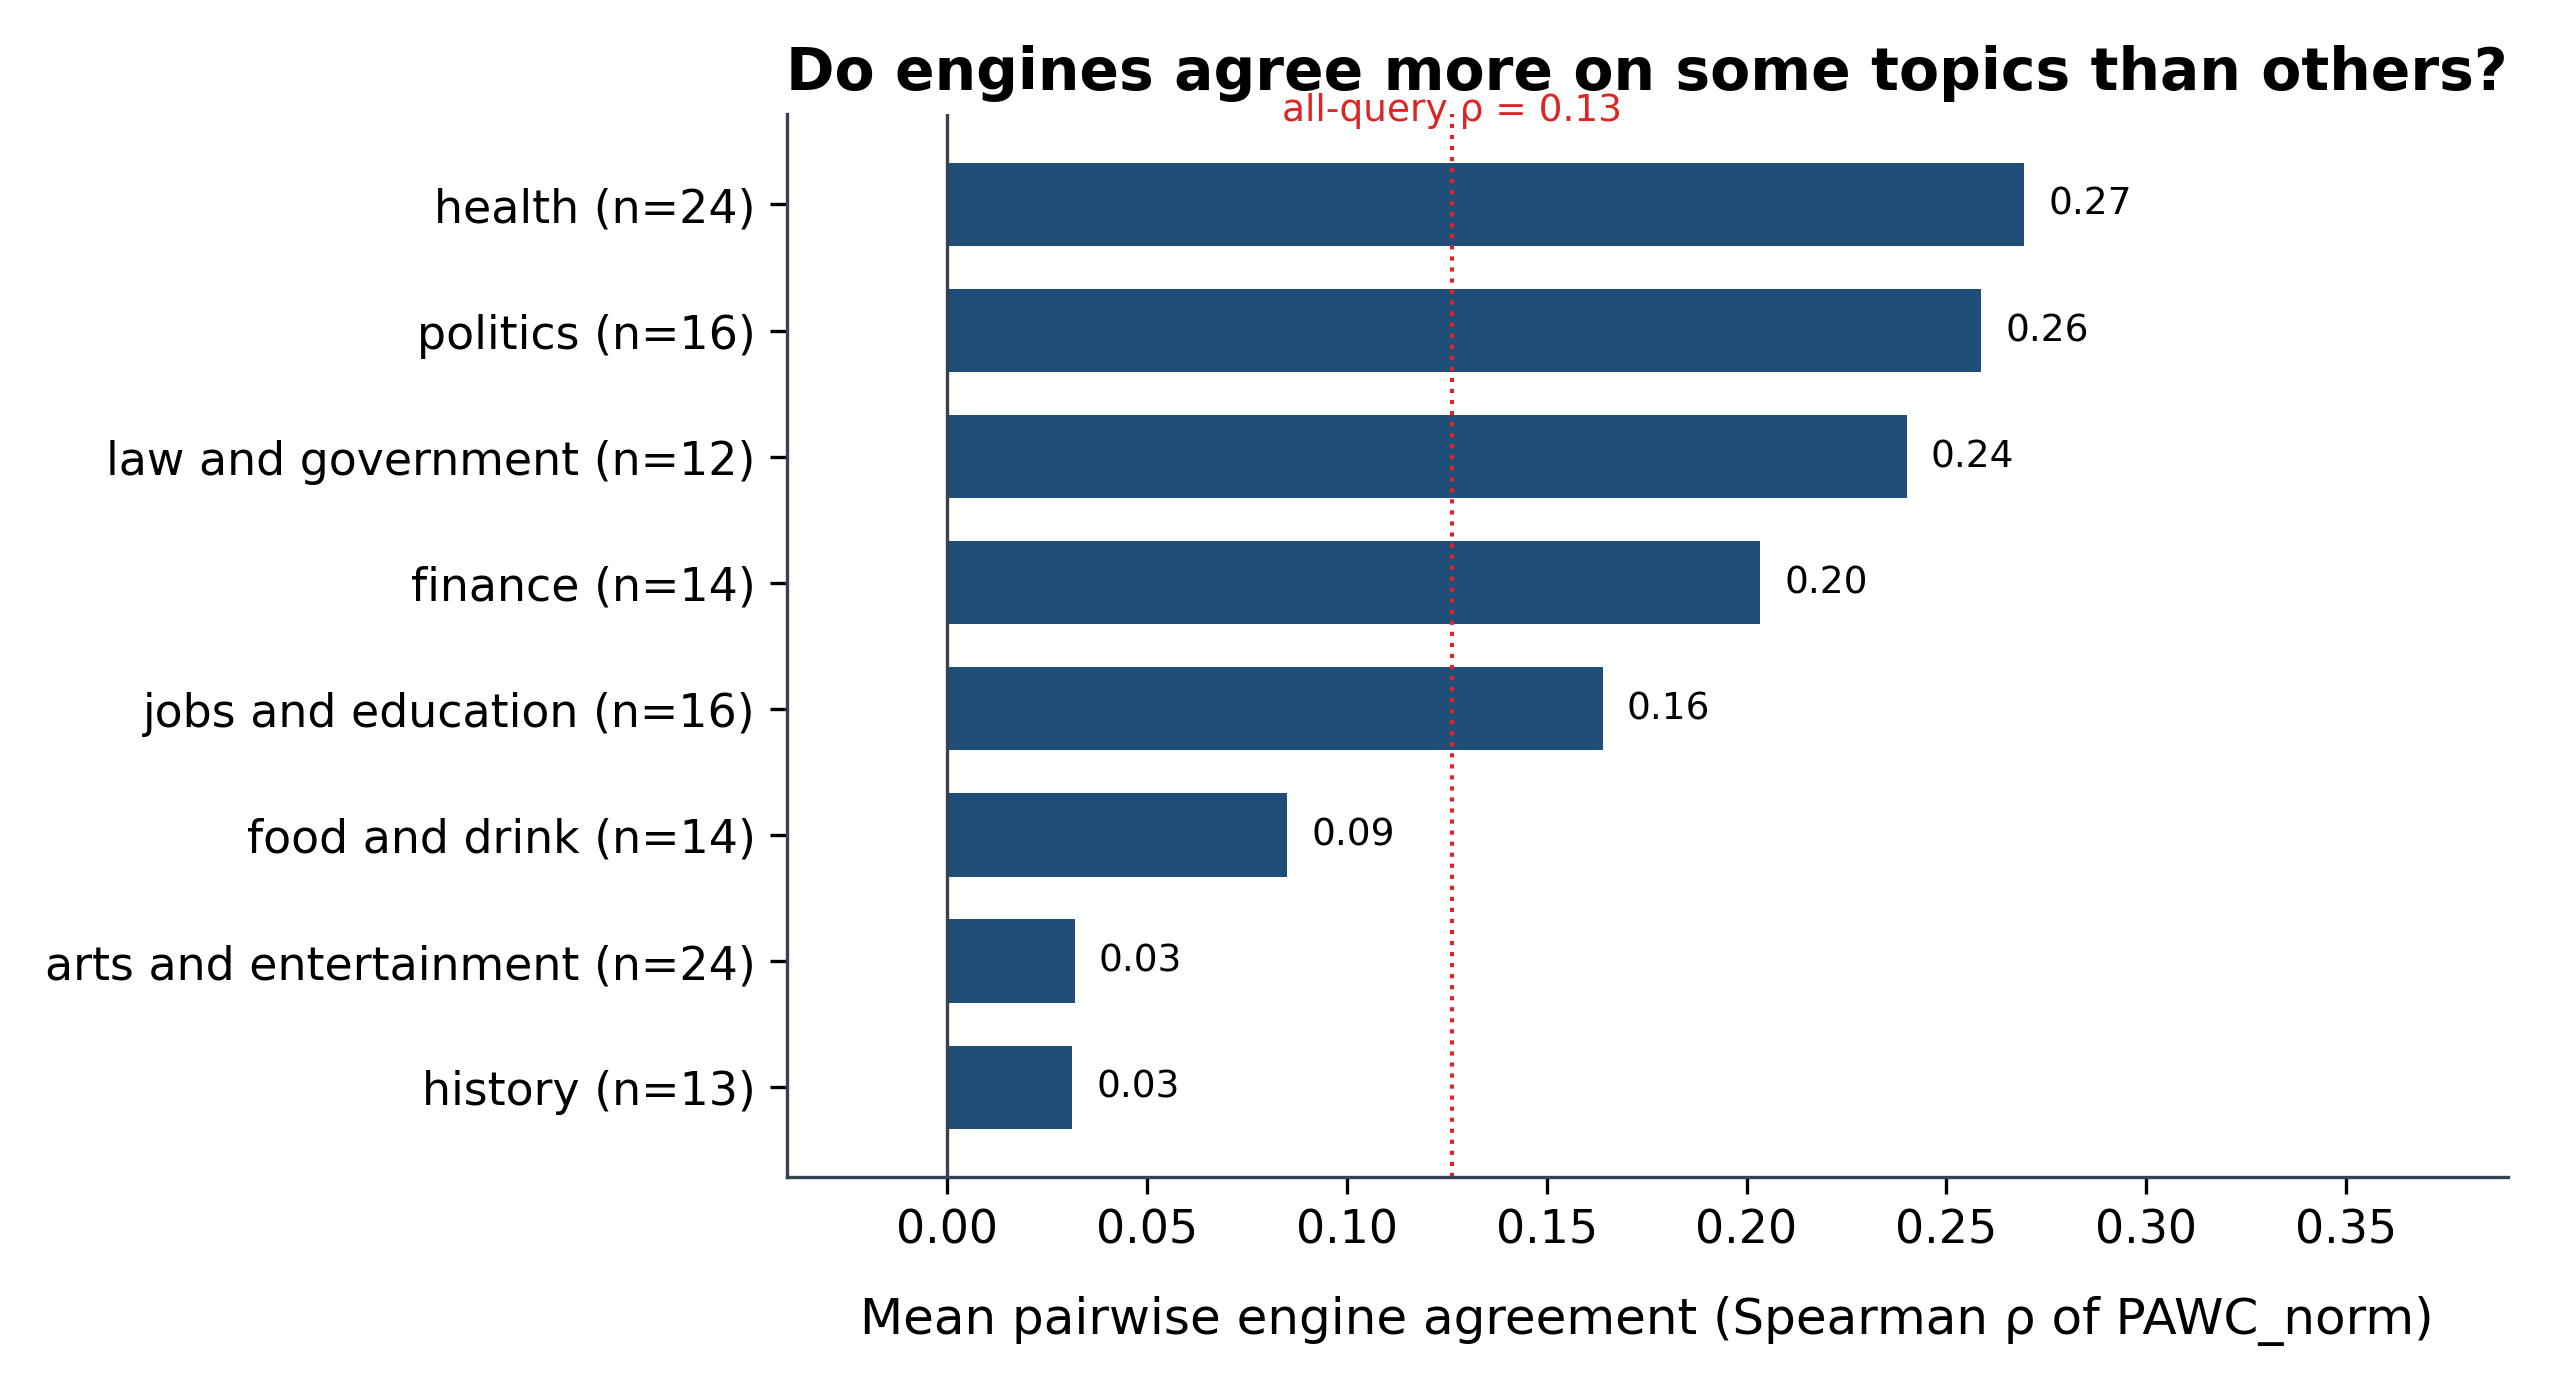

In [8]:
# D6 · Mean pairwise engine agreement (Spearman of PAWC_norm) within each topic (n>=12 queries). Unconditional.
piv = (ca.assign(p=ca.pawc_norm_mean.fillna(0)).pivot_table(index="query_id", columns="engine", values="p")
       .reindex(columns=ENGINE_ORDER).merge(QDOM, left_index=True, right_on="query_id"))
def _mpr(sub):
    rs = []
    for a, b in combinations(ENGINE_ORDER, 2):
        x, y = sub[a].values, sub[b].values
        if np.std(x) > 0 and np.std(y) > 0:
            r = spearmanr(x, y)[0]
            if not np.isnan(r): rs.append(r)
    return np.mean(rs) if rs else np.nan
doms = [d for d in WELL_POWERED if NQD[d] >= 12]
vals = pd.Series({d: _mpr(piv[piv.query_domain==d]) for d in doms}).sort_values()
overall = _mpr(piv)
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.barh(range(len(vals)), vals.values, height=0.66,
        color=[COLOUR_PRIMARY if v >= 0 else COLOUR_NEUTRAL for v in vals.values])
ax.set_yticks(range(len(vals))); ax.set_yticklabels([f"{d} (n={int(NQD[d])})" for d in vals.index])
for i, v in enumerate(vals.values):
    ax.text(v + (0.006 if v >= 0 else -0.006), i, f"{v:.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="#374151", lw=0.8)
ax.axvline(overall, color=COLOUR_REFERENCE, lw=1, ls=":")
ax.text(overall, len(vals)-0.4, f"all-query ρ = {overall:.2f}", color=COLOUR_REFERENCE, fontsize=9, ha="center", va="bottom")
ax.set_xlabel("Mean pairwise engine agreement (Spearman ρ of PAWC_norm)")
ax.set_title("Do engines agree more on some topics than others?")
ax.set_xlim(min(vals.min(), 0)*1.4 - 0.04, max(vals.max(), overall)*1.30 + 0.04); apply_style(ax); ax.grid(False)
savefig(fig, "fig_domain_rq2_d6_engine_agreement_by_topic")

**Key analysis (SEO/GEO).** The RQ2 headline — engines rank sources differently, so optimise per engine —
holds inside every topic. Agreement is weak everywhere: even the most-aligned topics, **health and politics,
reach only ρ ≈ 0.27**, and on creative/cultural topics like **arts & entertainment and history it collapses to
ρ ≈ 0.03** — there the engines rank sources almost independently. No topic comes close to the agreement you
would need to treat a win on one engine as a win on another. (Per-topic samples are only 12–24 queries, so read
the broad pattern, not the exact ordering.) **Action:** there is no "easy" vertical where one optimisation
transfers across engines — budget for per-engine testing regardless of topic.

### RQ2 · D7 — Does citing the same source types each run make prominence more stable?

Per cell, **source-type consistency** = mean pairwise Jaccard of the domain_type sets cited across the k = 8
runs (1 = identical source-type mix every run). Plotted against PAWC_norm CV, one panel per engine, with the
Spearman ρ (and significance) annotated. A negative ρ means steadier source types go with a steadier score.

saved fig_domain_rq2_d7_typeconsistency_vs_cv


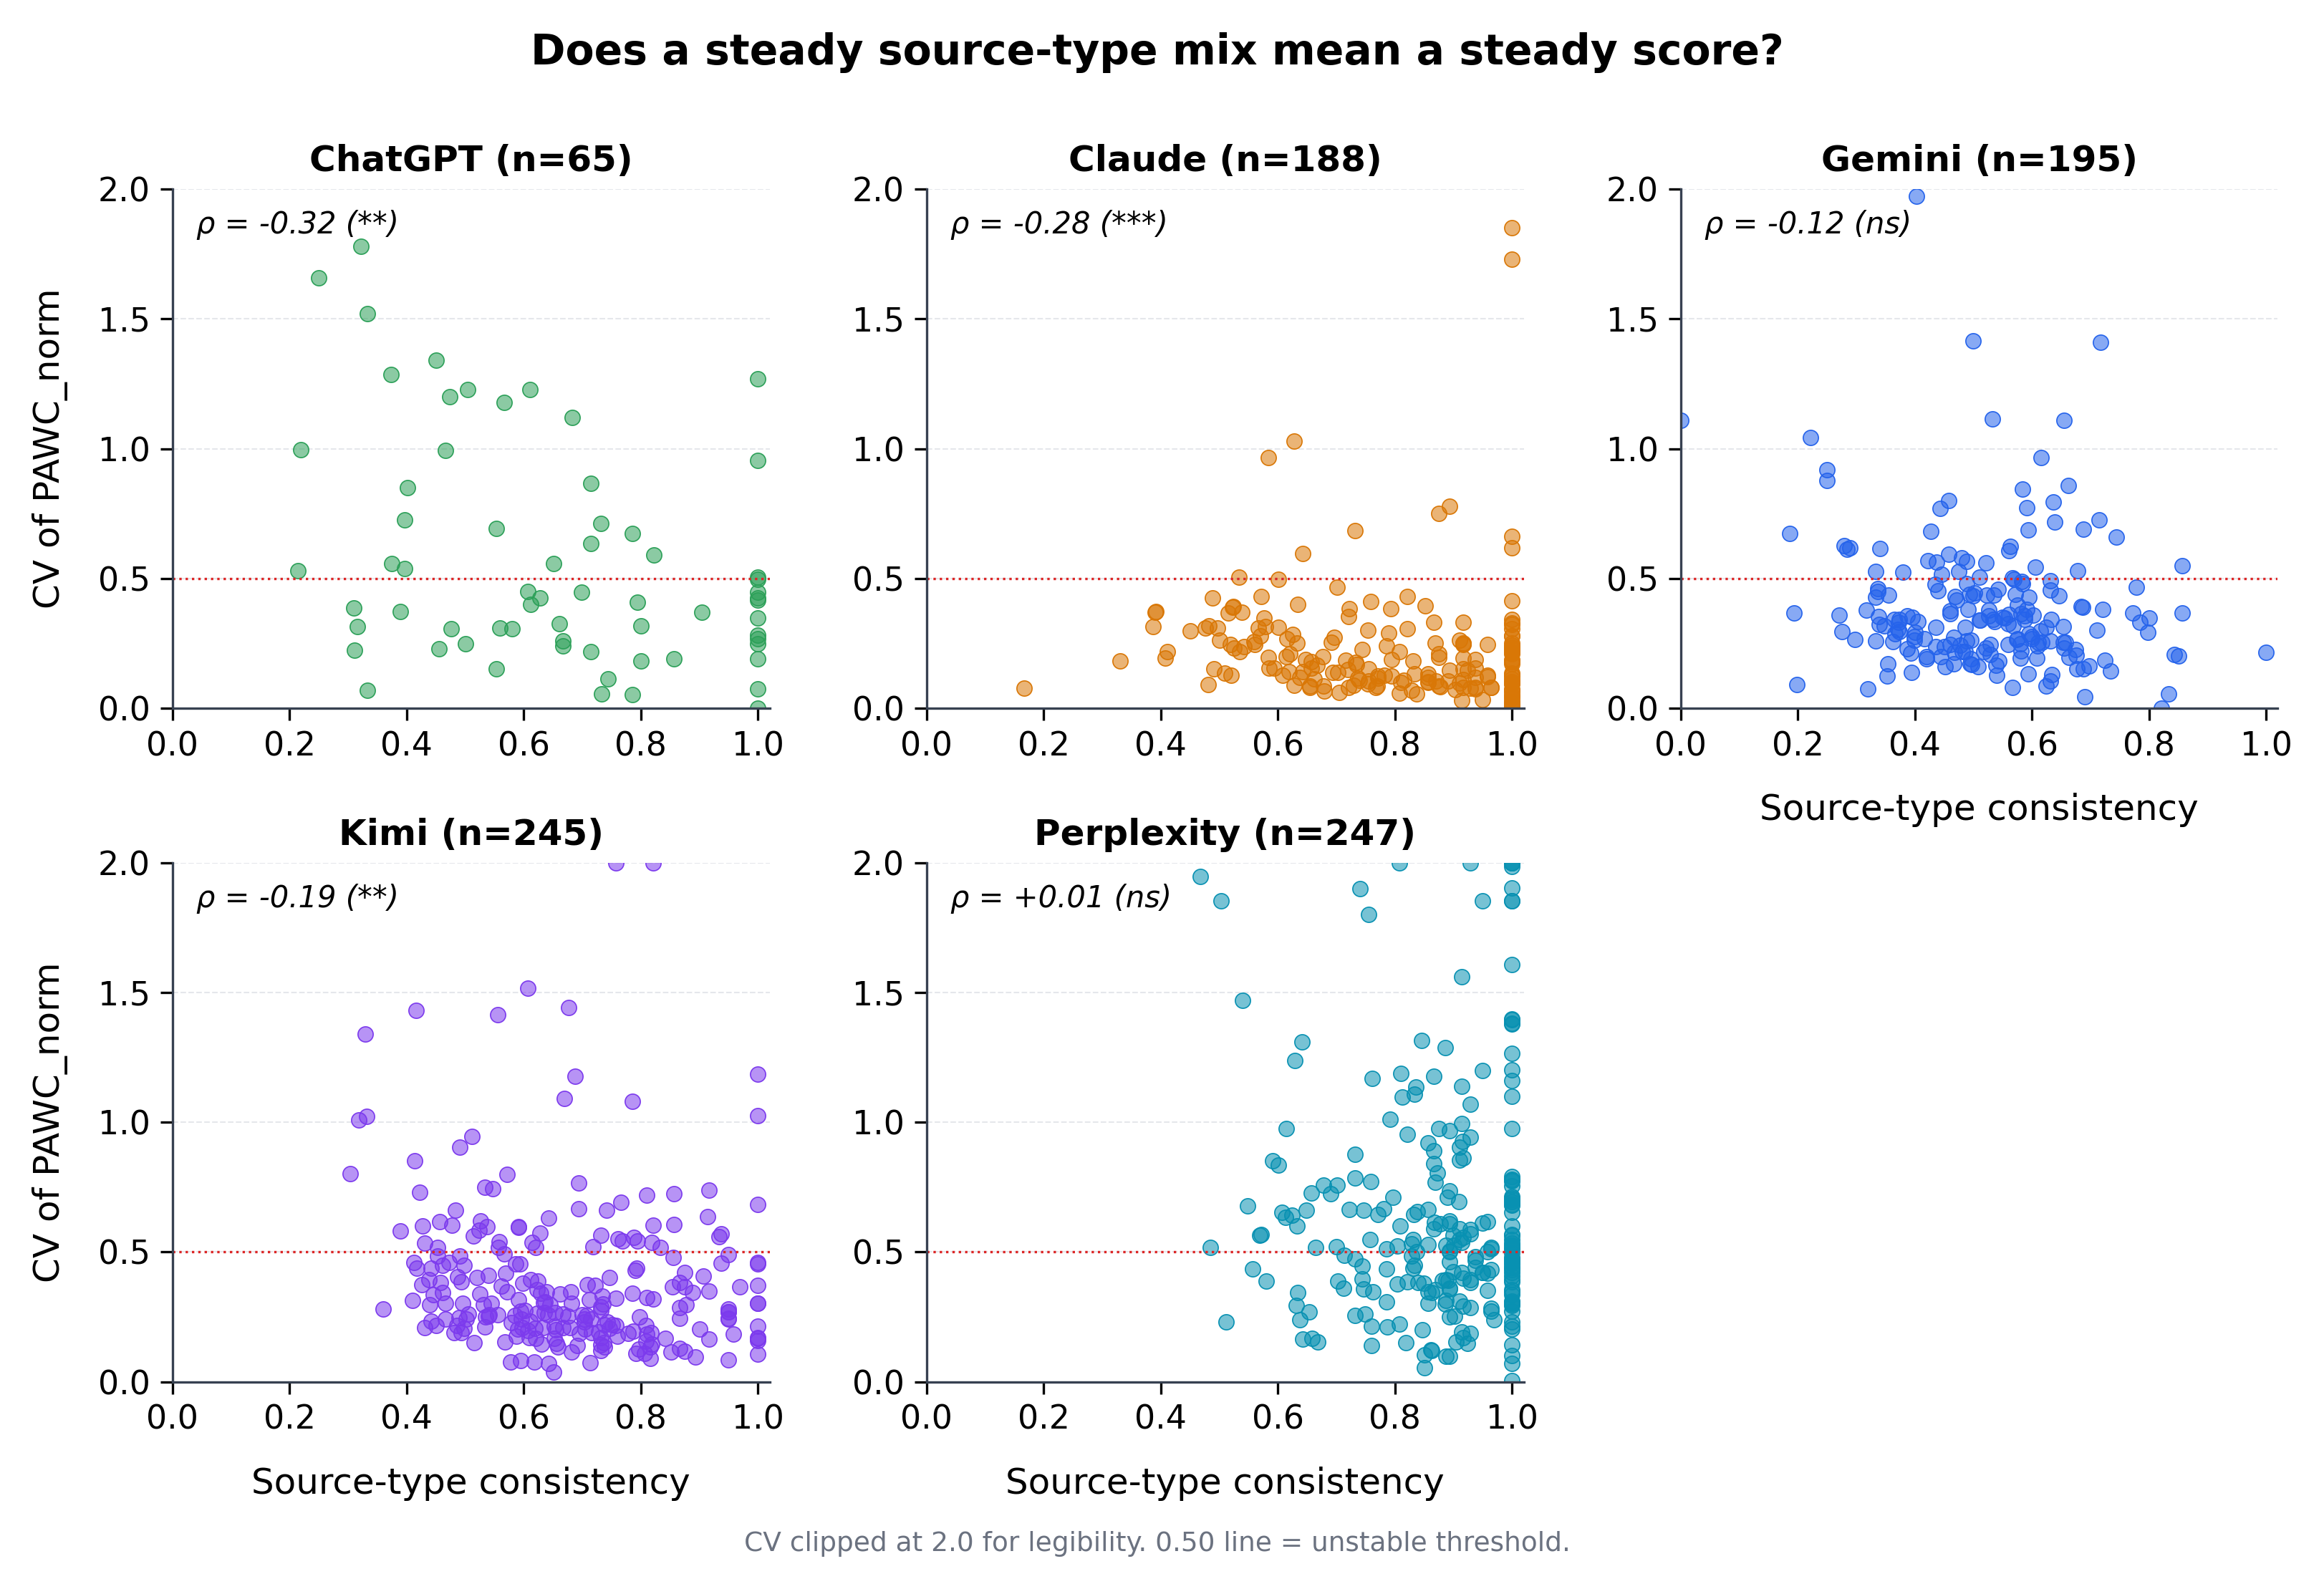

In [9]:
# D7 · Source-type consistency vs PAWC_norm CV, faceted per engine. Negative rho => steady types -> steady score.
d = CV.dropna(subset=["pawc_norm_cv","typ_consistency"])
def _stars(p): return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, e in zip(axes.ravel(), ENGINE_ORDER):
    de = d[d.engine==e]
    ax.scatter(de.typ_consistency, np.clip(de.pawc_norm_cv, 0, 2.0), s=26,
               color=mpl.colors.to_rgba(ENGINE_COLOURS[e], 0.55), edgecolor=ENGINE_COLOURS[e], linewidth=0.4)
    r, p = spearmanr(de.typ_consistency, de.pawc_norm_cv)
    ax.axhline(0.5, color=COLOUR_REFERENCE, lw=0.8, ls=":")
    ax.set_title(f"{ENGINE_LABELS[e]} (n={len(de)})", fontsize=12)
    ax.text(0.04, 0.96, f"ρ = {r:+.2f} ({_stars(p)})", transform=ax.transAxes, fontsize=10, style="italic", va="top")
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 2.0); apply_style(ax)
axes[1, 2].axis("off")
for ax in (axes[0, 0], axes[1, 0]): ax.set_ylabel("CV of PAWC_norm")
for ax in (axes[1, 0], axes[1, 1], axes[0, 2]): ax.set_xlabel("Source-type consistency")
fig.suptitle("Does a steady source-type mix mean a steady score?", y=1.0, fontweight="bold", fontsize=14)
fig.text(0.5, -0.01, "CV clipped at 2.0 for legibility. 0.50 line = unstable threshold.", ha="center",
         fontsize=9, color=COLOUR_NEUTRAL)
fig.tight_layout()
savefig(fig, "fig_domain_rq2_d7_typeconsistency_vs_cv")

**Key analysis (SEO/GEO).** For most engines, **keeping a consistent source-type mix across runs does go
with a steadier visibility score**: the correlation is negative and significant for Claude (ρ = −0.28, ***),
ChatGPT (−0.32, **) and Kimi (−0.19, **) — when these engines drift across different *kinds* of sources from run
to run, the prominence number swings. **Perplexity is the striking exception (ρ = +0.01, ns)** — its source-type
mix barely moves yet the score still wobbles (unpacked in D8). **Action:** if you can get Claude, ChatGPT or Kimi
to consistently pull the same class of source for your query, the visibility reading becomes more trustworthy; on
Perplexity, source-type stability will not buy you a stable number.

### RQ2 · D8 — Is Perplexity's instability caused by switching source types?

Source-type consistency for Perplexity's **stable (CV < 0.50)** vs **unstable (CV ≥ 0.50)** cells. If instability
came from picking different source types, unstable cells would show markedly lower consistency. Box + jittered cells.

saved fig_domain_rq2_d8_perplexity_typeconsistency


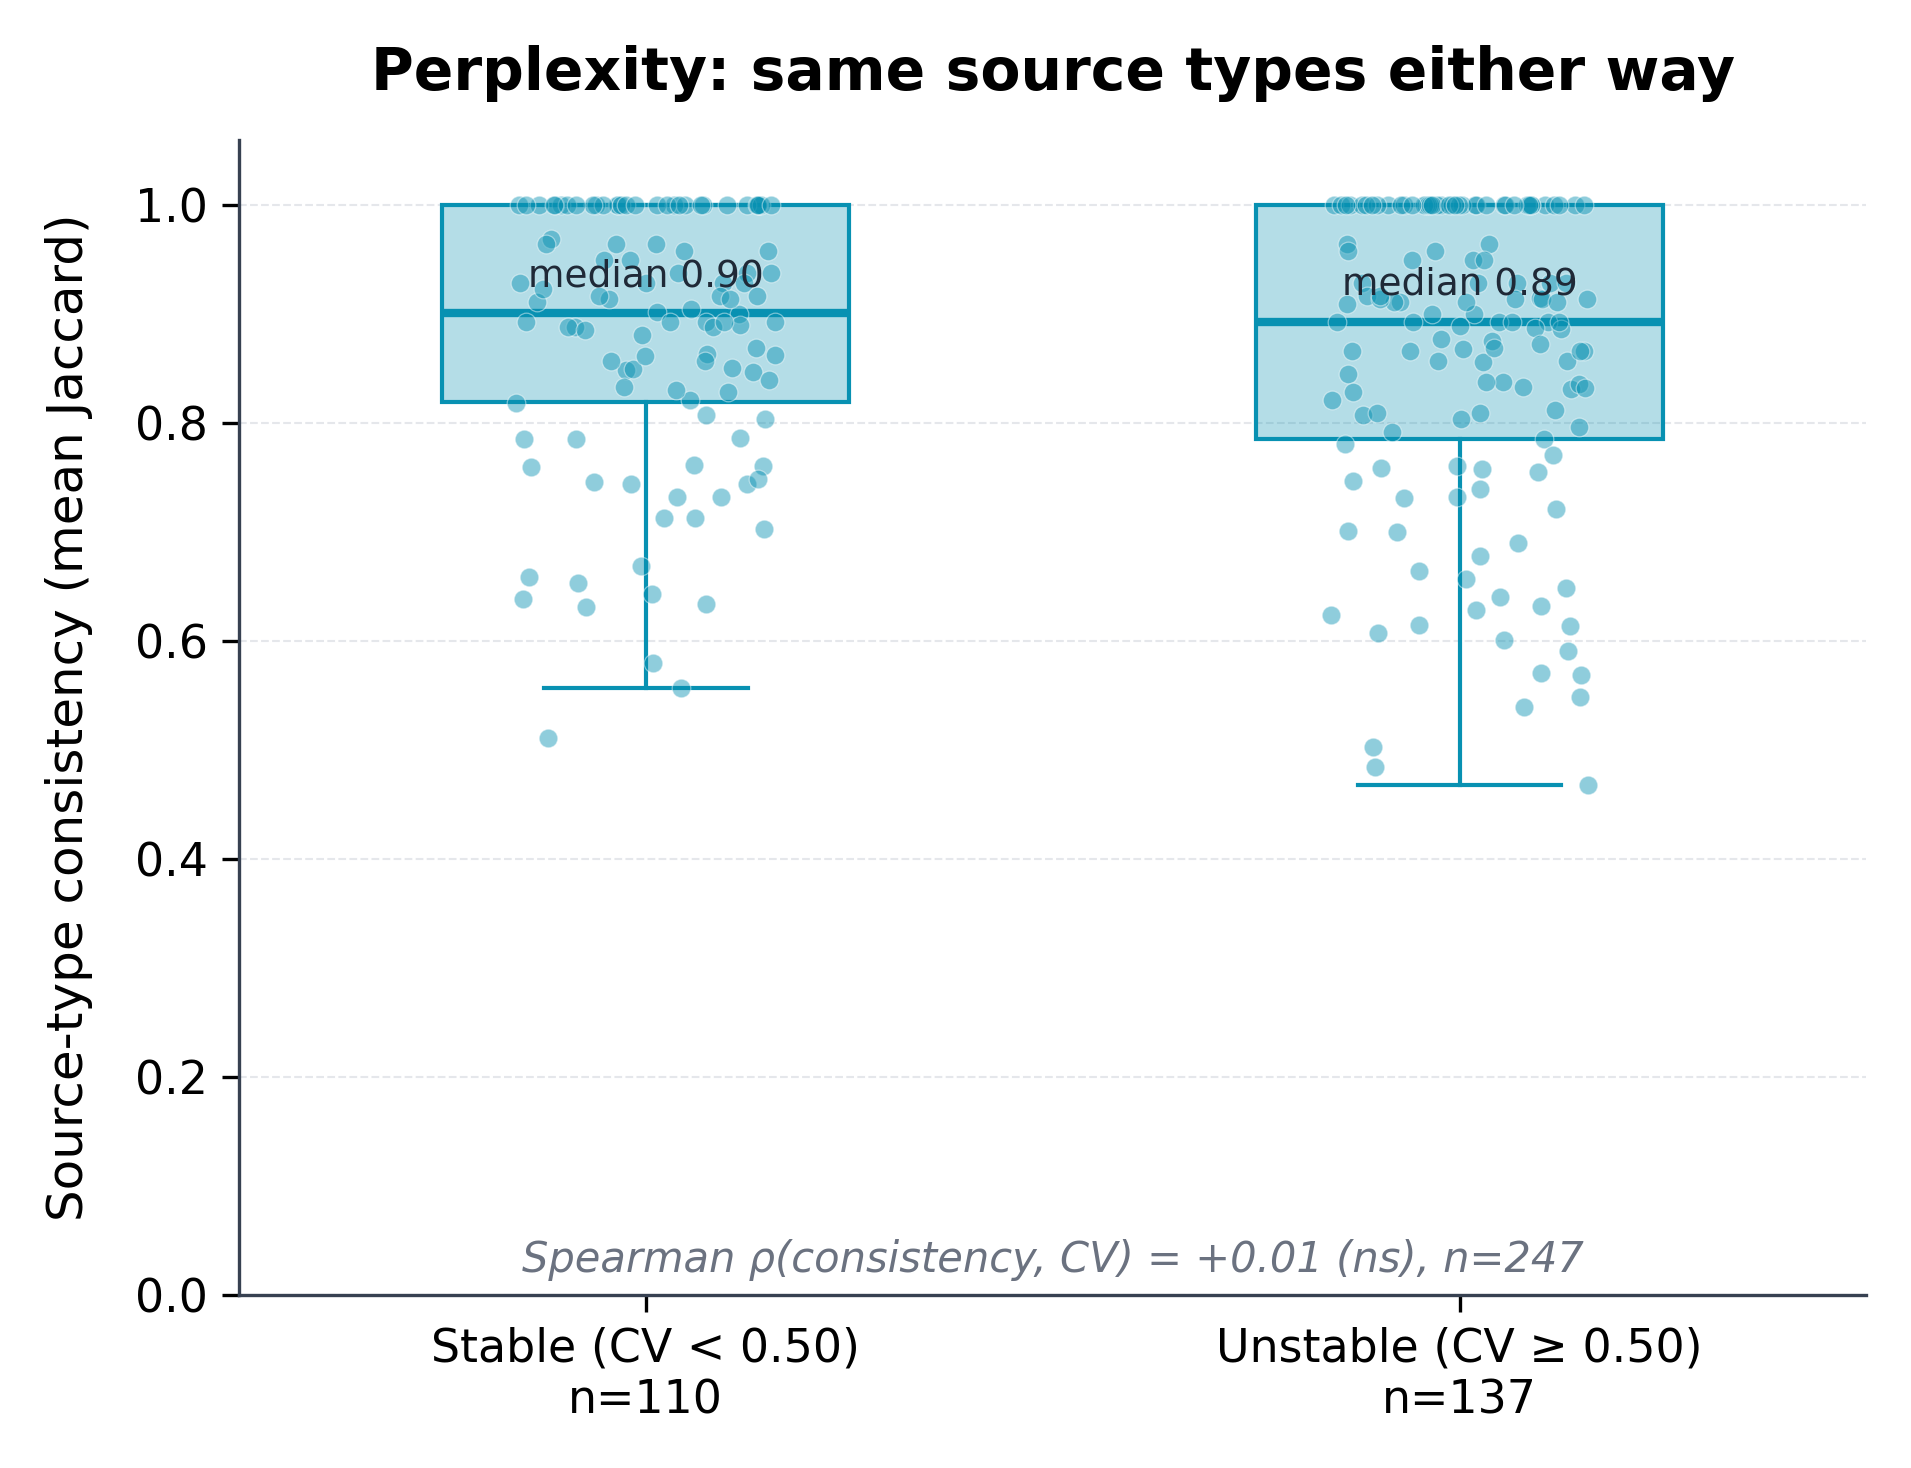

In [10]:
# D8 · Perplexity: source-type consistency for stable vs unstable cells. Tests whether type-switching drives CV.
pe = CV[CV.engine=="perplexity"].dropna(subset=["pawc_norm_cv","typ_consistency"]).copy()
groups = ["Stable (CV < 0.50)", "Unstable (CV ≥ 0.50)"]
pe["band"] = np.where(pe.pawc_norm_cv < 0.5, groups[0], groups[1])
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7, 5))
for j, gname in enumerate(groups):
    v = pe[pe.band==gname].typ_consistency.values
    bp = ax.boxplot(v, positions=[j], widths=0.5, patch_artist=True, showfliers=False)
    bp["boxes"][0].set(facecolor=mpl.colors.to_rgba(ENGINE_COLOURS["perplexity"], 0.30),
                       edgecolor=ENGINE_COLOURS["perplexity"], linewidth=1)
    for m_ in bp["medians"]: m_.set(color=ENGINE_COLOURS["perplexity"], linewidth=2)
    for wk in bp["whiskers"]+bp["caps"]: wk.set(color=ENGINE_COLOURS["perplexity"], linewidth=1)
    ax.scatter(j + rng.uniform(-0.16, 0.16, len(v)), v, s=20, color=ENGINE_COLOURS["perplexity"],
               alpha=0.45, edgecolor="white", linewidth=0.3, zorder=3)
    ax.text(j, np.median(v)+0.025, f"median {np.median(v):.2f}", ha="center", fontsize=9, color="#1F2937")
ax.set_xticks(range(2)); ax.set_xticklabels([f"{g}\nn={len(pe[pe.band==g])}" for g in groups])
r, p = spearmanr(pe.typ_consistency, pe.pawc_norm_cv)
ax.text(0.5, 0.02, f"Spearman ρ(consistency, CV) = {r:+.2f} ({'ns' if p >= 0.05 else 'sig'}), n={len(pe)}",
        transform=ax.transAxes, ha="center", fontsize=10, style="italic", color=COLOUR_NEUTRAL)
ax.set_ylabel("Source-type consistency (mean Jaccard)")
ax.set_title("Perplexity: same source types either way", pad=12)
ax.set_ylim(0, 1.06); apply_style(ax)
savefig(fig, "fig_domain_rq2_d8_perplexity_typeconsistency")

**Key analysis (SEO/GEO).** The answer is no. Perplexity's stable and unstable cells have **almost
identical source-type consistency (median 0.90 vs 0.89)**, and across all its cells consistency is unrelated to
CV (ρ = +0.01, ns). In plain terms: Perplexity reliably reaches for the *same kinds of sources* every run,
whether the resulting score is stable or not — so its prominence wobble is **not** caused by switching source
types. The variance lives one level down: which specific URLs surface, and in what order. **Action:** you cannot
stabilise a Perplexity reading by influencing the *type* of source it cites; the only reliable fix is averaging
more runs, consistent with RQ2's k = 8 guidance.

## RQ3 — Citation accuracy × domain taxonomy

How faithfully engines represent sources, broken down by the **type of source** cited (D9–D11) and the **query
topic** (D12). Faithfulness is the per-(sentence, source) NLI entailment score, banded as in the RQ3 notebook:
contradiction (< 0.30), borderline (0.30–0.50), clearly supported (≥ 0.50). AIS is the cleaned per-engine rate
(Perplexity 0.79, Kimi 0.78 lead; ChatGPT 0.12; Gemini cites ≈ 7 sources yet reaches only 0.51).

### RQ3 · D9 — Which source types are cited faithfully?

Entailment-band composition for the 15 most-cited source types, ordered by the share of citations that are
**clearly supported** (≥ 0.50). Bands follow RQ3: contradiction (brown), borderline (grey), clearly supported (teal).

saved fig_domain_rq3_d9_entailment_by_source_type


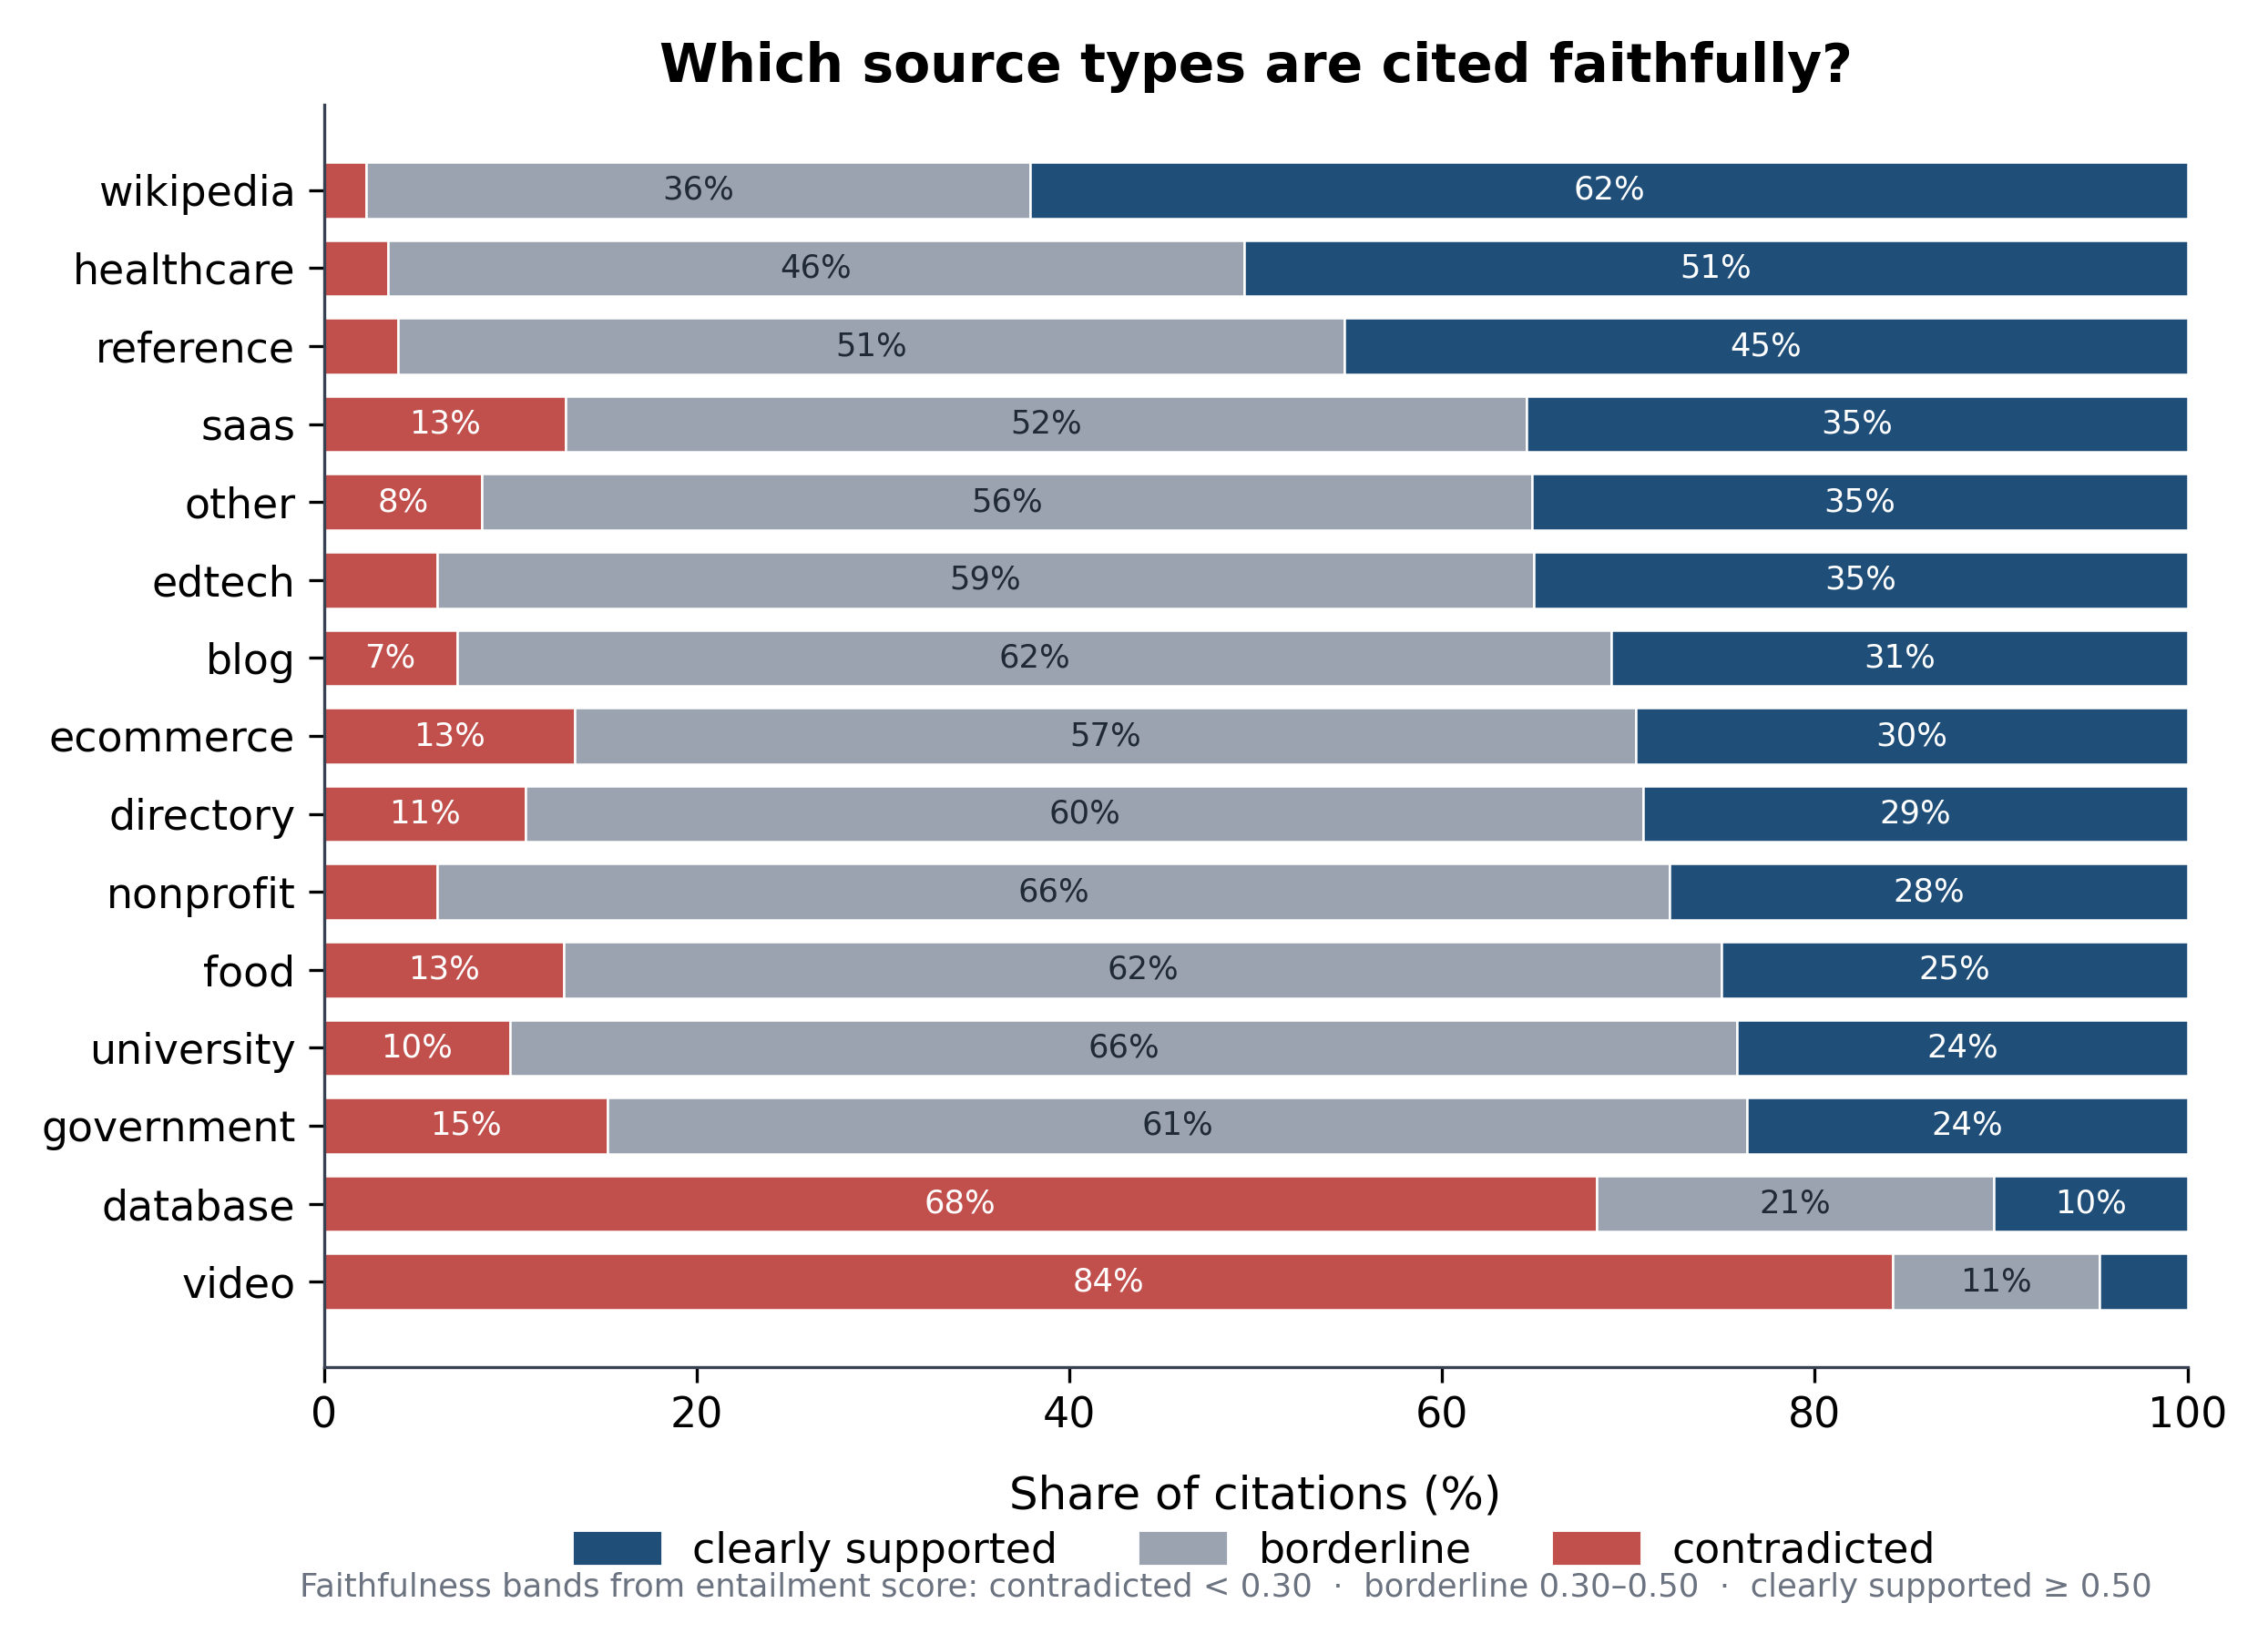

In [11]:
# D9 · Entailment-band composition by source domain_type (top-15 most cited), ordered by % clearly supported.
topcited = cit.domain_type.value_counts().head(15).index.tolist()
B = ENTAIL_BY_TYPE.loc[topcited, ["pct_contra","pct_border","pct_entail"]].sort_values("pct_entail")
BANDS = [("pct_contra", "contradicted",      "#C1504D", "white"),
         ("pct_border", "borderline",        "#9AA3AF", "#1F2937"),
         ("pct_entail", "clearly supported", "#1F4E79", "white")]
fig, ax = plt.subplots(figsize=(8.8, 6.0))
left = np.zeros(len(B)); yy = list(range(len(B)))
for col, lab, c, tc in BANDS:
    w = B[col].values
    ax.barh(yy, w, left=left, height=0.72, color=c, edgecolor="white", linewidth=0.6)
    for i in range(len(B)):
        if w[i] >= 7: ax.text(left[i]+w[i]/2, i, f"{w[i]:.0f}%", ha="center", va="center", color=tc, fontsize=8.5)
    left += w
ax.set_yticks(yy); ax.set_yticklabels(list(B.index))
ax.set_xlabel("Share of citations (%)"); ax.set_xlim(0, 100)
ax.set_title("Which source types are cited faithfully?")
_leg = [("clearly supported", "#1F4E79"), ("borderline", "#9AA3AF"), ("contradicted", "#C1504D")]
ax.legend(handles=[Patch(color=c, label=l) for l, c in _leg], loc="upper center",
          bbox_to_anchor=(0.5, -0.10), ncol=3)
apply_style(ax); ax.grid(False)
fig.text(0.5, -0.03, "Faithfulness bands from entailment score: contradicted < 0.30  ·  borderline 0.30–0.50  ·  clearly supported ≥ 0.50",
         ha="center", fontsize=8.5, color=COLOUR_NEUTRAL)
savefig(fig, "fig_domain_rq3_d9_entailment_by_source_type")

**Key analysis (SEO/GEO).** Faithfulness varies enormously by source type. **Wikipedia is the gold
standard — 62% of its citations are clearly supported** — followed by healthcare (51%) and reference (45%). At the
other extreme, **video (5% supported, 84% contradicted) and database (10%, 68% contradicted) are cited for claims
their content does not back at all**. Critically, the high-volume workhorses — government, university, nonprofit,
blog — sit in the "mostly borderline" middle (24–31% clearly supported, 61–66% borderline): when an engine cites
them the claim is usually plausible-but-unconfirmed, not clearly right. (Database/video scores are partly an
extraction effect — tables and transcripts are hard for the NLI judge to verify.) **Action:** an encyclopedic or
authoritative-reference footprint is what gets your content cited *faithfully*; if your value lives in databases or
video, expect engines to cite it for claims it does not cleanly support.

### RQ3 · D10 — Does Gemini's source mix explain its accuracy anomaly?

Share of each engine's citations drawn from **low-faithfulness source types** (those with mean entailment < 0.42:
forum, video, database, research, preprint, community, marketplace, government_services). Each engine's overall AIS
is shown beneath its bar.

saved fig_domain_rq3_d10_lowfaith_share_vs_ais


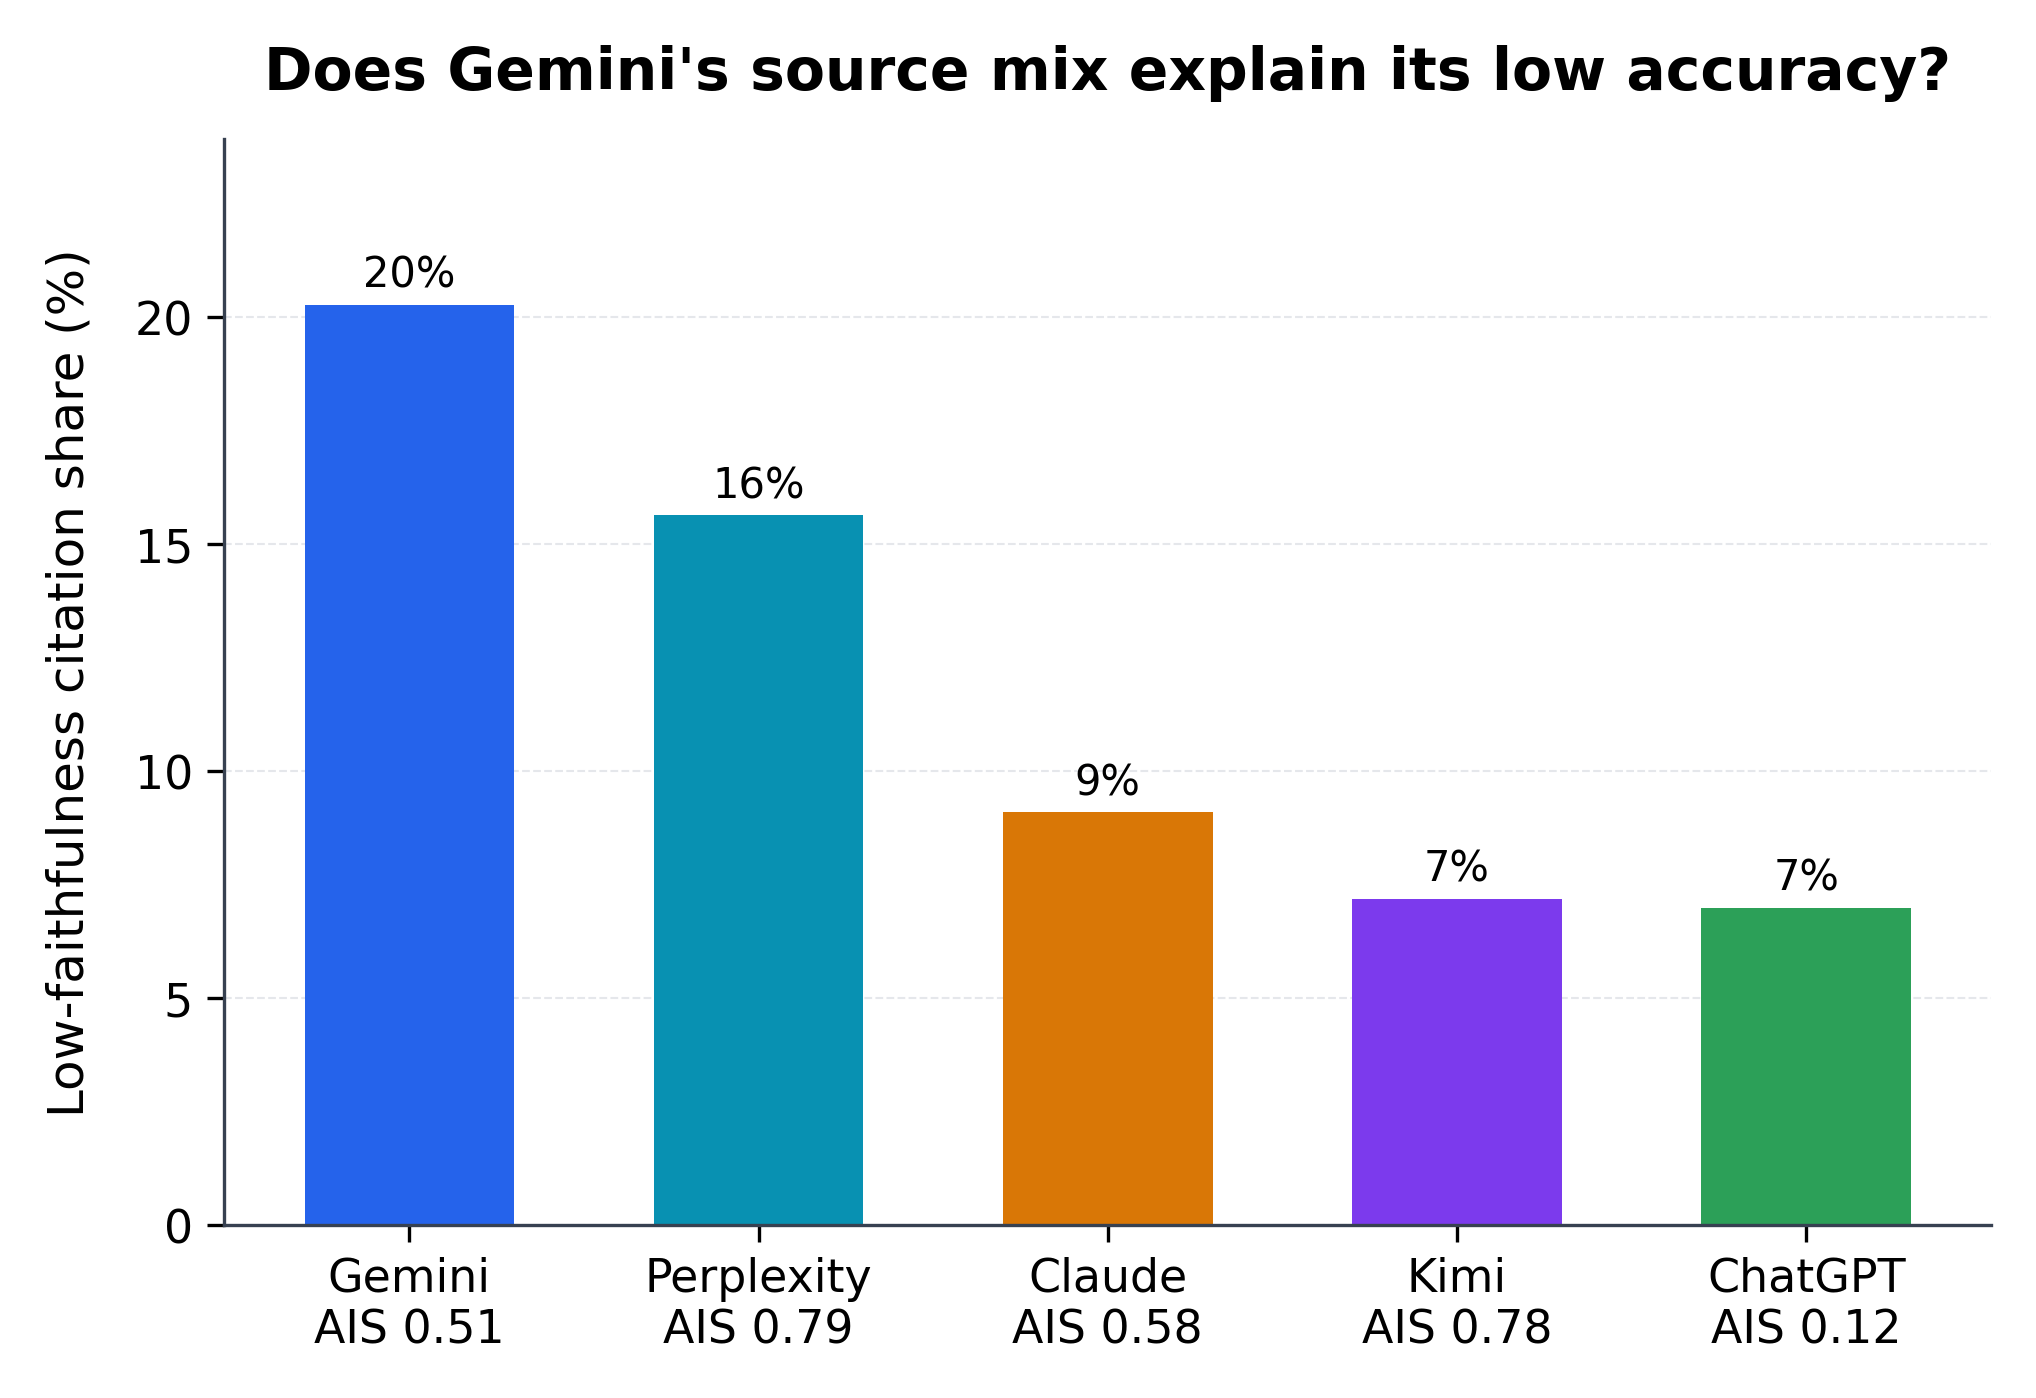

In [12]:
# D10 · Share of each engine's citations from low-faithfulness source types (mean entailment <0.42), with AIS.
sh = (cit.assign(low=cit.domain_type.isin(LOW_FAITH)).groupby("engine").low.mean()*100)
s = by_engine(sh).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.6, 4.7))
ax.bar(range(len(s)), s.values, width=0.6, color=[ENGINE_COLOURS[e] for e in s.index])
for i, e in enumerate(s.index):
    ax.text(i, s[e]+0.4, f"{s[e]:.0f}%", ha="center", fontsize=10)
ax.set_xticks(range(len(s)))
ax.set_xticklabels([f"{ENGINE_LABELS[e]}\nAIS {AIS_ENGINE[e]:.2f}" for e in s.index])
ax.set_ylabel("Low-faithfulness citation share (%)")
ax.set_title("Does Gemini's source mix explain its low accuracy?", pad=12)
ax.set_ylim(0, s.max()*1.18); apply_style(ax)
savefig(fig, "fig_domain_rq3_d10_lowfaith_share_vs_ais")

**Key analysis (SEO/GEO).** Partly yes. **Gemini draws 20% of its citations from low-faithfulness
source types (forum, video, database, research) — the highest of any engine and nearly 3× Kimi's 7%.** That is a
real driver of the anomaly RQ3 flagged: Gemini and Kimi cite a similar *number* of sources (≈ 7 vs 9), but Gemini
fills more of its citations with source types that rarely support the claim, so it lands at AIS 0.51 versus Kimi's
0.78. The explanation is not complete — Perplexity also leans on low-faithfulness types (16%) yet scores 0.79,
because it grounds more sentences overall — but source-type quality clearly separates Gemini from the other heavy
citers. **Action:** citation *volume* is not the lever; on Gemini-class engines the content type decides accuracy —
forum, video and database citations drag faithfulness down no matter how many you accumulate.

### RQ3 · D11 — Where does citation uncertainty come from: hedged sources or wrong sources?

Each source type (≥ 2,000 citation pairs) plotted by its **% contradiction** (entailment < 0.30, the source does
not support the claim) against its **% borderline** (0.30–0.50, plausible but unconfirmed). Marker size ∝ citation
volume. This separates the two ways a citation fails.

saved fig_domain_rq3_d11_failure_modes


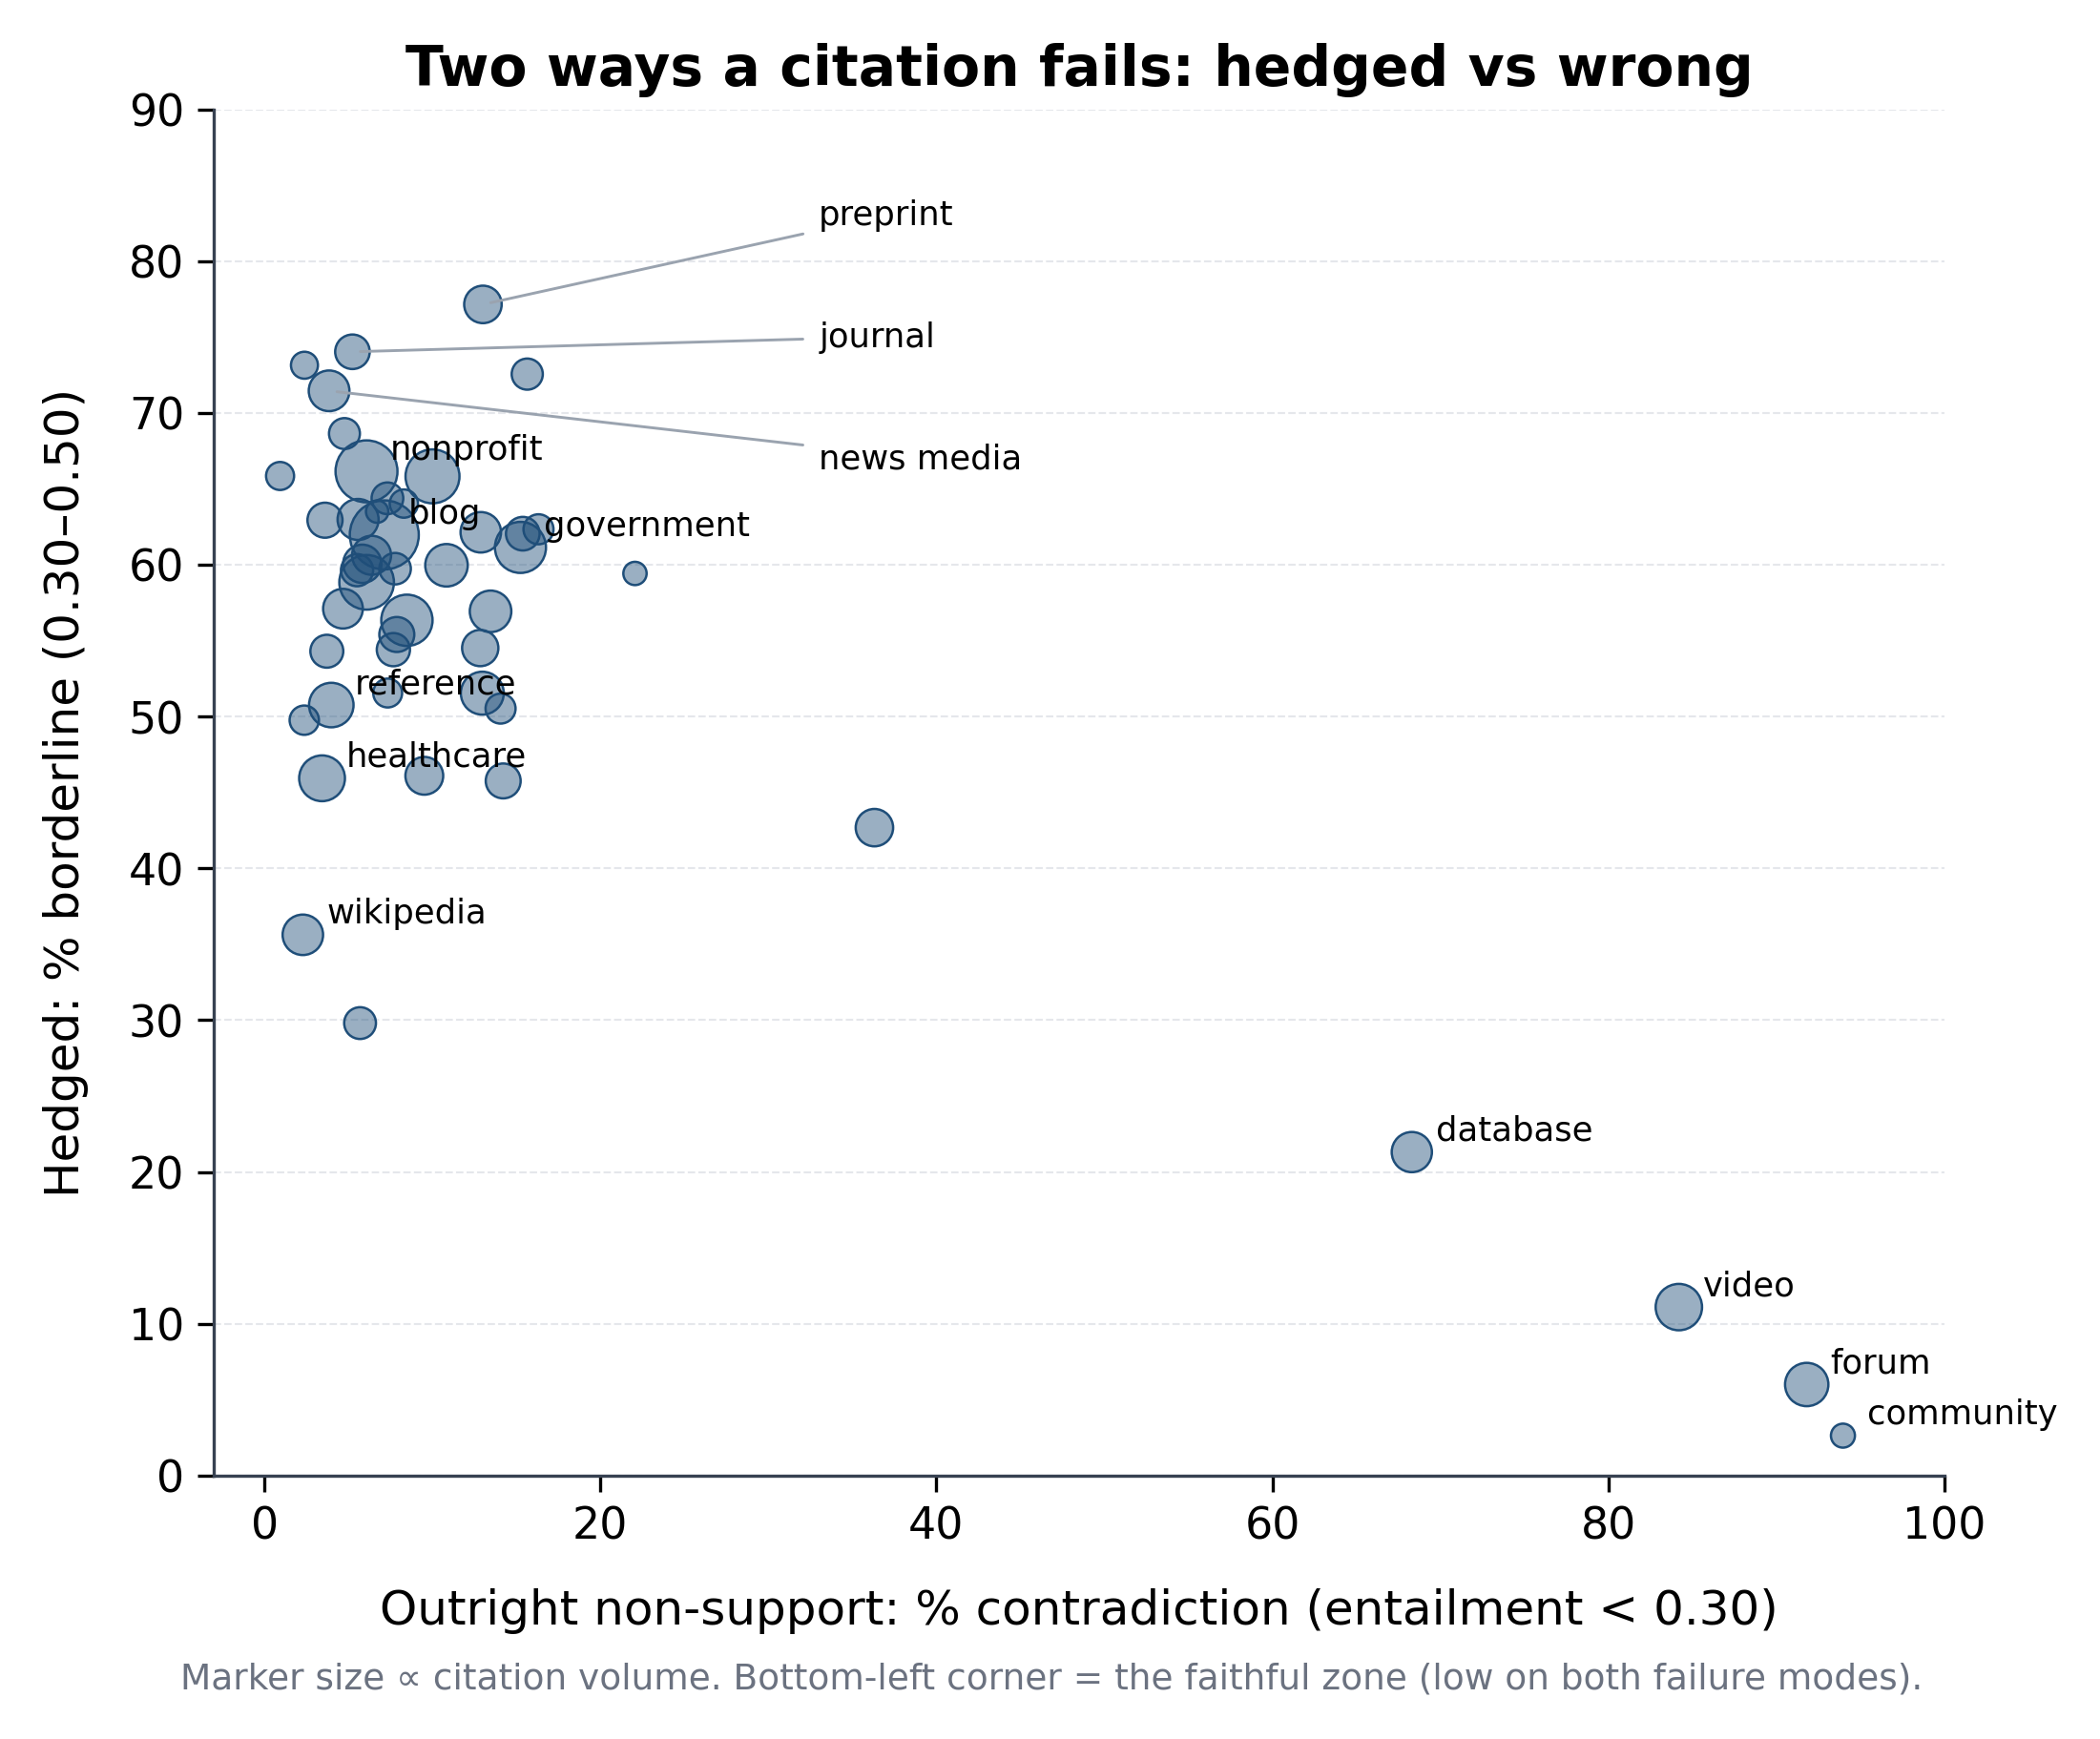

In [13]:
# D11 · Two failure modes by source type: % contradiction (x) vs % borderline (y). Marker size = citation volume.
E = ENTAIL_BY_TYPE[ENTAIL_BY_TYPE.n >= 2000].copy()
fig, ax = plt.subplots(figsize=(7.8, 6.2))
ax.scatter(E.pct_contra, E.pct_border, s=np.clip(np.sqrt(E.n)*0.7, 20, 340),
           color=mpl.colors.to_rgba(COLOUR_PRIMARY, 0.45), edgecolor=COLOUR_PRIMARY, linewidth=0.6, zorder=3)
LAB = ["forum","video","database","community","preprint","journal","news_media","nonprofit",
       "wikipedia","healthcare","blog","government","reference"]
_disp = lambda t: t.replace("_", " ")
# de-collide the top-left cluster (preprint / journal / news media) with leader lines into open space
CROWD = {"preprint": (33, 83), "journal": (33, 75), "news_media": (33, 67)}
for t in LAB:
    if t not in E.index: continue
    x0, y0 = E.loc[t, "pct_contra"], E.loc[t, "pct_border"]
    if t in CROWD:
        ax.annotate(_disp(t), xy=(x0, y0), xytext=CROWD[t], textcoords="data",
                    fontsize=8.5, ha="left", va="center",
                    arrowprops=dict(arrowstyle="-", color="#9AA3AF", lw=0.7))
    else:
        ax.annotate(_disp(t), (x0, y0), textcoords="offset points", xytext=(6, 3), fontsize=8.5)
ax.set_xlabel("Outright non-support: % contradiction (entailment < 0.30)")
ax.set_ylabel("Hedged: % borderline (0.30–0.50)")
ax.set_title("Two ways a citation fails: hedged vs wrong")
ax.set_xlim(-3, 100); ax.set_ylim(0, 90); apply_style(ax)
fig.text(0.5, -0.01, "Marker size ∝ citation volume. Bottom-left corner = the faithful zone (low on both failure modes).",
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
savefig(fig, "fig_domain_rq3_d11_failure_modes")

**Key analysis (SEO/GEO).** There are two distinct ways a citation fails, and they map onto different
source types. **Hedged "maybe" citations (the borderline band) are concentrated in academic and institutional
long-form sources — preprint (77% borderline), journal (74%), news media (71%), nonprofit (66%)** — where the
claim is plausibly related to dense source text the judge cannot strictly confirm. **Outright non-support
(contradiction) is concentrated in discussion and media UGC — forum (~92%), video (84%), database (68%)** — where
the cited page simply does not contain the claim. Wikipedia and healthcare sit in the clean corner (low on both).
**Action:** the borderline-citation problem RQ3 flagged (43–63% of citations) is largely an *academic/institutional*
sourcing effect, not a UGC one — if your content is a journal, report or news piece, make the specific cited claim
explicit and verbatim-checkable on the page so it clears the entailment bar rather than hovering in "maybe".

### RQ3 · D12 — Does citation accuracy depend on the query topic?

Engine × query-topic heatmap of mean AIS (cleaned), well-powered topics, ordered by overall accuracy. Each row's
**leader is ringed in red**. Tests whether faithfulness — and the most accurate engine — shifts by subject.

saved fig_domain_rq3_d12_ais_by_topic_heatmap


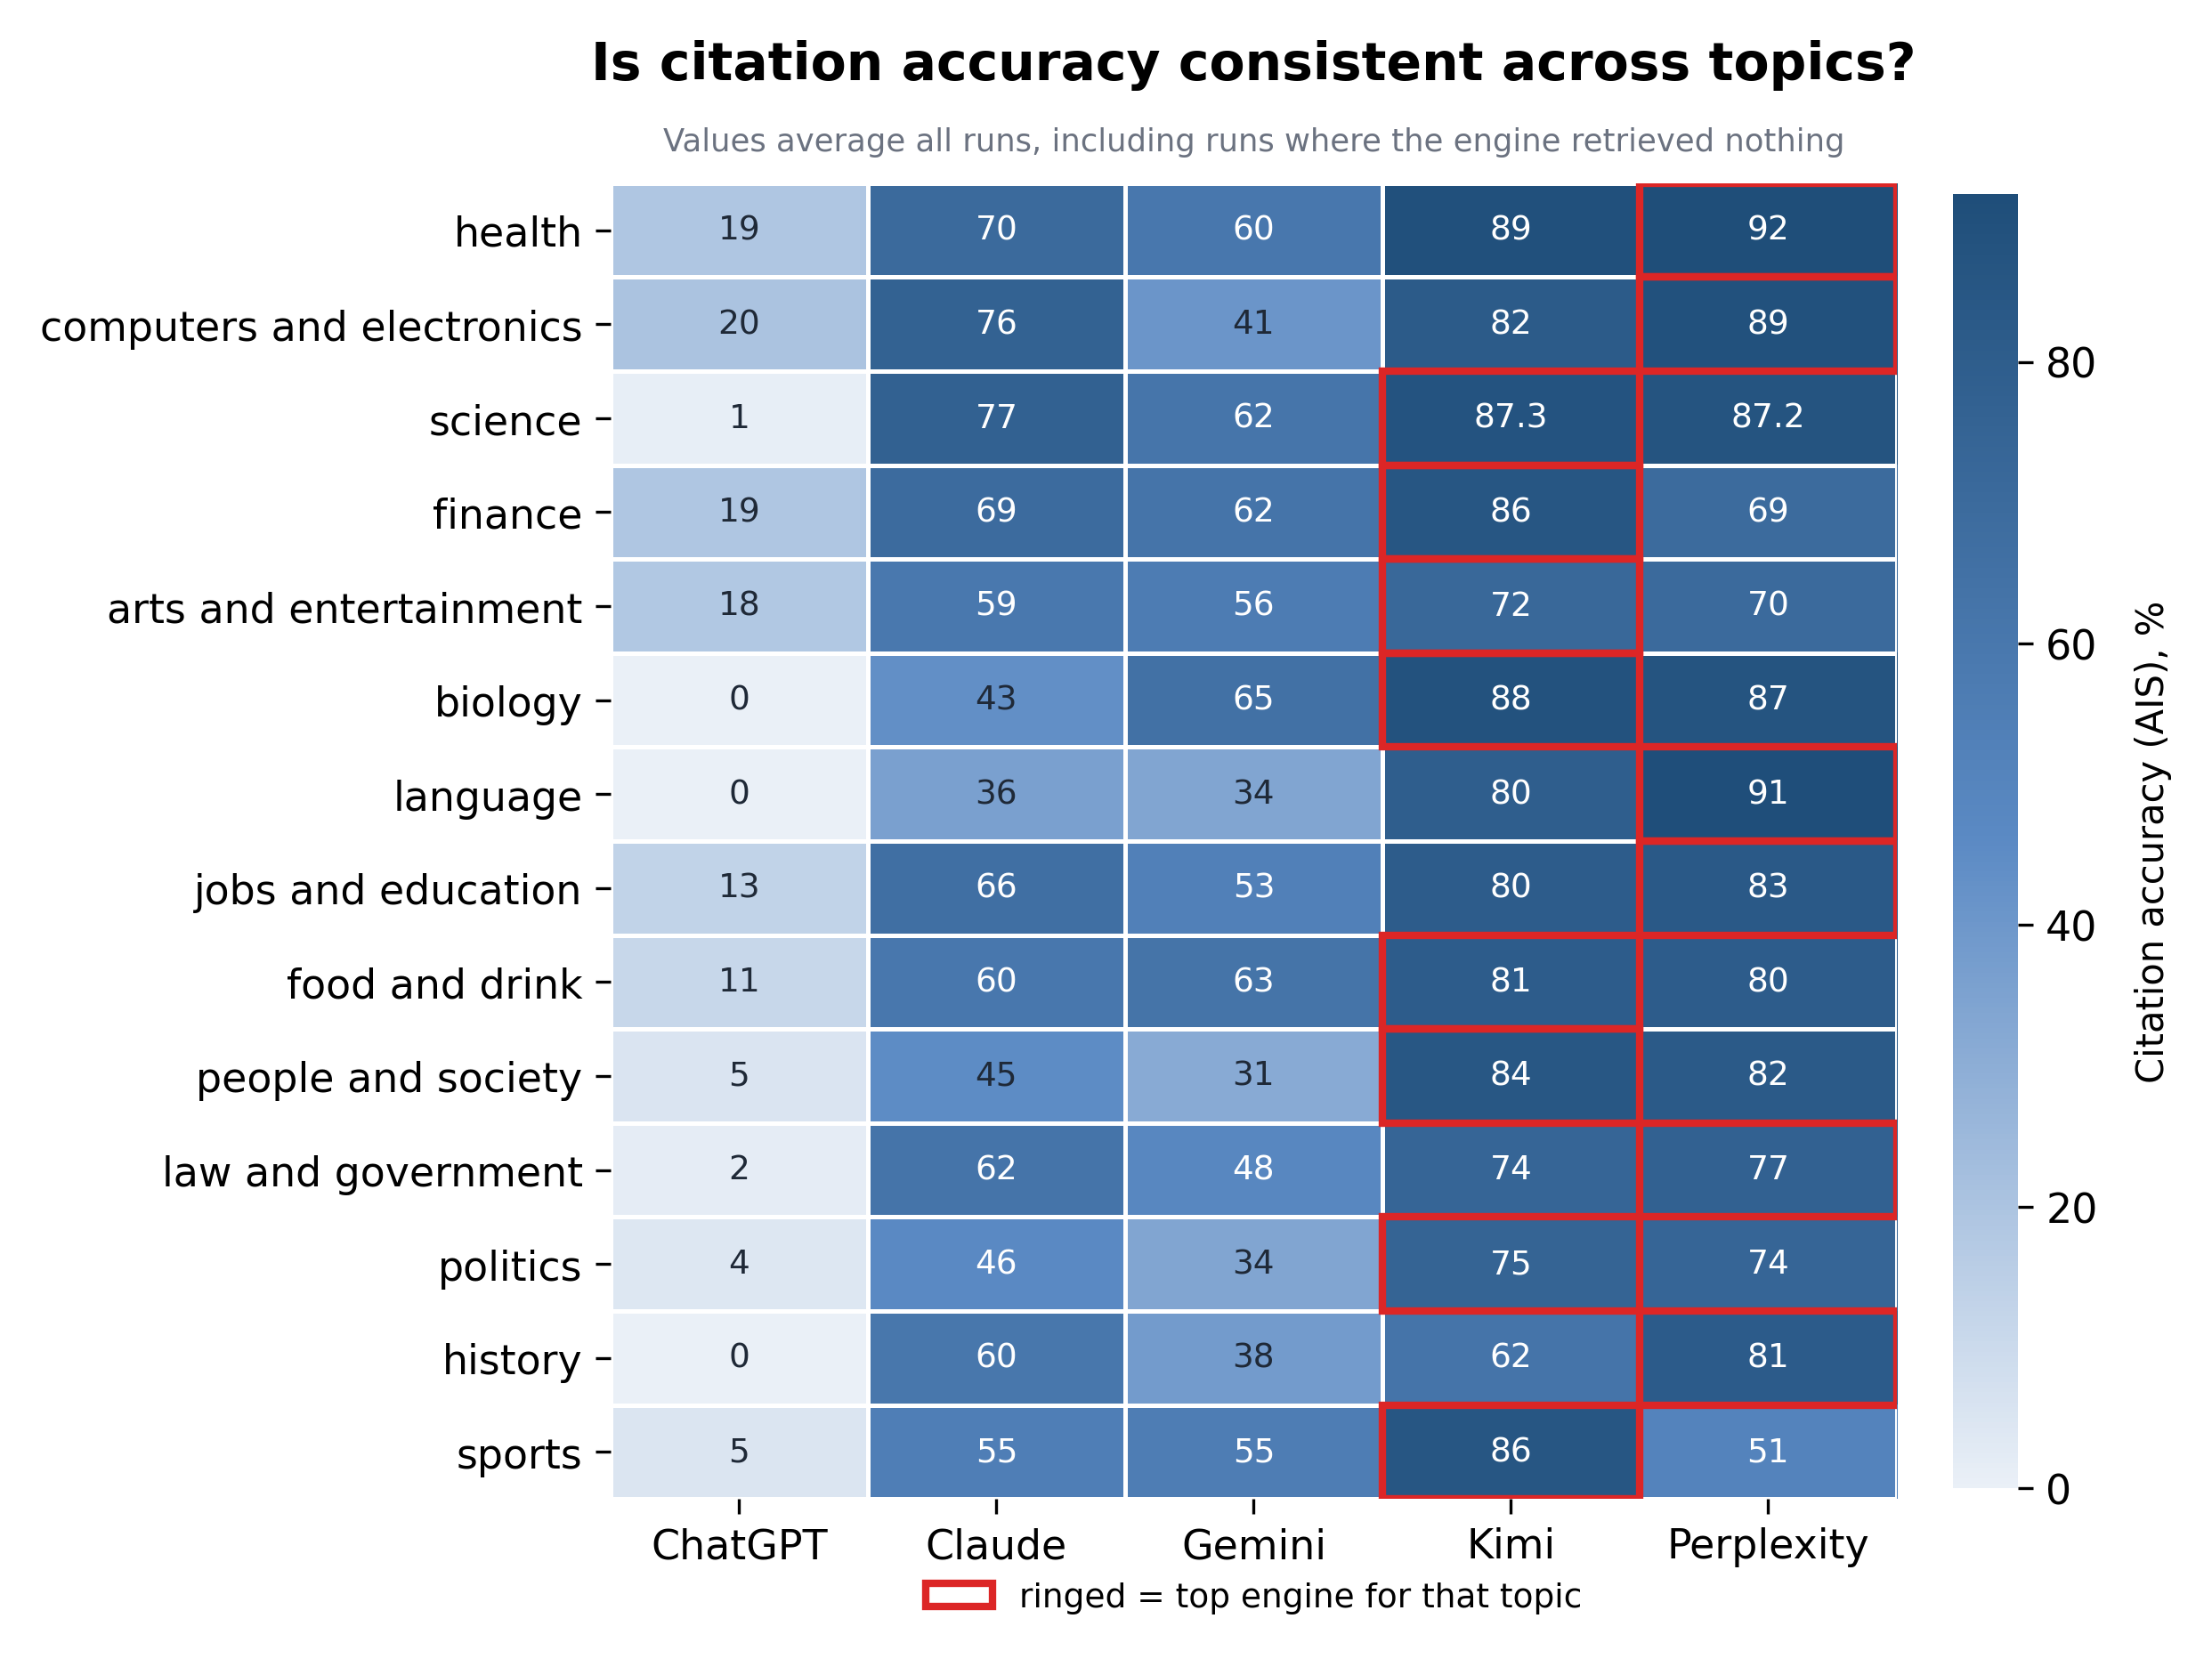

In [14]:
# D12 · Engine x query-topic heatmap of mean AIS (cleaned). Row leader ringed.
# Rows use the SAME shared TOPIC_ORDER defined in D2 (cell 7), so this heatmap lines up row-for-row
# with the D2 prominence heatmap (it does NOT re-sort by its own metric).
H = (caa[caa.query_domain.isin(WELL_POWERED)].groupby(["query_domain","engine"]).ais_mean.mean()
     .unstack().reindex(index=TOPIC_ORDER)[ENGINE_ORDER])
fig, ax = plt.subplots(figsize=(6.8, 6.4))

# Any row where the top-2 engines round to the same integer gets those two cells shown at one
# decimal place (all other cells stay "{:.0f}"), so a ringed leader over an apparent tie (e.g.
# science: Kimi 87.3 vs Perplexity 87.2) doesn't read as an arbitrary tie-break.
fmt_overrides = {}
for i, d in enumerate(TOPIC_ORDER):
    top2 = (H.loc[d] * 100).sort_values(ascending=False).iloc[:2]
    if round(top2.iloc[0]) == round(top2.iloc[1]):
        for eng in top2.index:
            fmt_overrides[(i, ENGINE_ORDER.index(eng))] = "{:.1f}"

draw_heatmap(ax, H.values*100, TOPIC_ORDER, [ENGINE_LABELS[e] for e in ENGINE_ORDER],
             fmt="{:.0f}", xrot=0, cbar_label="Citation accuracy (AIS), %", fmt_overrides=fmt_overrides)
for i, d in enumerate(TOPIC_ORDER):
    j = ENGINE_ORDER.index(H.loc[d].idxmax())
    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor=COLOUR_REFERENCE, linewidth=2))
ax.set_title("Is citation accuracy consistent across topics?", pad=28)
ax.text(0.5, 1.02, "Values average all runs, including runs where the engine retrieved nothing",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=8.5, color=COLOUR_NEUTRAL)
ax.legend(handles=[Patch(facecolor="none", edgecolor=COLOUR_REFERENCE, linewidth=2,
                         label="ringed = top engine for that topic")],
          loc="lower center", bbox_to_anchor=(0.5, -0.11), frameon=False, fontsize=9)
savefig(fig, "fig_domain_rq3_d12_ais_by_topic_heatmap")


In [15]:
# Validation · D12 plotted values (science row: exact AIS values behind the Kimi/Perplexity tie at 87)
print("D12 science row, plotted AIS values (%, full precision):")
print((H.loc["science"] * 100).round(3).to_string())
print("\nRows using the 1-decimal tie-break format (top-2 engines round to the same integer):")
for (i, j), f in sorted(fmt_overrides.items()):
    print(f"  {TOPIC_ORDER[i]!r}, {ENGINE_LABELS[ENGINE_ORDER[j]]}: {H.iloc[i, j]*100:.3f}  (fmt={f})")


D12 science row, plotted AIS values (%, full precision):
engine
chatgpt        1.042
claude        76.783
gemini        61.553
kimi          87.283
perplexity    87.157

Rows using the 1-decimal tie-break format (top-2 engines round to the same integer):
  'science', Kimi: 87.283  (fmt={:.1f})
  'science', Perplexity: 87.157  (fmt={:.1f})


**Key analysis (SEO/GEO).** Citation accuracy tracks query topic the same way prominence does (D1):
**health (mean AIS 0.66), science (0.63) and computers & electronics (0.62) are cited most accurately; politics
(0.46), language (0.48) and history (0.48) least.** Leadership also shifts — **Kimi tops 8 of 14 topics and
Perplexity 6** — and even they swing by topic (each ranges ≈ 0.27–0.41 across topics). ChatGPT is near zero
everywhere (its coverage problem). **Action:** trust engine citations most on factual/technical queries; on
politics, history and language, verify what an engine attributes to you even on the most accurate engines, because
faithfulness drops across the board there.

## Cross-cutting — does the *interaction* of query topic and source type matter?

Two synthesis questions that combine both taxonomies: whether citing **topically-matched** sources earns more
faithful citations (D13), and whether a **diverse** source portfolio trades source prominence for citation
accuracy (D14). Both are correlational, cell-level analyses (one value per engine × query).

### Cross-cutting · D13 — Does citing topically-matched sources improve accuracy?

Per cell, topic-source **alignment** = the share of citations whose source type matches the query topic (e.g. a
health query citing healthcare/pharma/fitness; a finance query citing fintech/banking). Plotted against AIS, one
panel per engine, over the 10 well-powered topics with a defined source mapping. Overall and topic-demeaned ρ
appear in the caption.

saved fig_domain_cross_d13_alignment_vs_ais


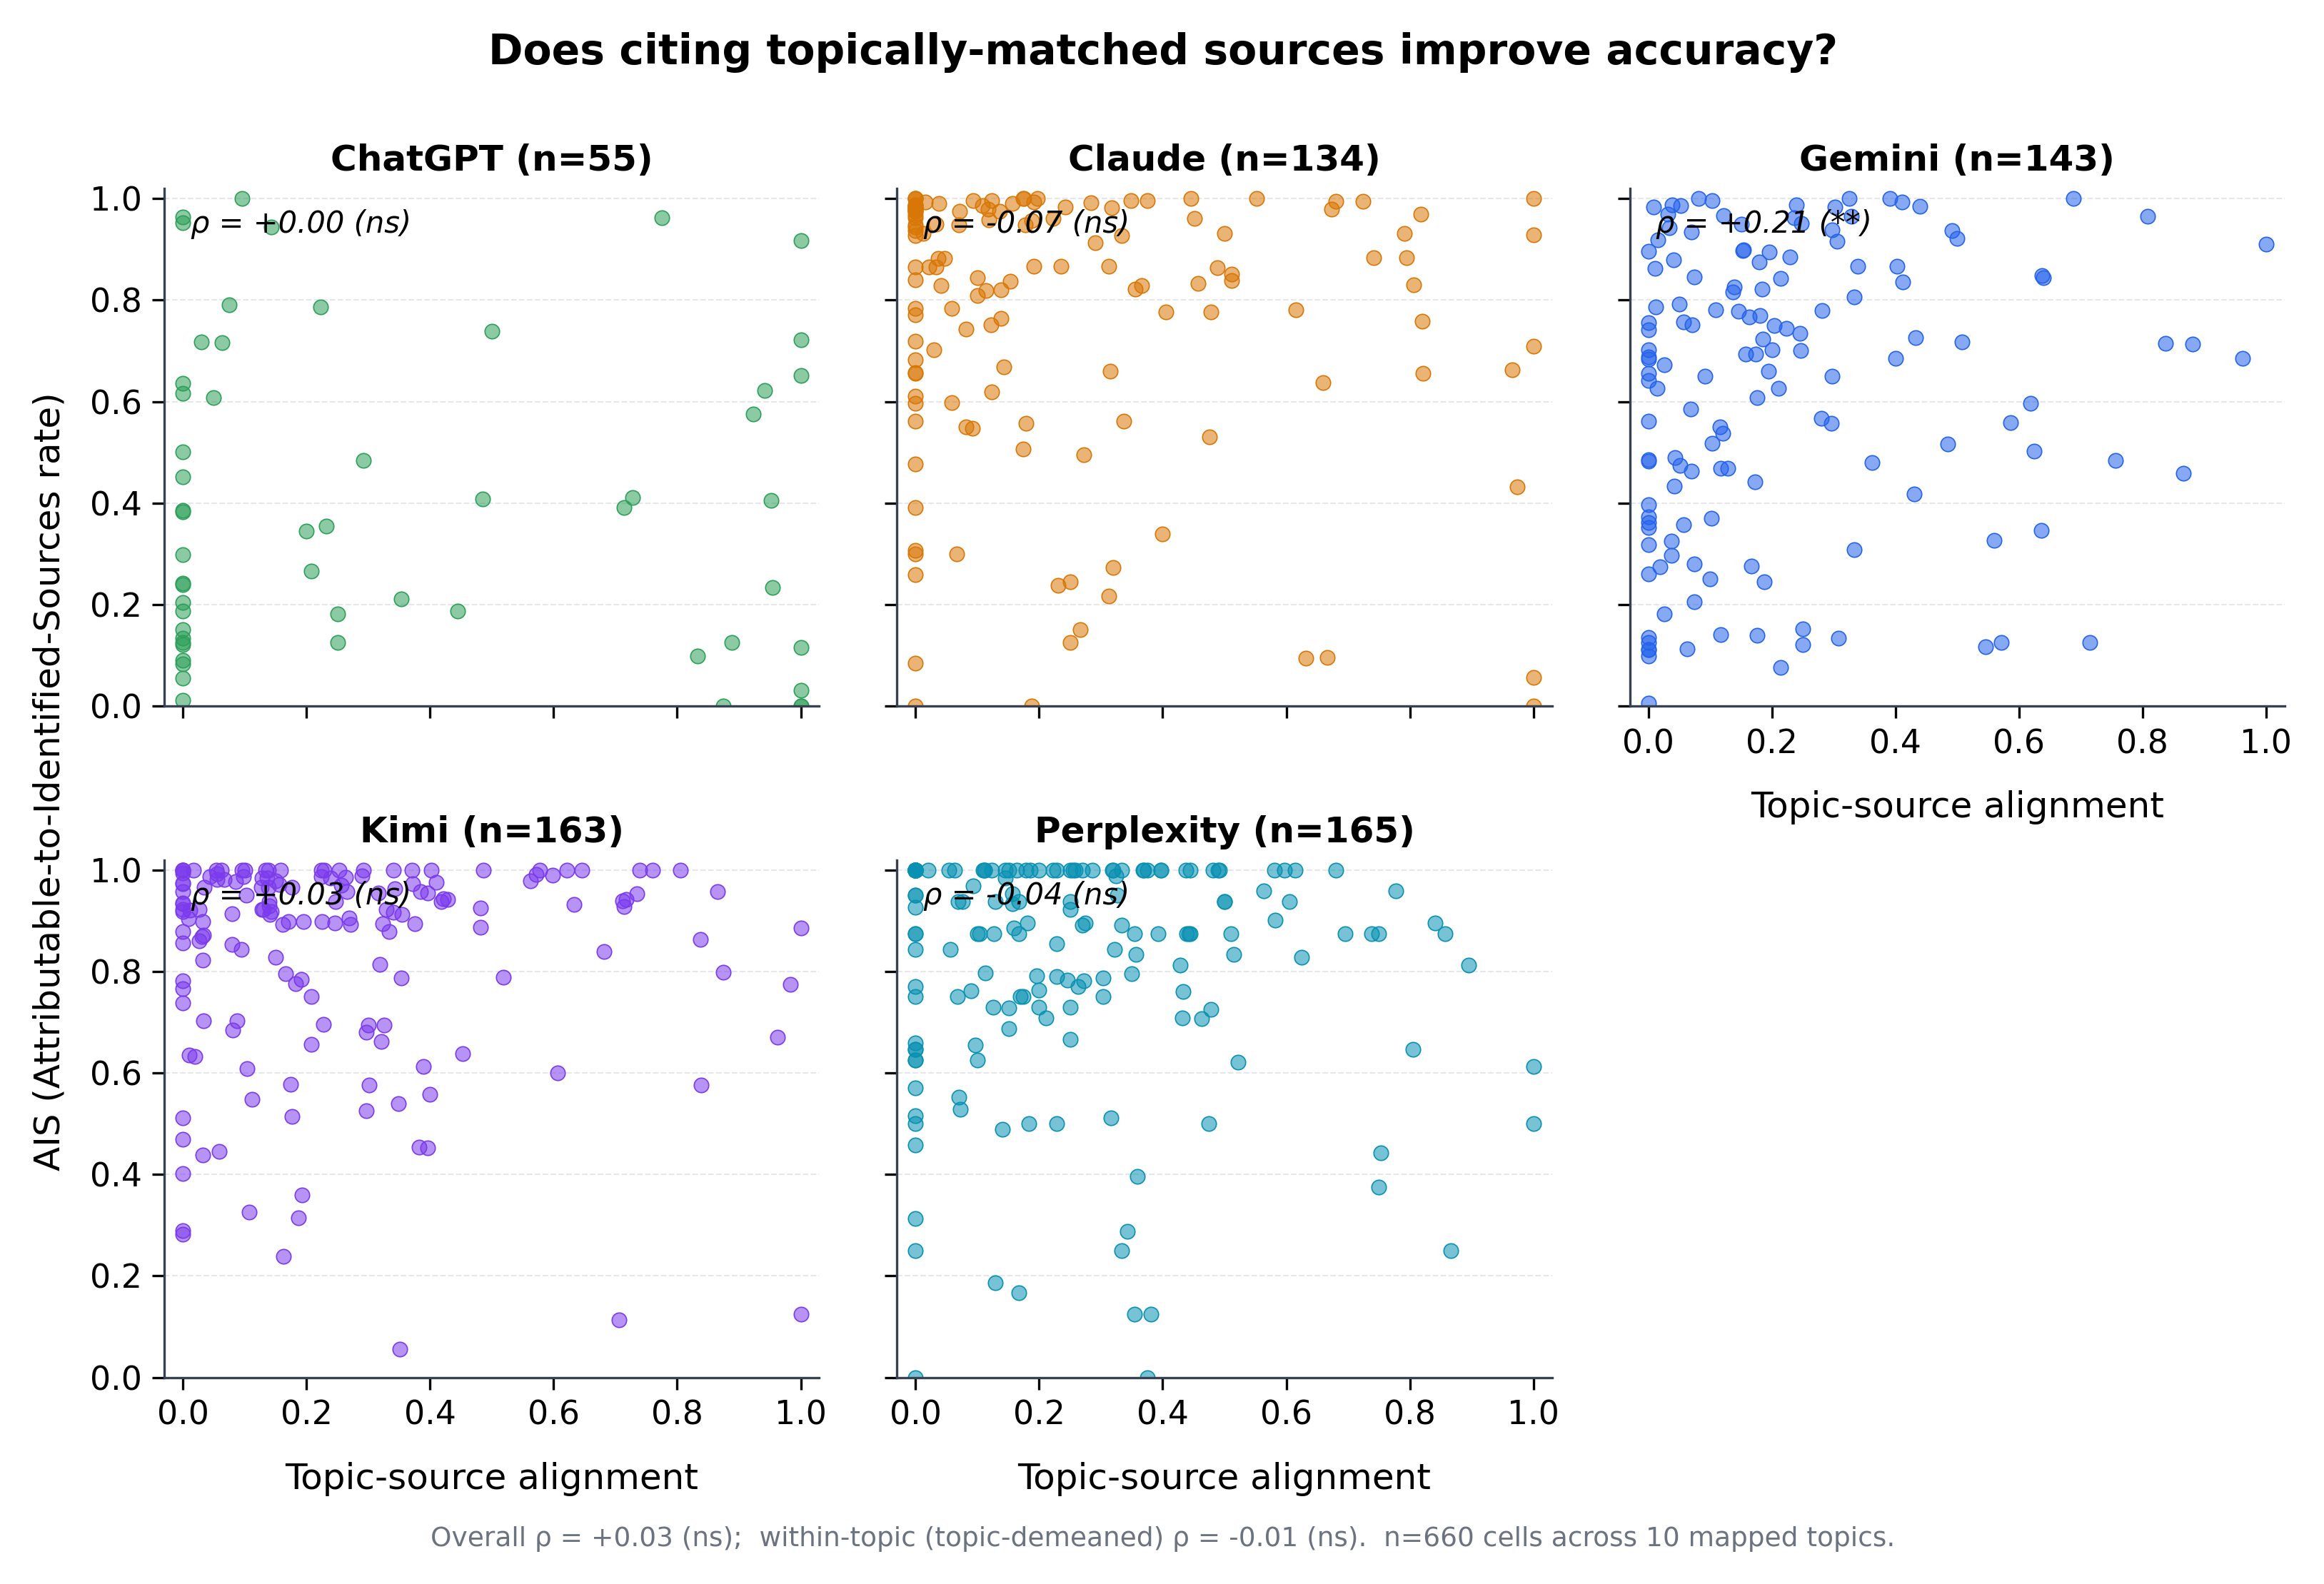

In [16]:
# D13 · Topic-source alignment vs AIS, faceted per engine. Positive rho => on-topic sourcing -> more faithful.
d = ca.merge(ALIGN_CELL, on=["engine","query_id"]).dropna(subset=["ais_mean","align"])
def _stars(p): return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
for ax, e in zip(axes.ravel(), ENGINE_ORDER):
    de = d[d.engine == e]
    ax.scatter(de["align"], de.ais_mean, s=24, color=mpl.colors.to_rgba(ENGINE_COLOURS[e], 0.55),
               edgecolor=ENGINE_COLOURS[e], linewidth=0.4)
    r, p = spearmanr(de["align"], de.ais_mean)
    ax.set_title(f"{ENGINE_LABELS[e]} (n={len(de)})", fontsize=12)
    ax.text(0.04, 0.96, f"ρ = {r:+.2f} ({_stars(p)})", transform=ax.transAxes, fontsize=10, style="italic", va="top")
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(0, 1.02); apply_style(ax)
axes[1, 2].axis("off")
axes[0, 2].tick_params(labelbottom=True)                 # bottom-right panel is off -> keep Gemini's x-ticks
for ax in (axes[1, 0], axes[1, 1], axes[0, 2]): ax.set_xlabel("Topic-source alignment")
fig.supylabel("AIS (Attributable-to-Identified-Sources rate)", fontsize=12)
ro, po = spearmanr(d["align"], d.ais_mean)
dd = d.merge(QDOM, on="query_id")
dd["ais_dm"] = dd.ais_mean - dd.groupby("query_domain").ais_mean.transform("mean")
dd["al_dm"]  = dd["align"] - dd.groupby("query_domain")["align"].transform("mean")
rw, pw = spearmanr(dd.al_dm, dd.ais_dm)
fig.suptitle("Does citing topically-matched sources improve accuracy?", y=1.0, fontweight="bold", fontsize=14)
fig.text(0.5, -0.01, f"Overall ρ = {ro:+.2f} ({_stars(po)});  within-topic (topic-demeaned) ρ = {rw:+.2f} ({_stars(pw)}).  n={len(d)} cells across 10 mapped topics.",
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
fig.tight_layout()
savefig(fig, "fig_domain_cross_d13_alignment_vs_ais")

**Key analysis (SEO/GEO).** This is the study's most intuitive hypothesis — match your content type to
the query topic and get cited more faithfully — and the data does **not** support it. Across 660 cells the
relationship is essentially zero (**overall ρ = +0.03, ns; within-topic ρ = −0.01, ns**), and only **Gemini**
shows even a weak positive (ρ = +0.22). The reason ties back to D9/D11: a topic's "natural" sources are not always
faithful — for science and biology queries the aligned types are journals, preprints and databases, which entail
*poorly*, so citing them on-topic does not raise accuracy. **Action:** do not assume that being the
topically-obvious source (a fintech site for a finance query) earns a faithful citation. What governs
faithfulness is the source type's intrinsic entailment quality (D9), not whether it matches the subject — being
clearly verifiable beats being on-topic.

### Cross-cutting · D14 — Does a diverse source mix dilute prominence but aid accuracy?

Per cell, source-type **diversity** = Shannon entropy of its citations' domain_type mix. Bars show the Spearman
correlation of entropy with PAWC_norm and with AIS, per engine (significance starred). Entropy rises with citation
count (ρ ≈ 0.57), so read these as associations, not count-controlled effects.

saved fig_domain_cross_d14_entropy_vs_metrics


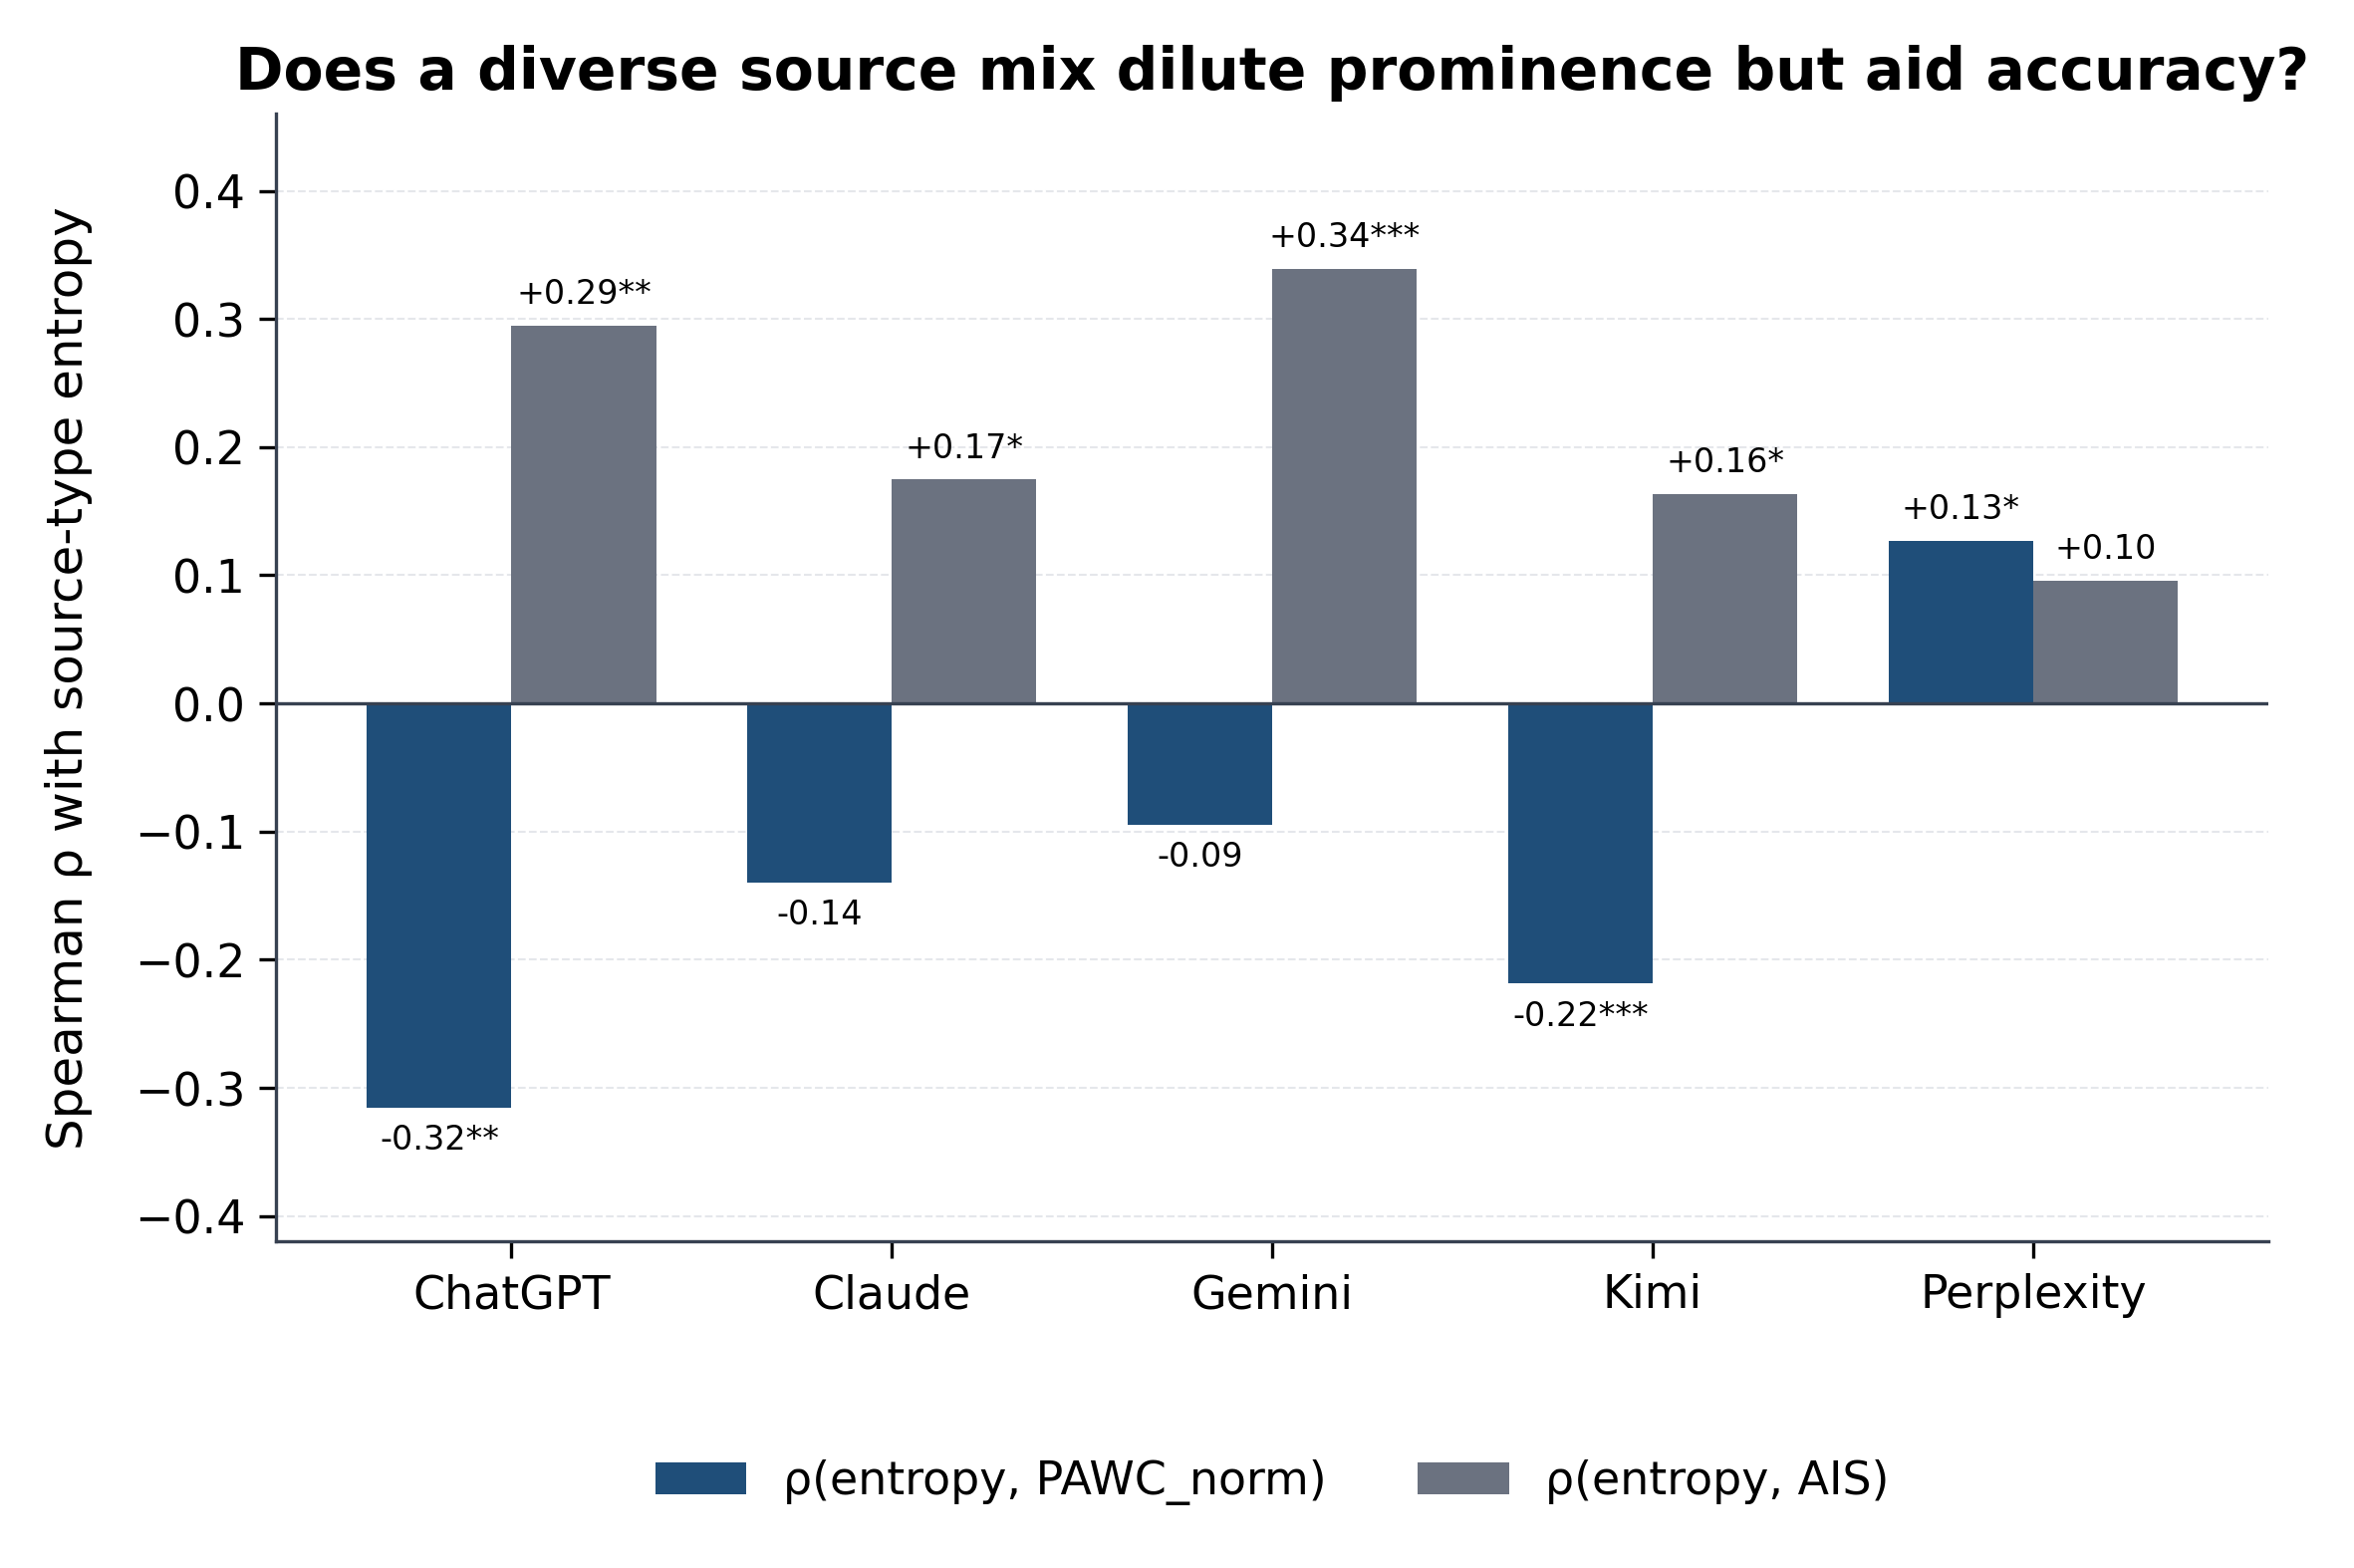

In [17]:
# D14 · Source-type diversity (Shannon entropy of a cell's citation mix) vs prominence and accuracy, per engine.
d = ca.merge(ENTROPY_CELL, on=["engine","query_id"])
def _star(p): return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
rows = []
for e in ENGINE_ORDER:
    de = d[d.engine == e]
    dp = de.dropna(subset=["pawc_norm_mean"]); da = de.dropna(subset=["ais_mean"])
    rp, pp = spearmanr(dp.H, dp.pawc_norm_mean); ra, pa = spearmanr(da.H, da.ais_mean)
    rows.append((e, rp, pp, ra, pa))
x = np.arange(5); w = 0.38
fig, ax = plt.subplots(figsize=(8.6, 4.9))
ax.bar(x - w/2, [r[1] for r in rows], w, color=COLOUR_PRIMARY, label="ρ(entropy, PAWC_norm)")
ax.bar(x + w/2, [r[3] for r in rows], w, color=COLOUR_NEUTRAL, label="ρ(entropy, AIS)")
for i, (e, rp, pp, ra, pa) in enumerate(rows):
    ax.text(i - w/2, rp + (0.012 if rp >= 0 else -0.012), f"{rp:+.2f}{_star(pp)}", ha="center",
            va="bottom" if rp >= 0 else "top", fontsize=8)
    ax.text(i + w/2, ra + (0.012 if ra >= 0 else -0.012), f"{ra:+.2f}{_star(pa)}", ha="center",
            va="bottom" if ra >= 0 else "top", fontsize=8)
ax.axhline(0, color="#374151", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER])
ax.set_ylabel("Spearman ρ with source-type entropy")
ax.set_title("Does a diverse source mix dilute prominence but aid accuracy?")
ax.set_ylim(-0.42, 0.46); ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.27), ncol=2)
apply_style(ax); ax.yaxis.grid(True, color="#E5E7EB", lw=0.5, ls="--"); ax.xaxis.grid(False)
savefig(fig, "fig_domain_cross_d14_entropy_vs_metrics")

**Key analysis (SEO/GEO).** The two-sided hypothesis broadly holds. **More diverse source mixes go with
lower source prominence** — ρ(entropy, PAWC_norm) is negative for four of five engines (ChatGPT −0.32, Kimi −0.22,
Claude −0.14), i.e. spreading citations across many source types dilutes how prominently any one is surfaced.
**At the same time diversity goes with higher citation accuracy** — ρ(entropy, AIS) is positive for all five
engines (Gemini +0.34, ChatGPT +0.29, Claude +0.17), consistent with cross-validation across varied sources.
Perplexity is the partial exception (prominence edges *up* with diversity, +0.13). The accuracy link is partly
entangled with citation count (more citations bring both more diversity and more covered sentences), so treat it
as an association. **Action:** a broad, varied source base tends to read as more accurate but spreads prominence
thin — if your goal is to *be the* prominent source, you benefit when an engine concentrates on few types; if the
goal is ecosystem-level trust, diversity helps.

### Figure 7 — Citation concentration: how few domains capture each engine's citations

Cumulative share of each engine's citation events captured by its **top-N most-cited registrable domains**
(subdomains collapsed via tldextract; Gemini's redirect-wrapper URLs are already resolved in the enriched
`domain` column). The **full** curve is shown — one line per engine, from N = 1 to that engine's total number
of cited domains — so both the head (a few dominant domains) and the long tail are visible. **CR10** (the share
at N = 10, reported in the text) is marked with a reference line.

saved fig_insights_i11_citation_concentration -> figures/scaleup/
CR10 (N=10) per engine: {'chatgpt': 22.0, 'claude': 17.4, 'gemini': 26.3, 'kimi': 8.0, 'perplexity': 23.7}


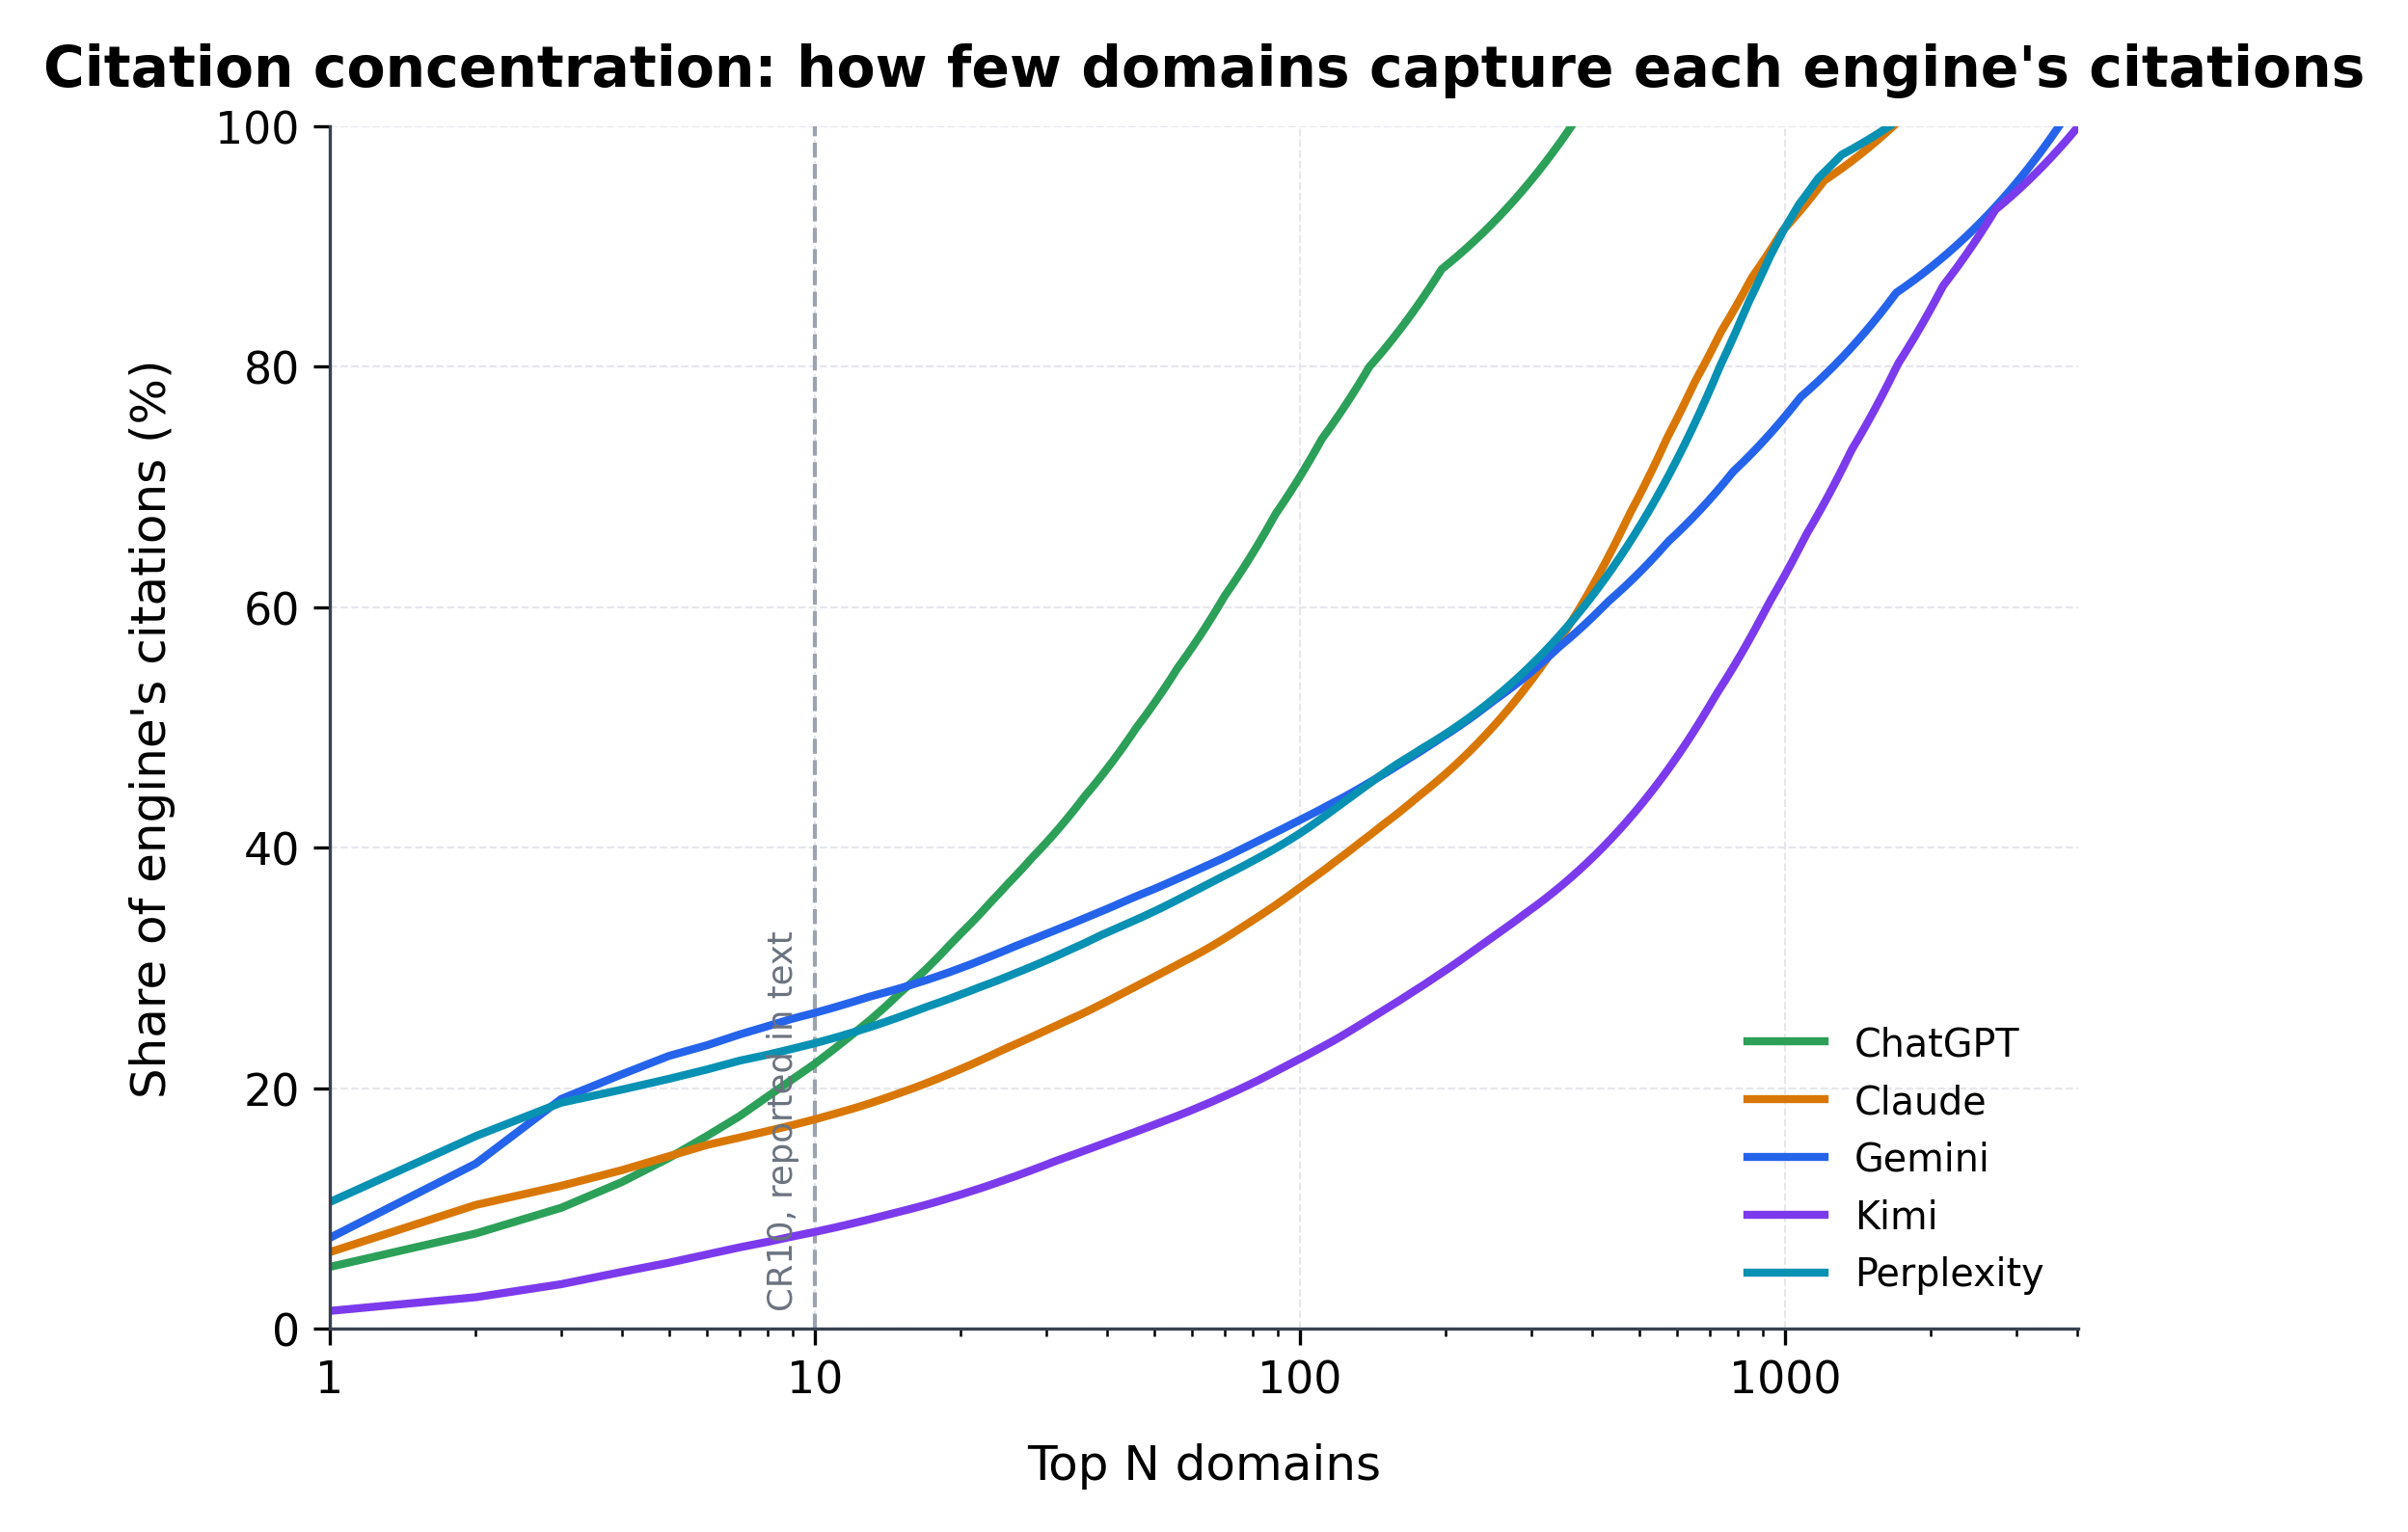

In [18]:
# Figure 7 · Citation concentration curve. Per engine: rank registrable domains by citation frequency, then plot
# the cumulative share (%) of that engine's citations captured by its top-N domains. Full curve (N=1..n_domains),
# log-N x-axis. CR10 = the value at N=10 (reported in text). tldextract collapses subdomains to the registrable
# domain and reproduces the reported CR10s (ChatGPT 22.0, Claude 17.4, Gemini 26.3, Kimi 8.0, Perplexity 23.7).
import tldextract
_ex = tldextract.TLDExtract(suffix_list_urls=())                       # offline bundled suffix snapshot (no network)
def _regdom(h):
    if not isinstance(h, str): return None
    r = _ex(h); return (r.domain + "." + r.suffix) if r.suffix else (r.domain or None)
_rd = cit.assign(rd=cit.domain.map(_regdom)).dropna(subset=["rd"])
fig, ax = plt.subplots(figsize=(7.8, 5.4))
for e in ENGINE_ORDER:                                                 # fixed engine order, standard colours
    vc = _rd[_rd.engine == e].rd.value_counts()                        # domains ranked by citation frequency (desc)
    cum = (vc.cumsum() / vc.sum()).values * 100                        # cumulative % of this engine's citations
    ax.plot(np.arange(1, len(cum) + 1), cum, color=ENGINE_COLOURS[e], linewidth=2, label=ENGINE_LABELS[e])
xmax = int(_rd.groupby("engine").rd.nunique().max())
ax.axvline(10, color="#9CA3AF", linewidth=1.0, linestyle="--", zorder=1)                       # CR10 reference line
ax.text(9.3, 1.5, "CR10, reported in text", rotation=90, ha="right", va="bottom",
        fontsize=8.5, color="#6B7280")
ax.set_xscale("log")
ax.set_xticks([1, 10, 100, 1000]); ax.set_xticklabels(["1", "10", "100", "1000"])
ax.set_xlim(1, xmax); ax.set_ylim(0, 100)
ax.set_xlabel("Top N domains")
ax.set_ylabel("Share of engine's citations (%)")
ax.set_title("Citation concentration: how few domains capture each engine's citations", pad=10)
apply_style(ax)
ax.grid(True, which="major", axis="both", color=COLOUR_GRID, linewidth=0.5, linestyle="--"); ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=9.5)
base = "fig_insights_i11_citation_concentration"                       # thesis Figure-7 identity (data-driven rebuild)
for ext in ("png", "pdf"): fig.savefig(f"../../figures/scaleup/{base}.{ext}")   # requested target
print("saved", base, "-> figures/scaleup/")
print("CR10 (N=10) per engine:",
      {e: round(float((_rd[_rd.engine == e].rd.value_counts().cumsum()
                       / _rd[_rd.engine == e].rd.shape[0]).iloc[9]) * 100, 1) for e in ENGINE_ORDER})

**Key analysis (SEO/GEO).** The five engines run structurally different citation economies. Reading the head of
each curve at **N = 10 (CR10)**: Gemini is the most concentrated — its top 10 domains absorb **26.3%** of its
citations — with Perplexity close behind (**23.7%**), while **Kimi is a long-tail market** where the top 10 take
just **8.0%** and its single most-cited domain only 1.5%. ChatGPT (22.0%) and Claude (17.4%) sit in between. The
full curves make the trade-off concrete: on head-heavy engines a handful of authority domains are the whole game,
whereas on Kimi (and to a lesser extent Claude) citations are spread across thousands of domains, so breadth of
presence matters more than displacing a few incumbents.

### Figure 9 — Reference-format faithfulness premium (clearly-supported share by source format)

For each engine, the share of its (sentence, citation) NLI pairs that are **clearly supported** (entailment
≥ 0.50), split into two source-format groups: **reference formats** (Wikipedia / reference / healthcare) and
**commercial / editorial** prose (blog, news, SaaS, fintech, e-commerce). These are proportions of citations,
so each is a point estimate with a **95% Wilson confidence interval** (not a box plot). Matches section 4.1.3:
reference formats land at 49–66% clearly supported versus 26–38% for commercial/editorial, on every engine.

saved fig_domain_rq3_faithfulness_by_format
also saved fig_domain_rq3_faithfulness_by_format -> figures/scaleup/


OK: reference CI lower bound > commercial CI upper bound on every engine (intervals do not overlap)


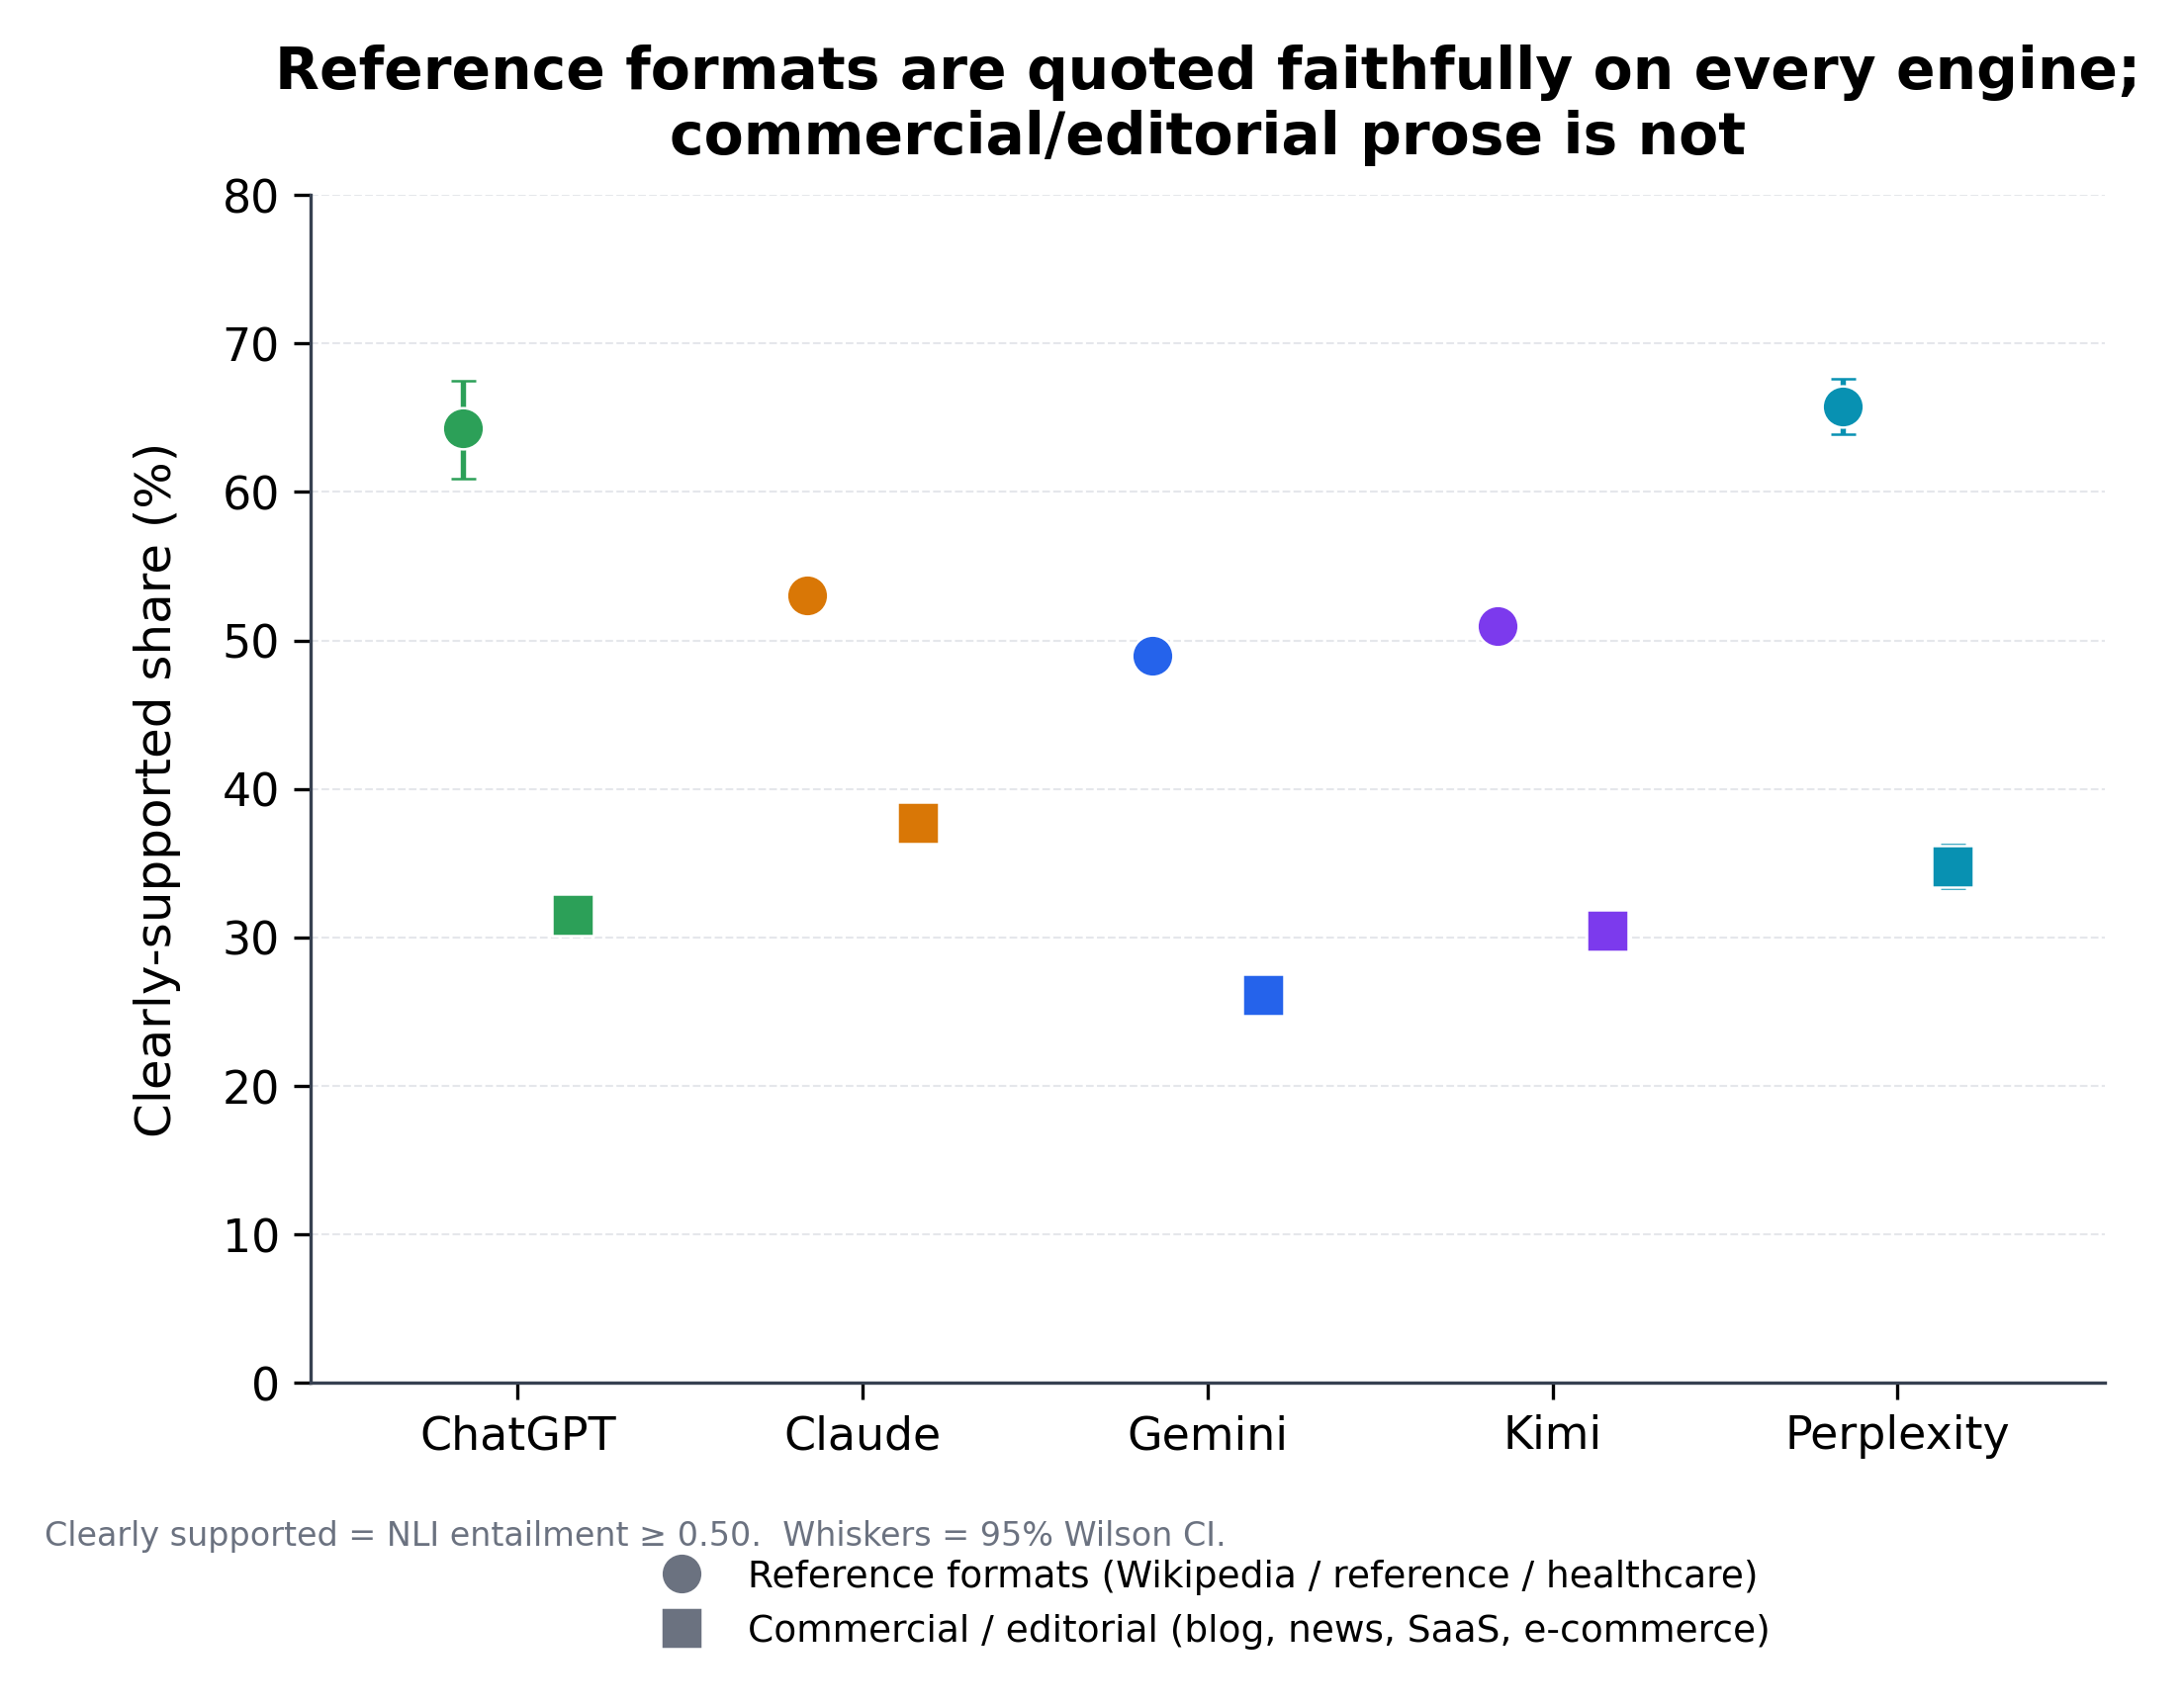

In [19]:
# Figure 9 · Clearly-supported share by source format, per engine. Proportions -> point estimate + 95% Wilson CI.
# Reference = wikipedia/reference/healthcare; commercial/editorial = blog/blogging/news_media/saas/fintech/ecommerce
# (definitions from Insight 9 / section 4.1.3). Engine encoded by colour; format group by MARKER SHAPE.
REF_TYPES = {"wikipedia", "reference", "healthcare"}
COM_TYPES = {"blog", "blogging", "news_media", "saas", "fintech", "ecommerce"}
_supp = F4.assign(supp=(F4.entail_score >= 0.50).astype(int))              # clearly supported = NLI entailment >= 0.50
def _wilson(k, n, z=1.96):                                                  # Wilson score interval for a proportion (%)
    p = k / n; c = (p + z*z/(2*n)) / (1 + z*z/n)
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
    return p*100, (c-h)*100, (c+h)*100
GROUPS = [("Reference formats (Wikipedia / reference / healthcare)", REF_TYPES, "o"),
          ("Commercial / editorial (blog, news, SaaS, e-commerce)", COM_TYPES, "s")]
DODGE = (-0.16, 0.16)
fig, ax = plt.subplots(figsize=(7.8, 5.2))
for gi, (glabel, gtypes, mk) in enumerate(GROUPS):
    for xi, e in enumerate(ENGINE_ORDER):
        sub = _supp[(_supp.engine == e) & (_supp.domain_type.isin(gtypes))]
        p, lo, hi = _wilson(int(sub.supp.sum()), len(sub))
        ax.errorbar(xi + DODGE[gi], p, yerr=[[p - lo], [hi - p]], fmt=mk, color=ENGINE_COLOURS[e],
                    markersize=10, markeredgecolor="white", markeredgewidth=0.6,
                    ecolor=ENGINE_COLOURS[e], elinewidth=1.3, capsize=3, capthick=1.3, zorder=3)
ax.set_xticks(range(len(ENGINE_ORDER))); ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER])
ax.set_xlim(-0.6, len(ENGINE_ORDER) - 0.4)
ax.set_ylabel("Clearly-supported share (%)"); ax.set_ylim(0, 80)
ax.set_title("Reference formats are quoted faithfully on every engine;\ncommercial/editorial prose is not", pad=10)
apply_style(ax); ax.grid(False)
ax.yaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--"); ax.set_axisbelow(True)
legh = [Line2D([0], [0], marker=mk, linestyle="none", color=COLOUR_NEUTRAL, markersize=10,
               markeredgecolor="white", markeredgewidth=0.6, label=glabel) for glabel, _, mk in GROUPS]
ax.legend(handles=legh, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=9, frameon=False)
fig.text(0.01, 0.005, "Clearly supported = NLI entailment ≥ 0.50.  Whiskers = 95% Wilson CI.",
         fontsize=8, color="#6B7280")
base = "fig_domain_rq3_faithfulness_by_format"
savefig(fig, base)                                                         # canonical figures/scaleup/domain/
for ext in ("png", "pdf"): fig.savefig(f"../../figures/scaleup/{base}.{ext}")   # requested target
print("also saved", base, "-> figures/scaleup/")
for e in ENGINE_ORDER:                                                      # confirm no within-engine CI overlap
    r = _supp[(_supp.engine == e) & (_supp.domain_type.isin(REF_TYPES))]
    c = _supp[(_supp.engine == e) & (_supp.domain_type.isin(COM_TYPES))]
    _, rlo, _ = _wilson(int(r.supp.sum()), len(r)); _, _, chi = _wilson(int(c.supp.sum()), len(c))
    assert rlo > chi, (e, rlo, chi)
print("OK: reference CI lower bound > commercial CI upper bound on every engine (intervals do not overlap)")

**Key analysis (SEO/GEO).** The faithfulness gap between source formats is large and universal. On every
engine the reference formats (Wikipedia, reference, healthcare) are clearly supported **49–66%** of the time,
against just **26–38%** for commercial/editorial prose — and with hundreds to tens of thousands of citation
pairs per group, the 95% Wilson intervals are tight and **never overlap within an engine**. Perplexity (65.8%
vs 34.8%) and ChatGPT (64.3% vs 31.6%) show the widest premiums; even Gemini, the least faithful overall,
still doubles its clearly-supported share on reference formats (49.0% vs 26.1%). **Action:** an
institutional/reference-style asset is a reliable two-sided lever — it does not win placement on its own
(that is the retrieval gate and site authority), but it markedly improves how faithfully you are quoted.